In [1]:
import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/pvc-6/pvc6_helper_modules/')



from pvc6_stim_analysis import *
from pvc6_load_data import *
from pvc6_plotting import *


%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from spikeparam.patch.fit import Spike, SpikeGroup
from tqdm.notebook import tqdm
import pickle

import seaborn as sns
sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})

import warnings
warnings.filterwarnings('ignore')
import os


In [ ]:
# ── Run-control flags ─────────────────────────────────────────────────────────
FORCE_RERUN = False   # set True to recompute and overwrite pickles
PICKLE_DIR  = "/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/"


## 1. Data Source: PVC-6 (CRCNS)

Whole-cell current clamp recordings from mouse visual cortex (in vitro slice), sourced from CRCNS PVC-6. Each cell was driven with three stimulation regimes: constant current, ramp current, and **pink (1/f) noise** — a stochastic broadband stimulus that produces naturalistic, continuously varying drive. Pink noise is the key condition: because the input fluctuates trial-to-trial and moment-to-moment, we can directly ask whether spike waveform features track instantaneous stimulus properties.

## 2. Data Loading & QC

We open the HDF5 recording and extract sweep-level ephys + stimulus traces at 200 kHz. Before anything else we visually inspect one constant-current sweep and one pink-noise sweep — confirming signal quality, spike detection thresholds, and the degree of stimulus variability across sweep types.

In [2]:
fs = 200000 # sampling rate
one_ms = int(fs / 1000)
total_sweeps = 66
filename = '/Users/blancamartin/Downloads/153098.04.02_data.h5' # filename
f = h5py.File(filename, 'r')

### 2a. Constant Current — Baseline Waveform

An example sweep under constant DC injection. This is our control condition: the input is flat, so any spike-to-spike waveform variability here reflects intrinsic noise or adaptation, not stimulus-driven modulation.

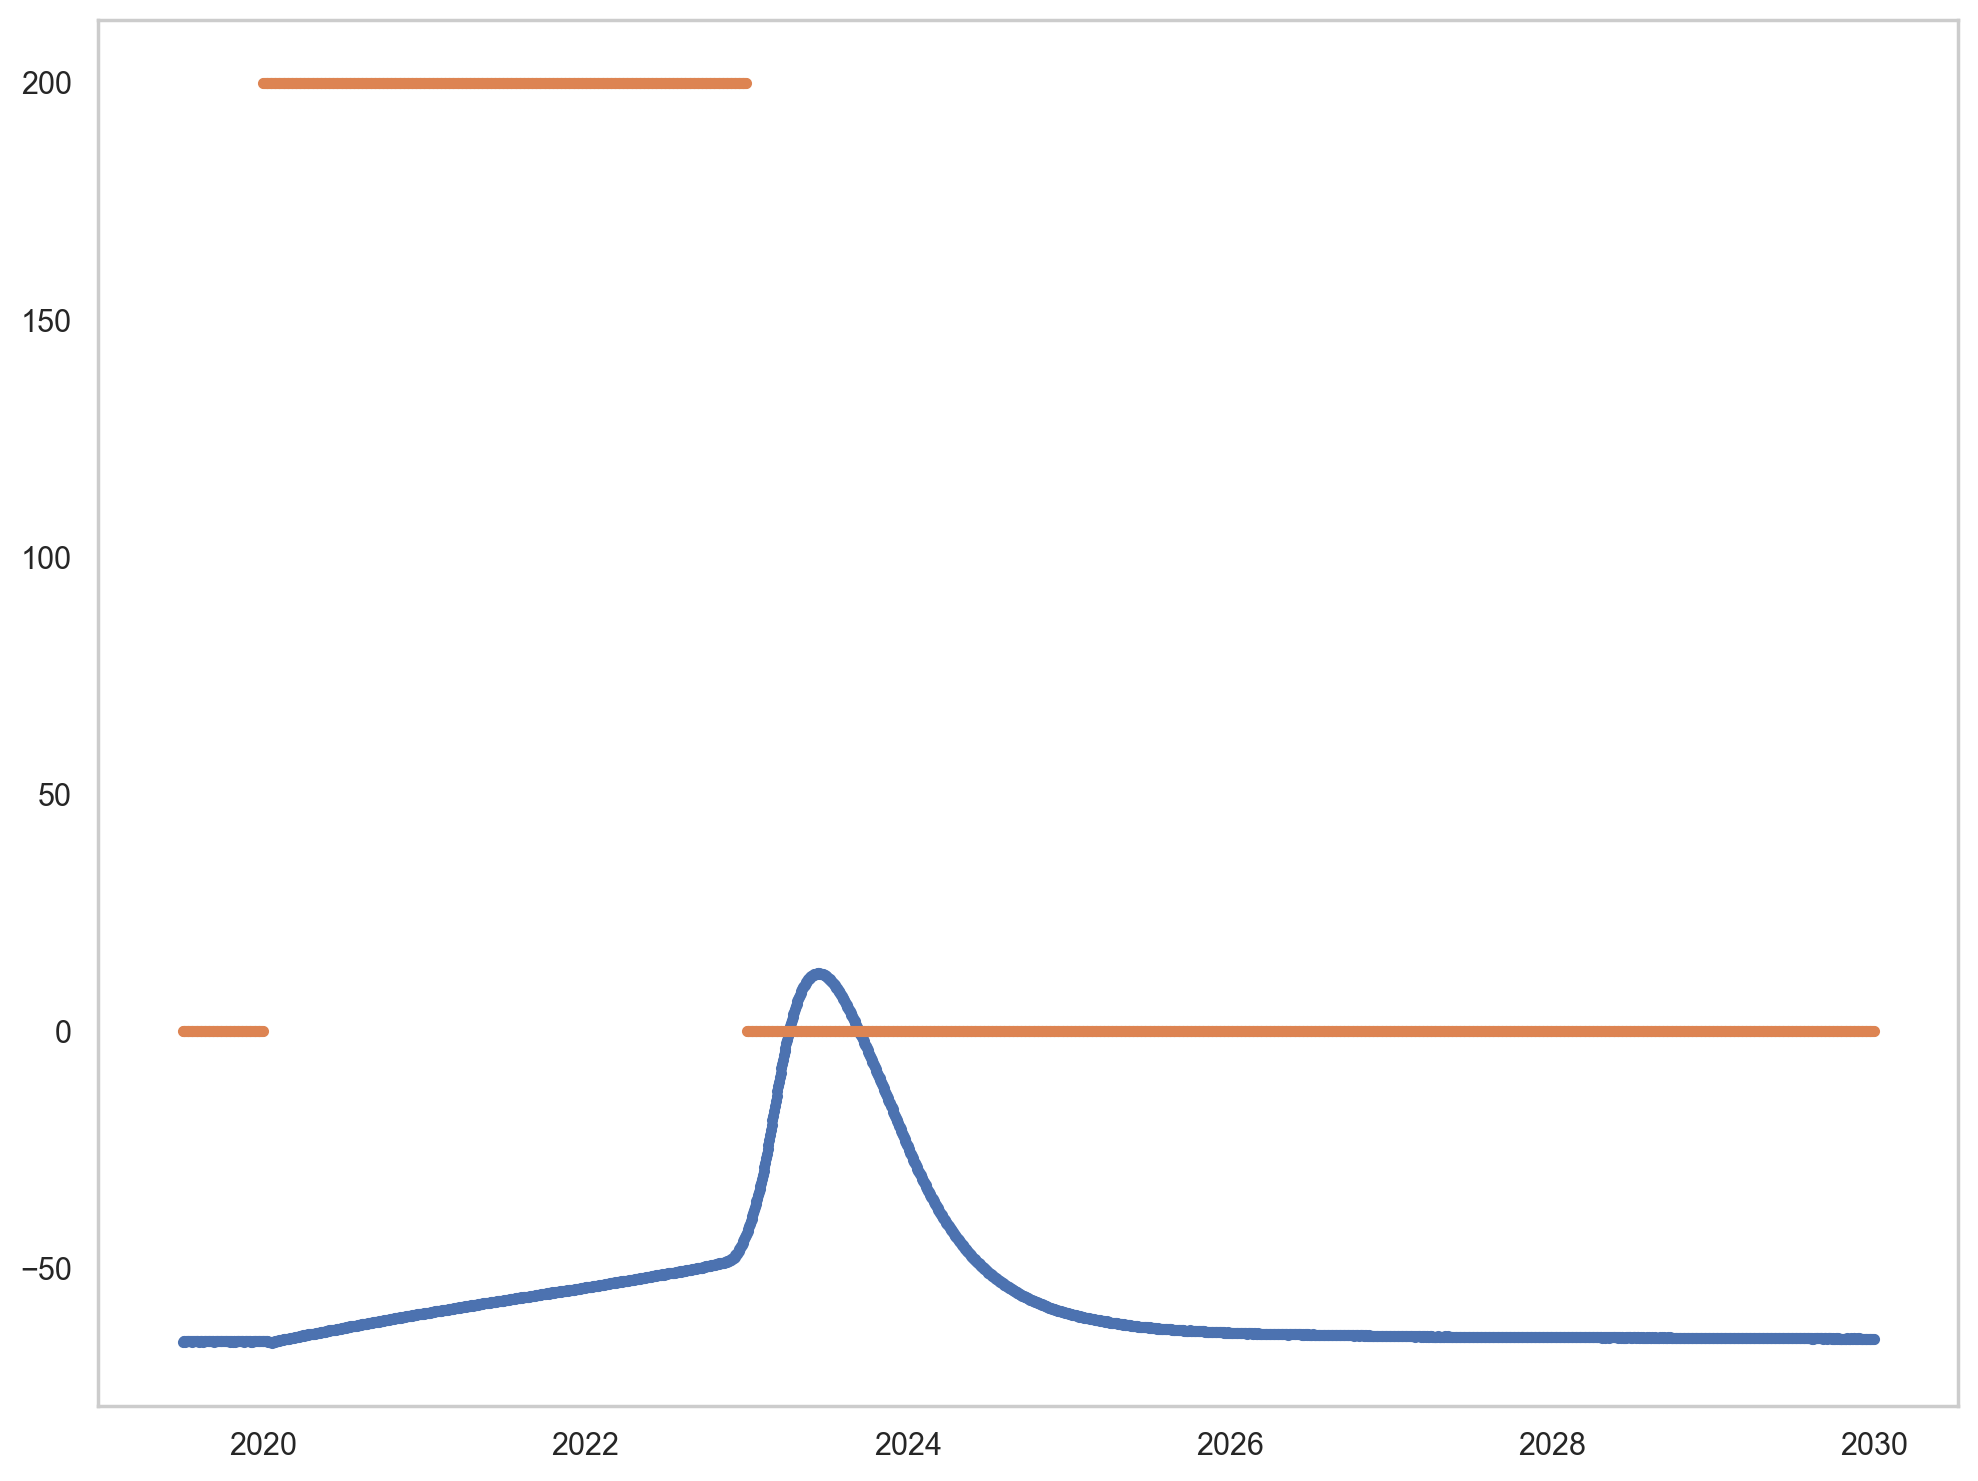

In [3]:
sweep_number = 3
index_start = 403900
index_end = 406000
dset, times = load_sweep(sweep_number, f, fs)
plot_ephys_data(dset, times, index_start, index_end)
plot_stim_data(dset, times, index_start, index_end)
plt.show()

### 2b. Pink Noise — Stimulus-Driven Variability

An example sweep under 1/f noise stimulation. The input fluctuates continuously, driving variable firing rates and — our central hypothesis — systematic changes in spike waveform shape that track the input statistics.

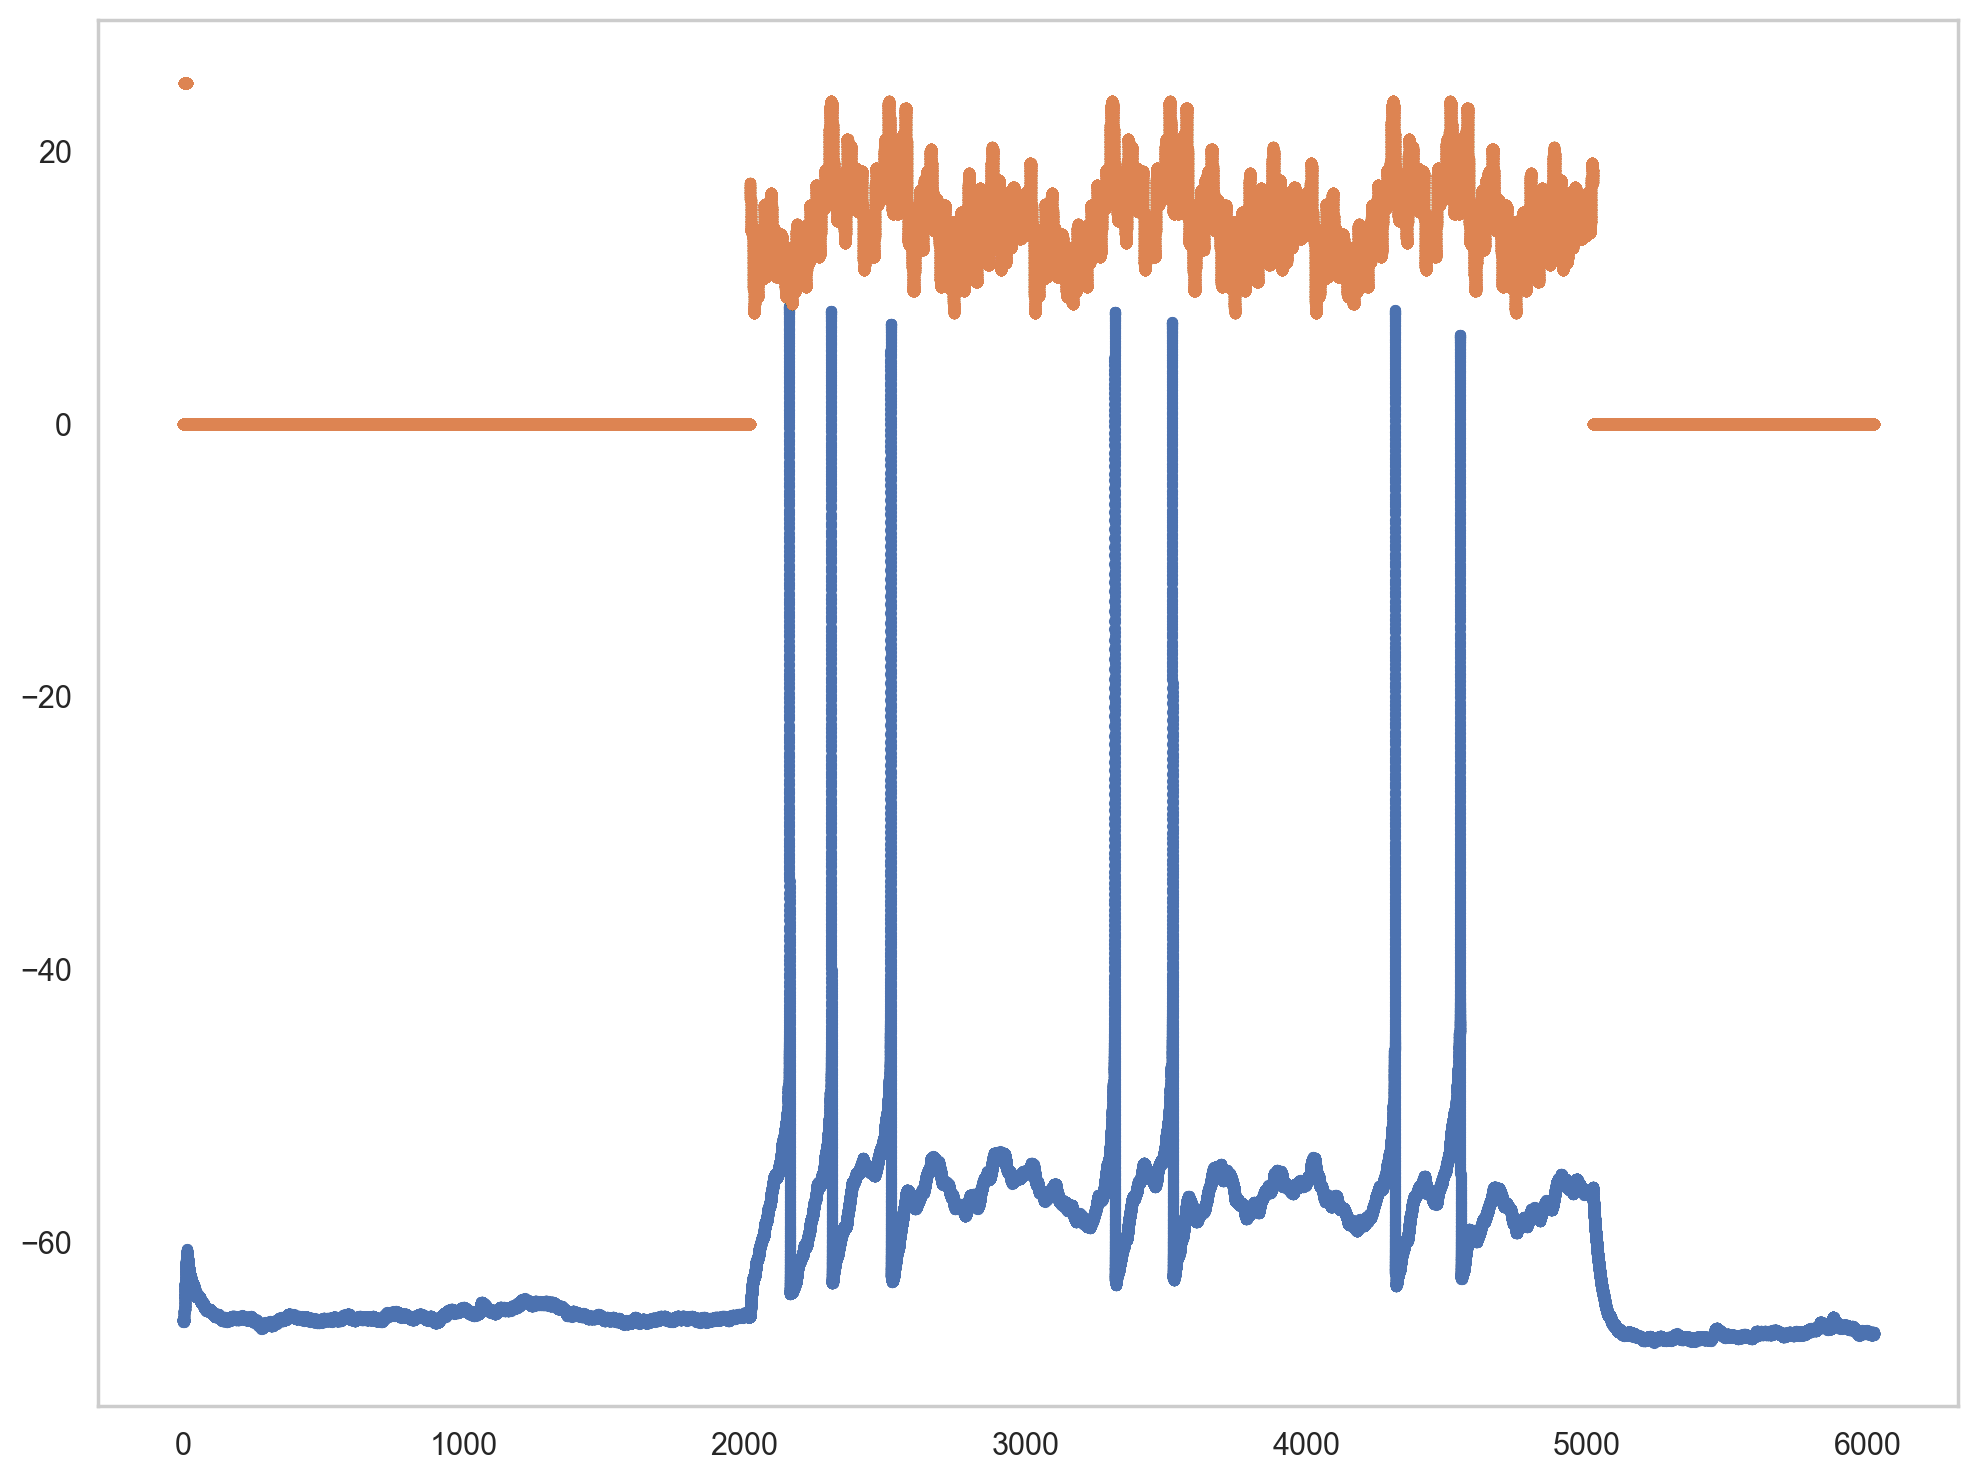

In [4]:
sweep_number = 14
index_start = 0
index_end = int(10e10)
dset, times = load_sweep(sweep_number, f, fs)
plot_ephys_data(dset, times, index_start, index_end)
plot_stim_data(dset, times, index_start, index_end)
plt.show()

## 3. Stimulus Labeling & Spike Extraction

### 3a. Cataloguing Stimulus Types and Pink Noise Variants

For each sweep we label the stimulus type (constant / ramp / pink) and, for pink sweeps, extract spectral properties of the noise waveform (exponent, mean, std). This metadata table is the backbone for all downstream sub-group analyses — especially comparing first vs. all pink spikes, and testing whether stimulus statistics predict waveform features.

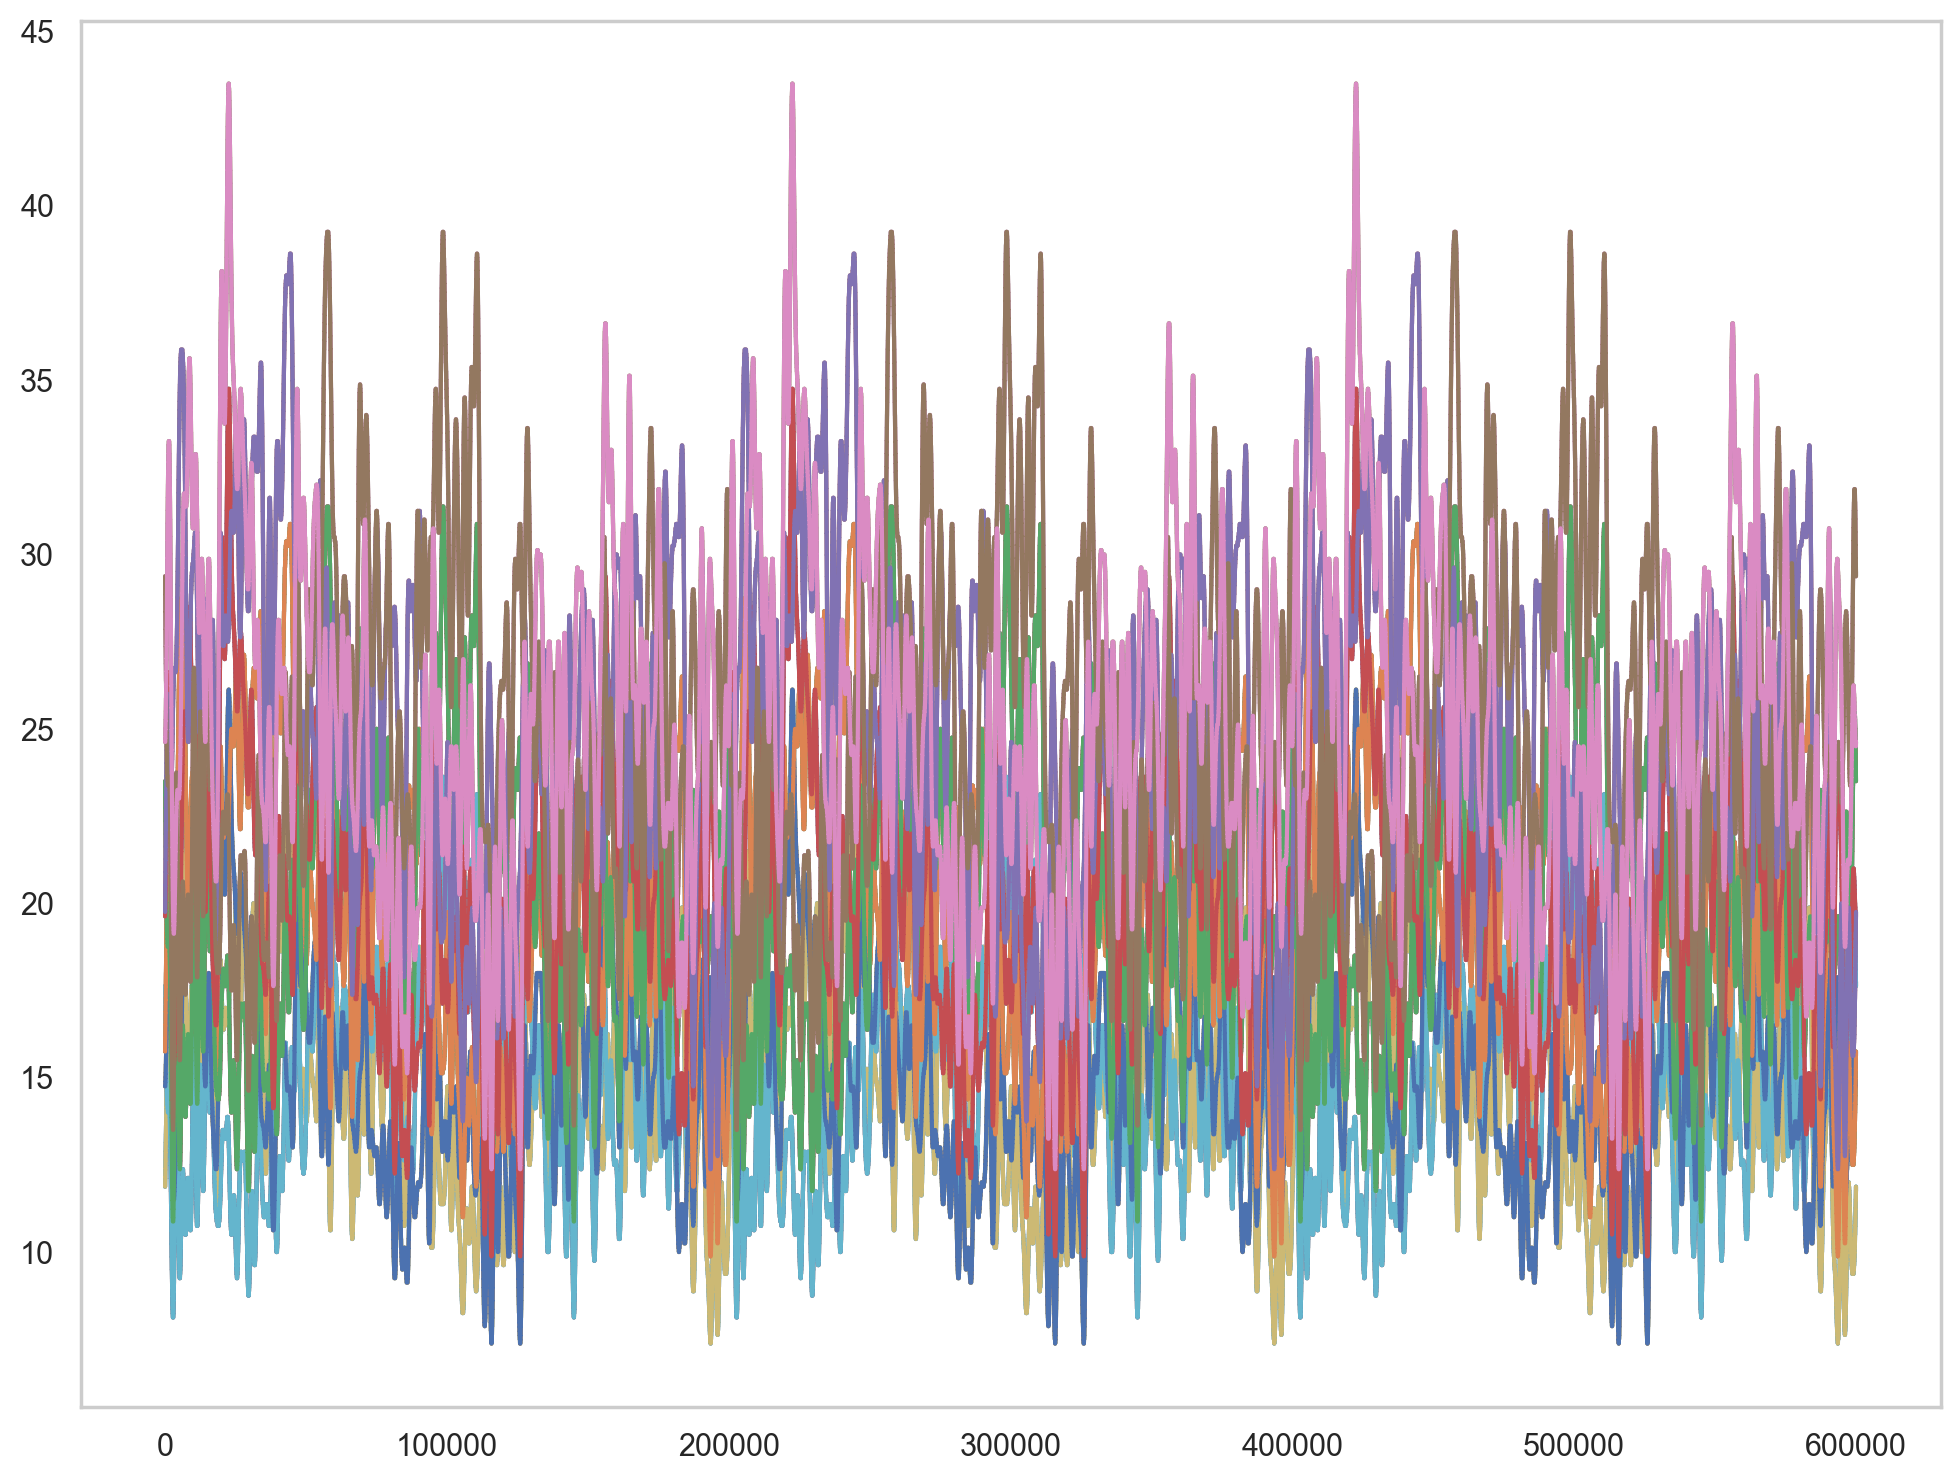

In [5]:
# Process sweeps and extract features
pink_types = process_pink_type_info(f, fs)

### 3b. Processing Sweeps & Loading Pickles

We extract every spike from every sweep, compute per-spike stimulus context (type, sweep index, ISI), and save to pickles for fast reloading. The full dataset is concatenated into `all_data` — a matrix of aligned spike waveforms — for population-level fitting in the next step.

In [6]:
# Process sweeps and extract features

"""

df_sweep, df_stim_type, df_spike_number, df_voltage_ramp, df_inflection_time, df_inflection_mv, \
df_peak_amplitude, df_peak_sharpness, df_decay_lambda, df_decay_const, df_stim_exp, df_stim_mean, \
df_stim_std, df_pinktype, all_data, all_times, all_contant_spks, all_ramp_spks, all_pink_spks = process_sweeps(66, f, one_ms, fs, pink_types, load_sweep, find_spike_times, fit_exp_nonlinear)

stim_waveforms = [all_contant_spks, all_ramp_spks, all_pink_spks]

df_stim_features = pd.DataFrame({'sweep': df_sweep, 'stim_type': df_stim_type, 'spike_num': df_spike_number,
                     'stim_exp': df_stim_exp, 'stim_mean': df_stim_mean,
                    'stim_std': df_stim_std,'pink_type':df_pinktype },
        columns=['sweep', 'stim_type', 'spike_num', 'stim_exp', 'stim_mean', 'stim_std', 'pink_type'])
all_data_flat =  [n for one_dim in all_data for n in one_dim]
"""




"\n\ndf_sweep, df_stim_type, df_spike_number, df_voltage_ramp, df_inflection_time, df_inflection_mv, df_peak_amplitude, df_peak_sharpness, df_decay_lambda, df_decay_const, df_stim_exp, df_stim_mean, df_stim_std, df_pinktype, all_data, all_times, all_contant_spks, all_ramp_spks, all_pink_spks = process_sweeps(66, f, one_ms, fs, pink_types, load_sweep, find_spike_times, fit_exp_nonlinear)\n\nstim_waveforms = [all_contant_spks, all_ramp_spks, all_pink_spks]\n\ndf_stim_features = pd.DataFrame({'sweep': df_sweep, 'stim_type': df_stim_type, 'spike_num': df_spike_number,\n                     'stim_exp': df_stim_exp, 'stim_mean': df_stim_mean,\n                    'stim_std': df_stim_std,'pink_type':df_pinktype },\n        columns=['sweep', 'stim_type', 'spike_num', 'stim_exp', 'stim_mean', 'stim_std', 'pink_type'])\nall_data_flat =  [n for one_dim in all_data for n in one_dim]\n"

In [7]:
""""
# Save processed sweeps as pickles
with open('df_stim_features.pkl', 'wb') as file:
    pickle.dump(df_stim_features, file)

with open('all_data.pkl', 'wb') as file:
    pickle.dump(all_data, file)
    
with open('stim_waveforms.pkl', 'wb') as file:
    pickle.dump(stim_waveforms, file)    
    """
    


'"\n# Save processed sweeps as pickles\nwith open(\'df_stim_features.pkl\', \'wb\') as file:\n    pickle.dump(df_stim_features, file)\n\nwith open(\'all_data.pkl\', \'wb\') as file:\n    pickle.dump(all_data, file)\n\nwith open(\'stim_waveforms.pkl\', \'wb\') as file:\n    pickle.dump(stim_waveforms, file)    \n    '

In [8]:
# Load saved pickles 
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/df_stim_features.pkl', 'rb') as file:
    df_stim_features = pickle.load(file)

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/all_data.pkl', 'rb') as file:
    all_data = pickle.load(file)


with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/stim_waveforms.pkl', 'rb') as file:
    stim_waveforms = pickle.load(file)

In [9]:
all_contant_spks, all_ramp_spks, all_pink_spks = stim_waveforms[0], stim_waveforms[1], stim_waveforms[2]

In [10]:
#try collapsing the all data array to 1d (concatenate all sweeps)
all_data_flat =  [n for one_dim in all_data for n in one_dim]

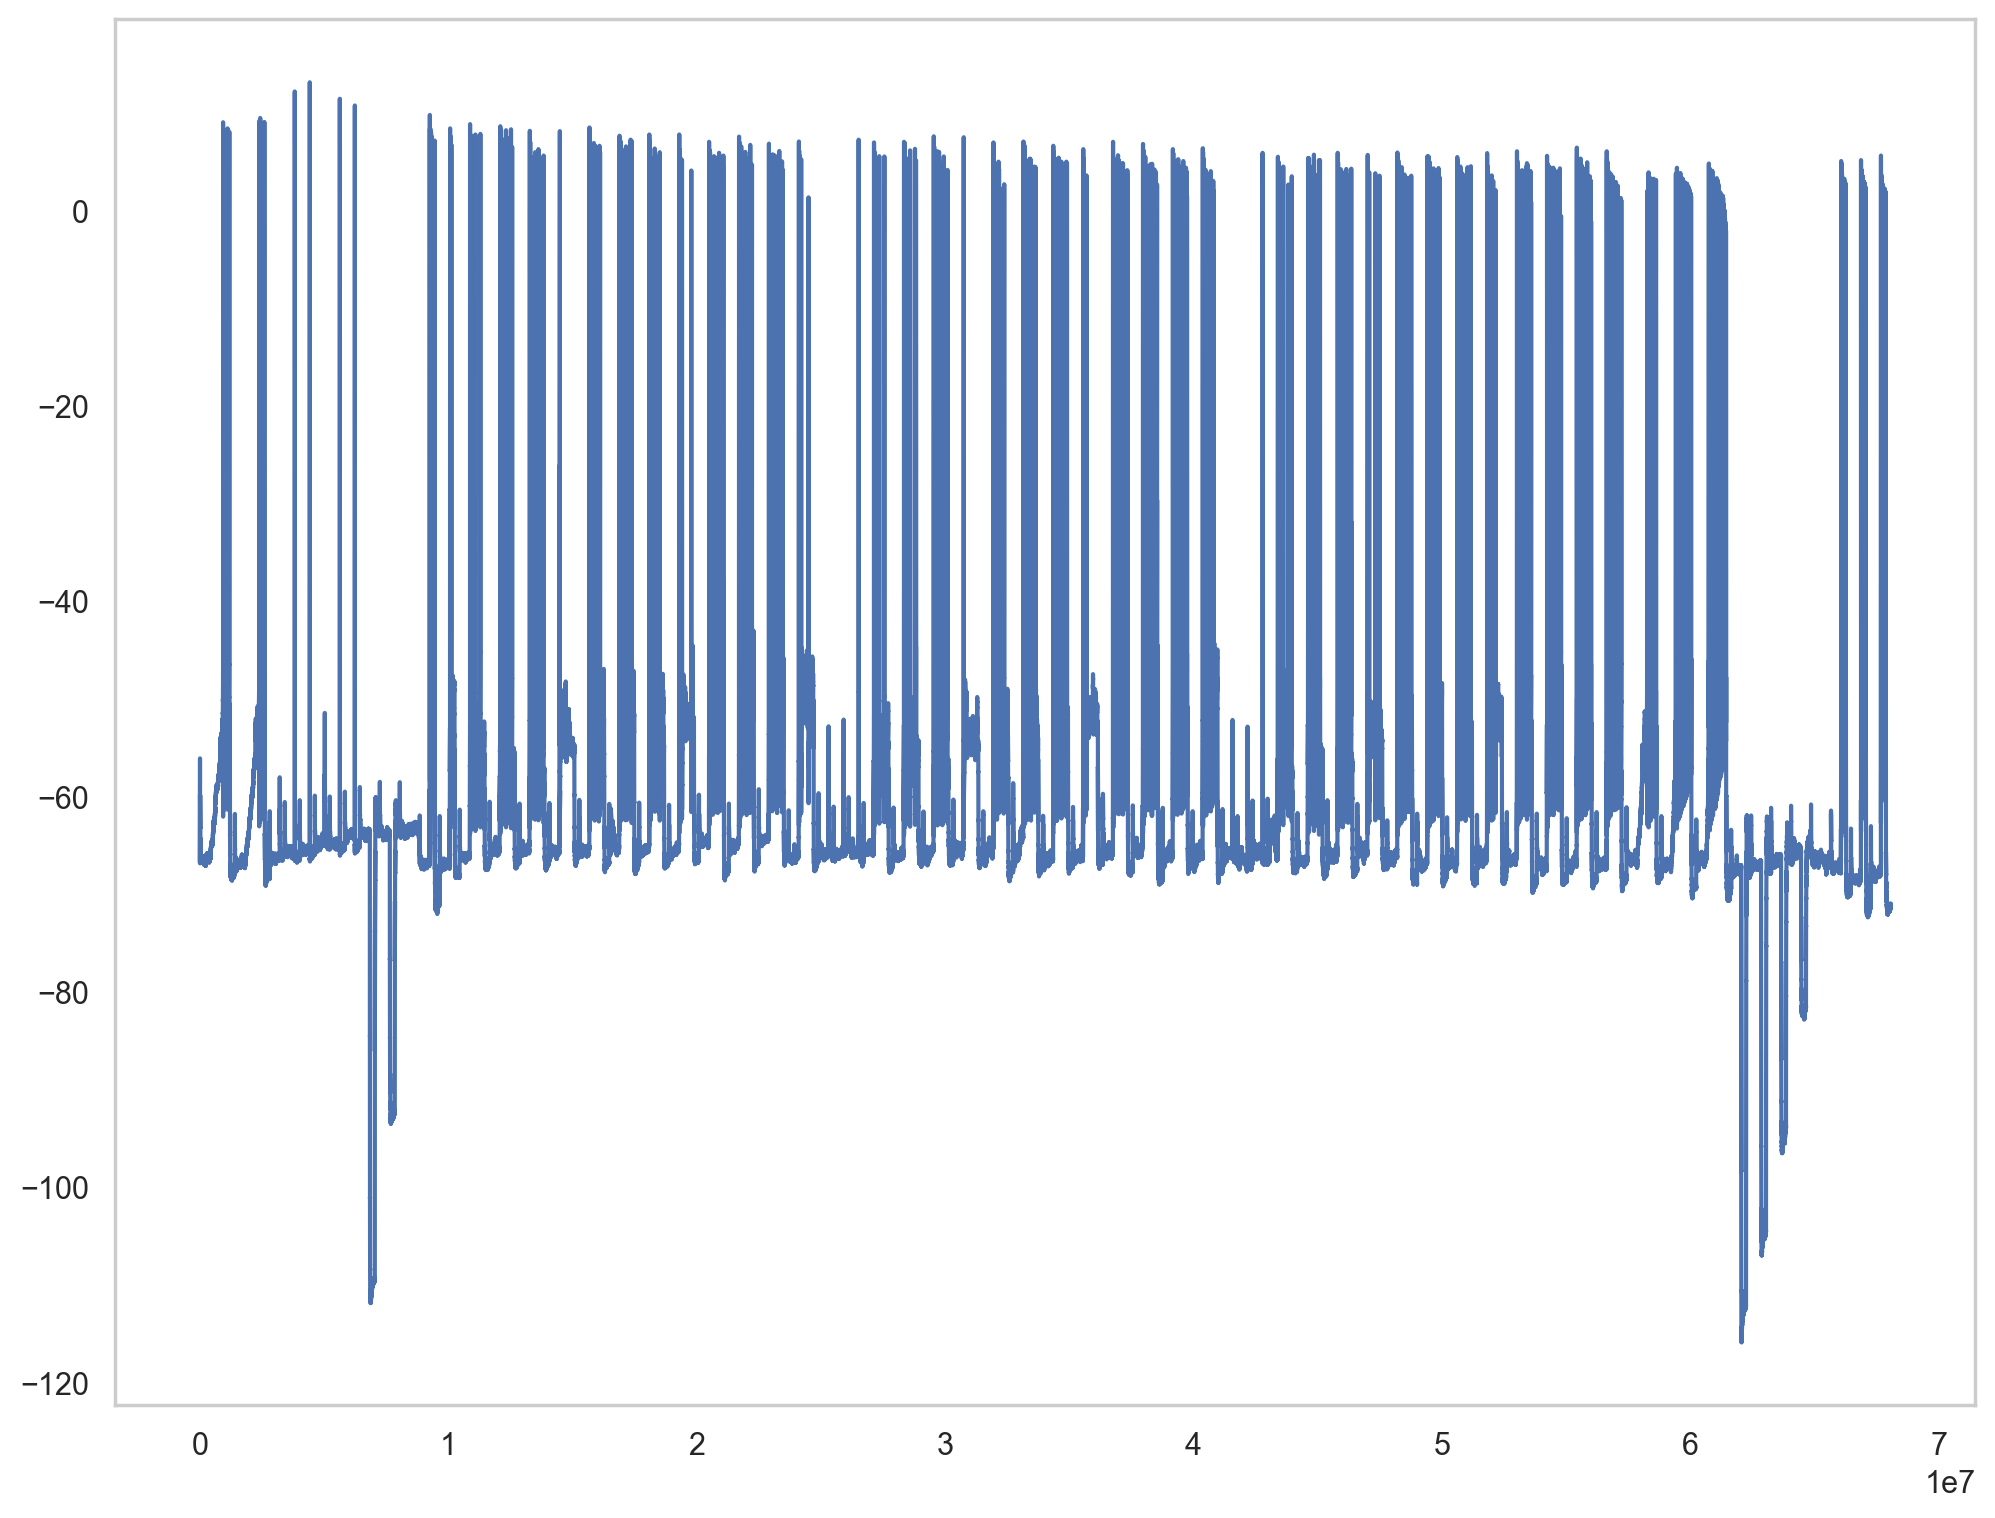

In [11]:
plt.plot(all_data_flat)

## 4. Spike Waveform Parameterization

### 4a. Single Spike Visualization & First Derivative

A sanity check before batch fitting: we plot one spike and its derivative to confirm that parameterization landmarks (threshold, peak, trough, inflection) are being detected correctly. The derivative is essential for identifying inflection points that aren't obvious from the voltage trace alone.

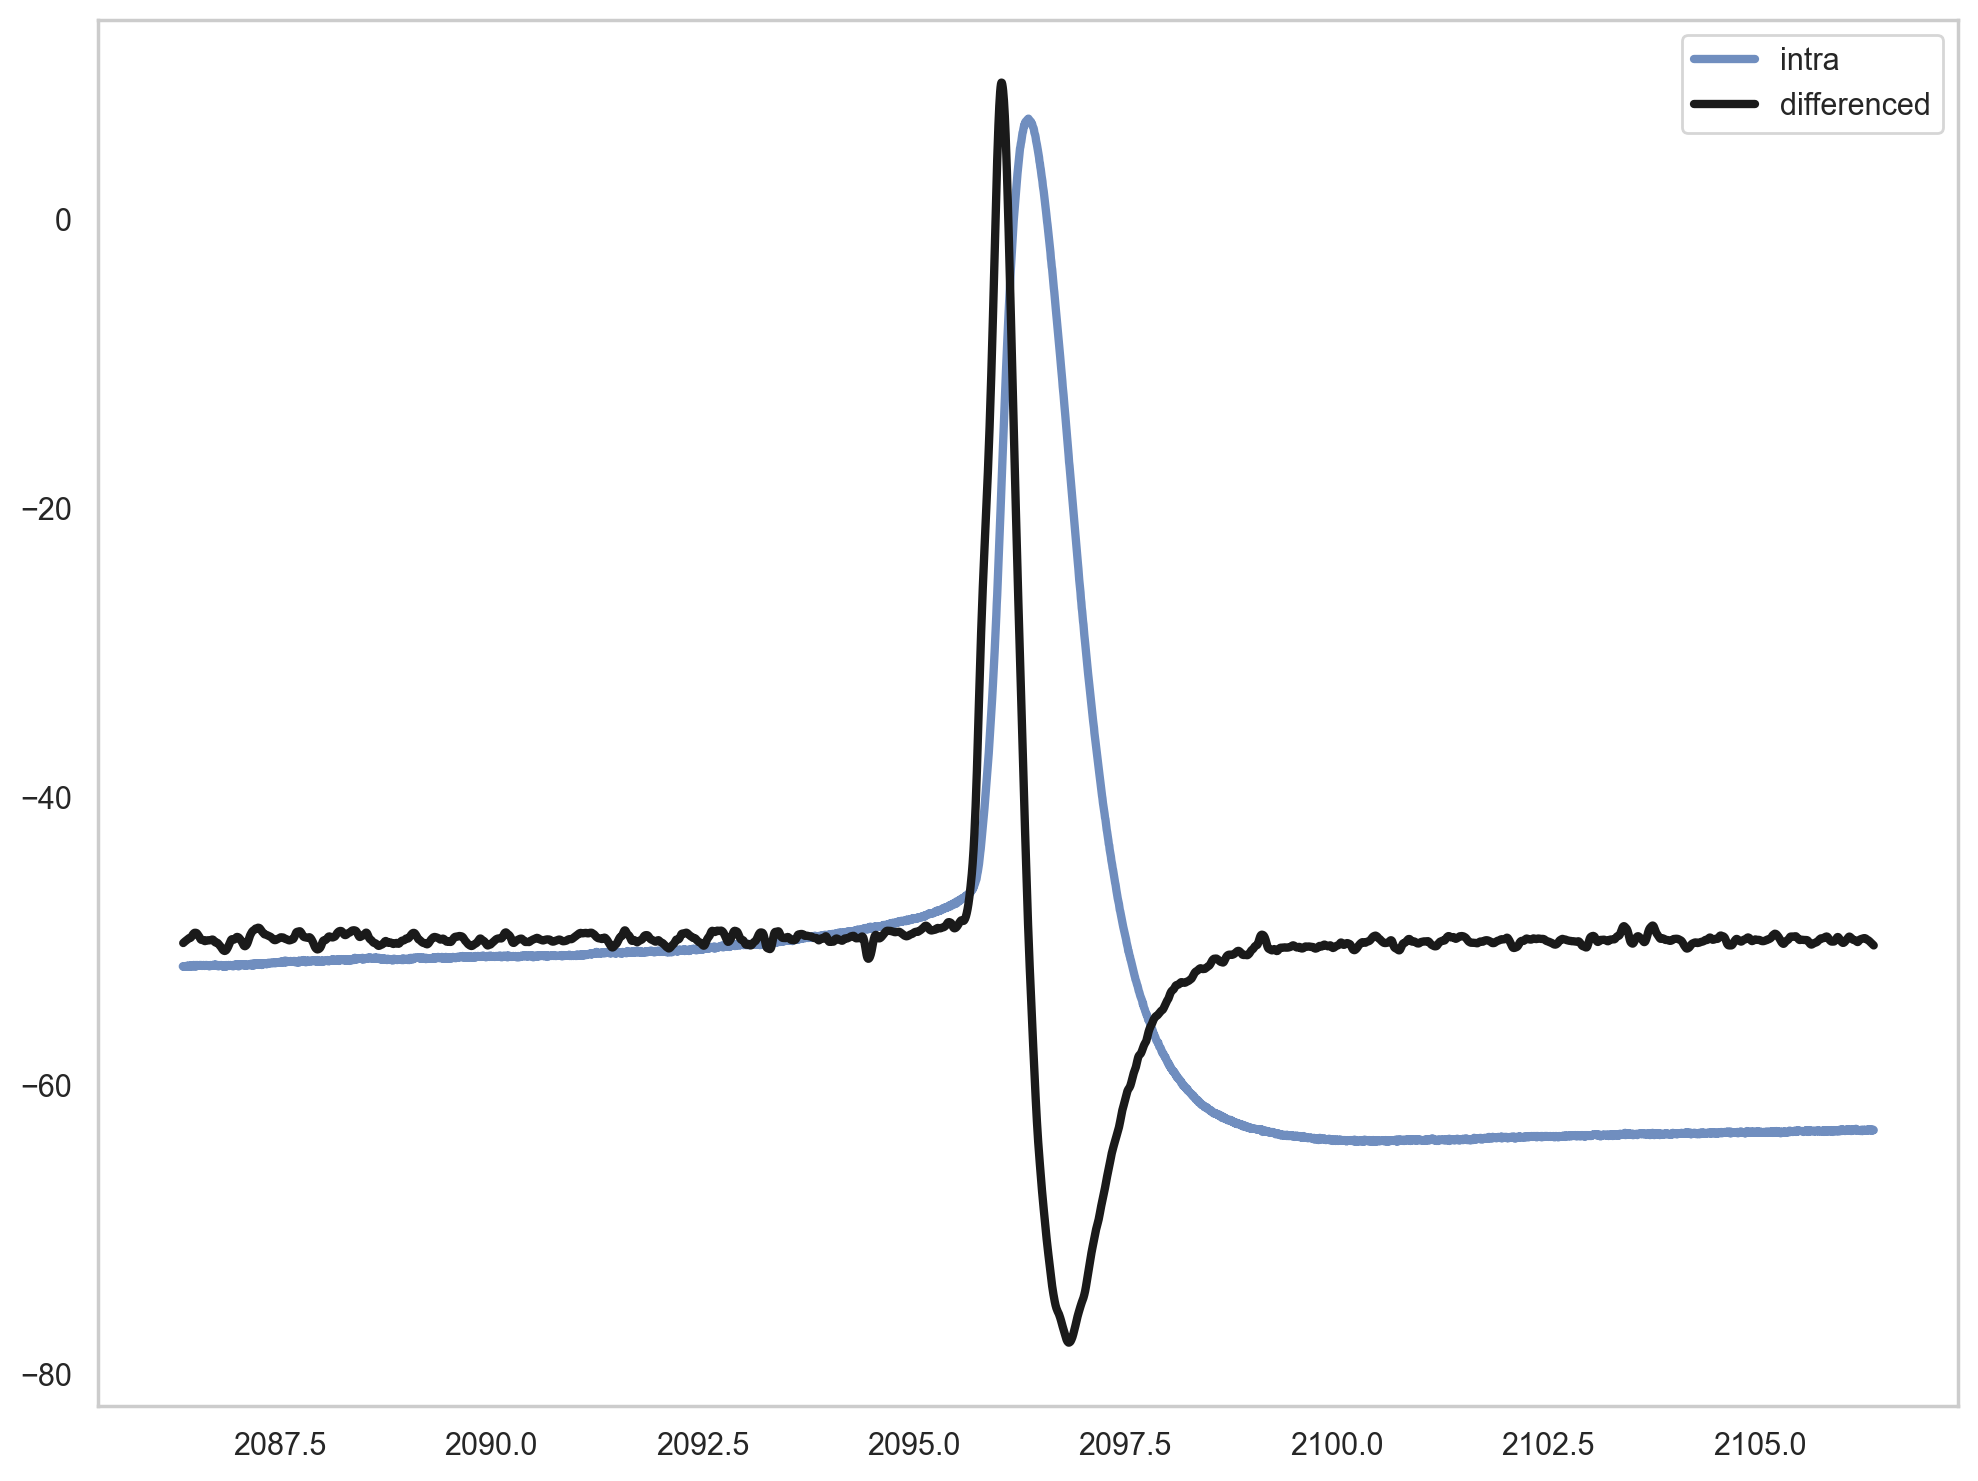

In [12]:
plot_spike_and_derivative(28, f, fs, one_ms)

### 4b. Fitting Spike Waveforms

We instantiate a `Spike` object on the full spike matrix and extract: peak amplitude, peak sharpness, peak width, exp_lambda (repolarization rate), exp_const, inflection time, and log ISI — the same feature set used across all datasets, giving us a shared vocabulary for comparing stimulus-driven variability here to spontaneous variability in spe-1.

In [13]:
sp = Spike(thresh_amp= -10, window_length=(5., 5.), smooth_frac=.008, pre_inflection_ms = 0.5)
sp.fit(all_data_flat, fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/820 [00:00<?, ?it/s]

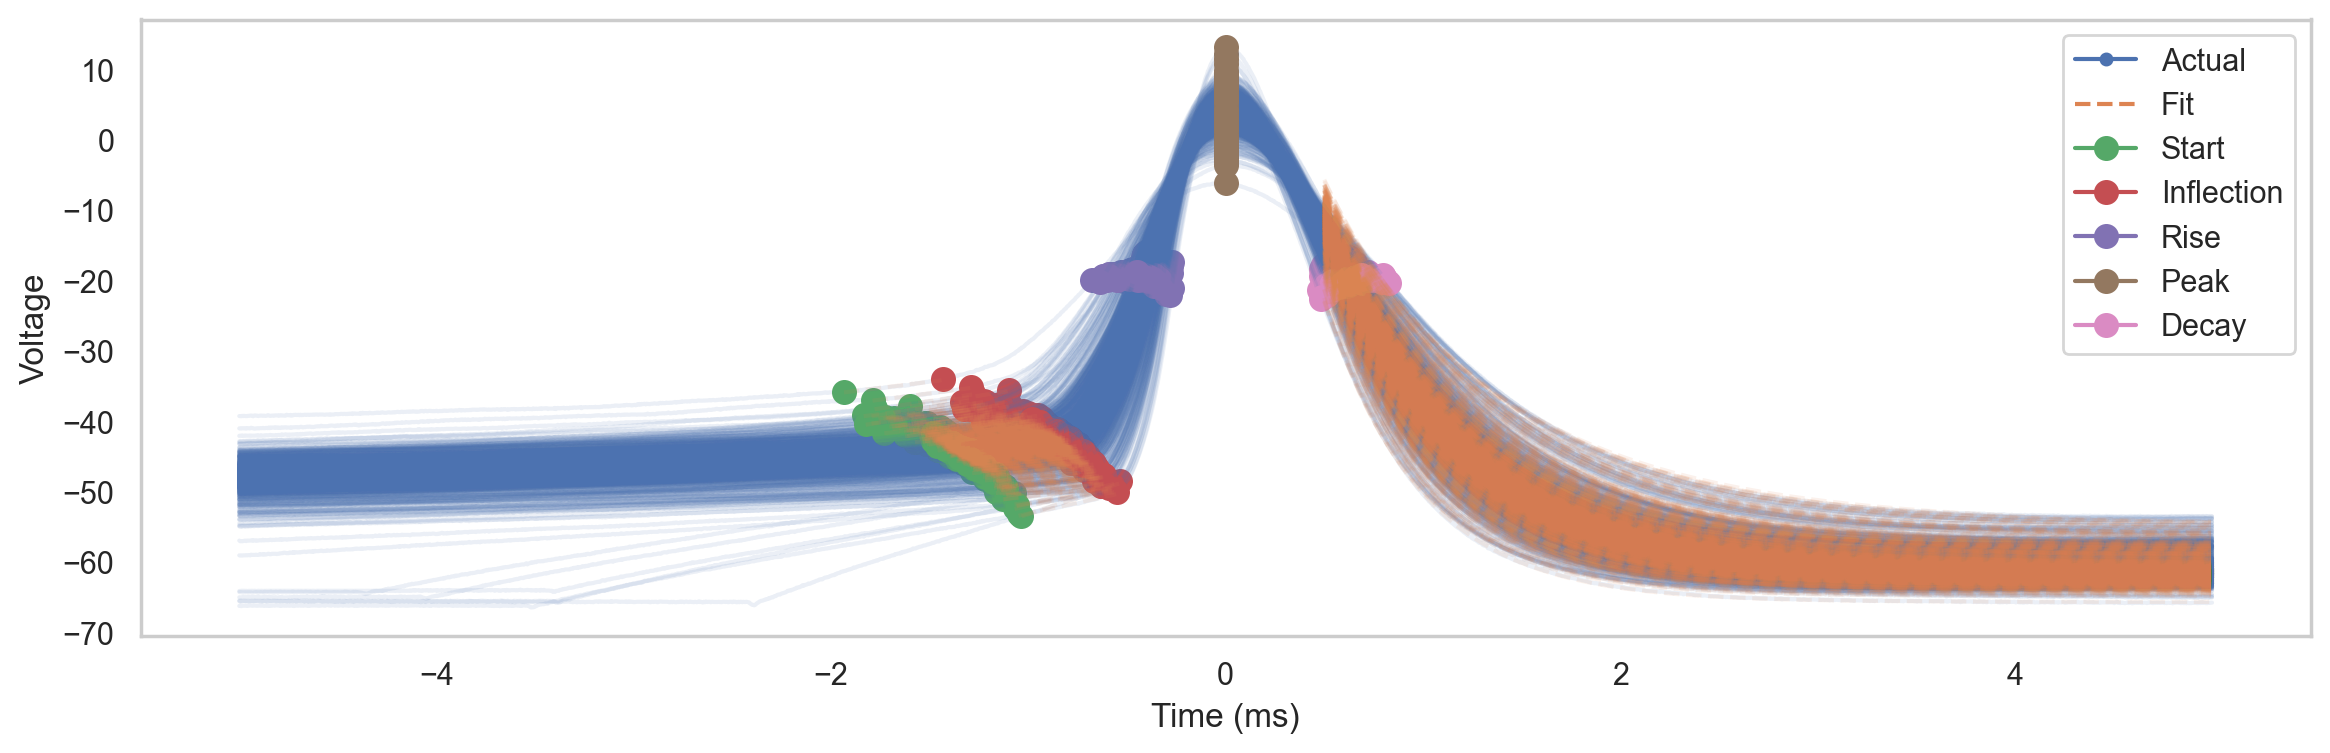

In [14]:
sp.plot(show_points=True)

In [15]:
sp.filter_features()

In [16]:
df_features = sp.df_features

### 4c. Merging Spike Features with Stimulus Metadata

We concatenate the `Spike` feature DataFrame with the per-spike stimulus table, yielding one row per spike with both waveform parameters and stimulus context. From here we can ask: do waveform features differ across stim types, or co-vary continuously with instantaneous stimulus statistics?

In [17]:
df = pd.concat([df_stim_features, df_features], axis=1)
df = df.dropna(subset=['stim_type'])

## 5. Exploratory Analysis

### 5a. Average Waveform by Stimulus Type

Do spike shapes look systematically different across constant, ramp, and pink stimulation? This plot is the first visual check — if the mean waveforms differ across conditions, it's prima facie evidence that input drive shapes spike morphology.

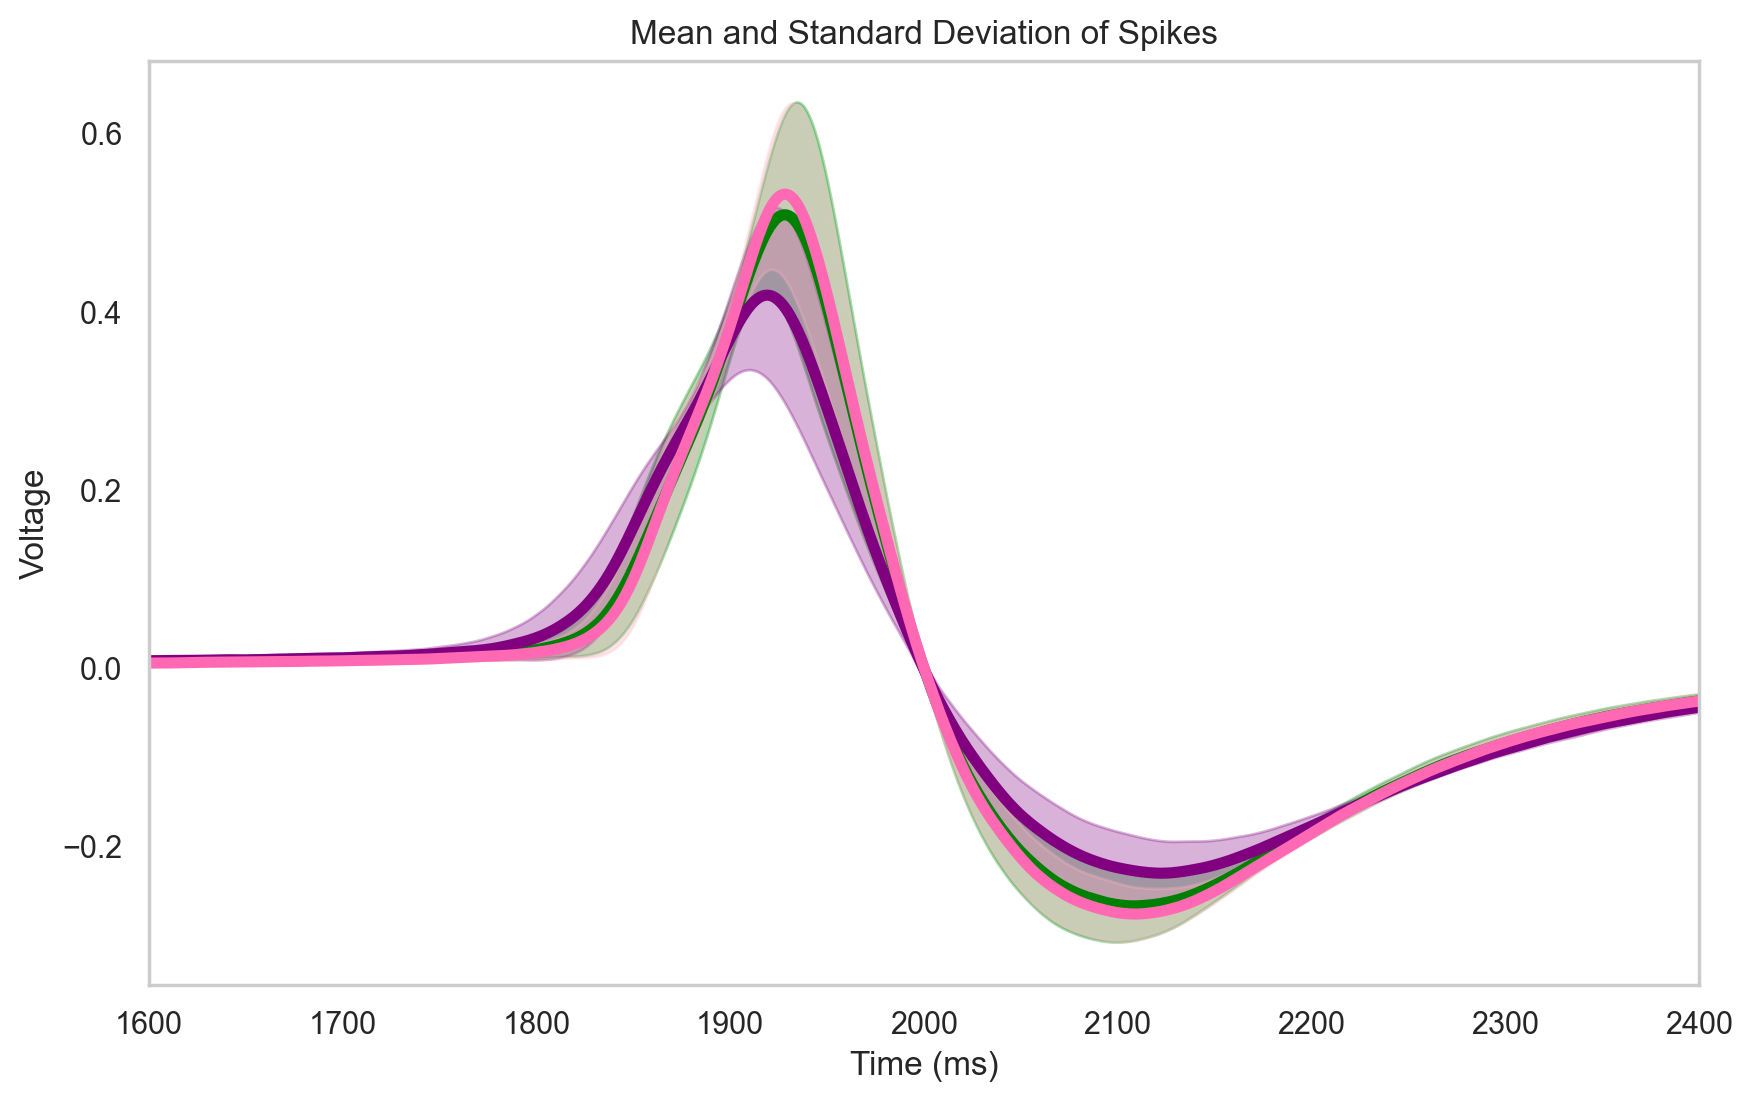

In [18]:
plot_avg_waveform_by_stim_type(all_contant_spks, all_ramp_spks,all_pink_spks)

### 5b. Pink Noise Spikes — Waveform Gallery

We plot the raw spike waveforms from pink noise sweeps only. Visualizing the spread of individual waveforms (rather than just the mean) shows us the within-condition variability that our models need to explain.

In [19]:
pink_spikes = df[df['stim_type'] == 'pink']

# Get the indices to plot
indices_to_plot = pink_spikes.index.tolist()

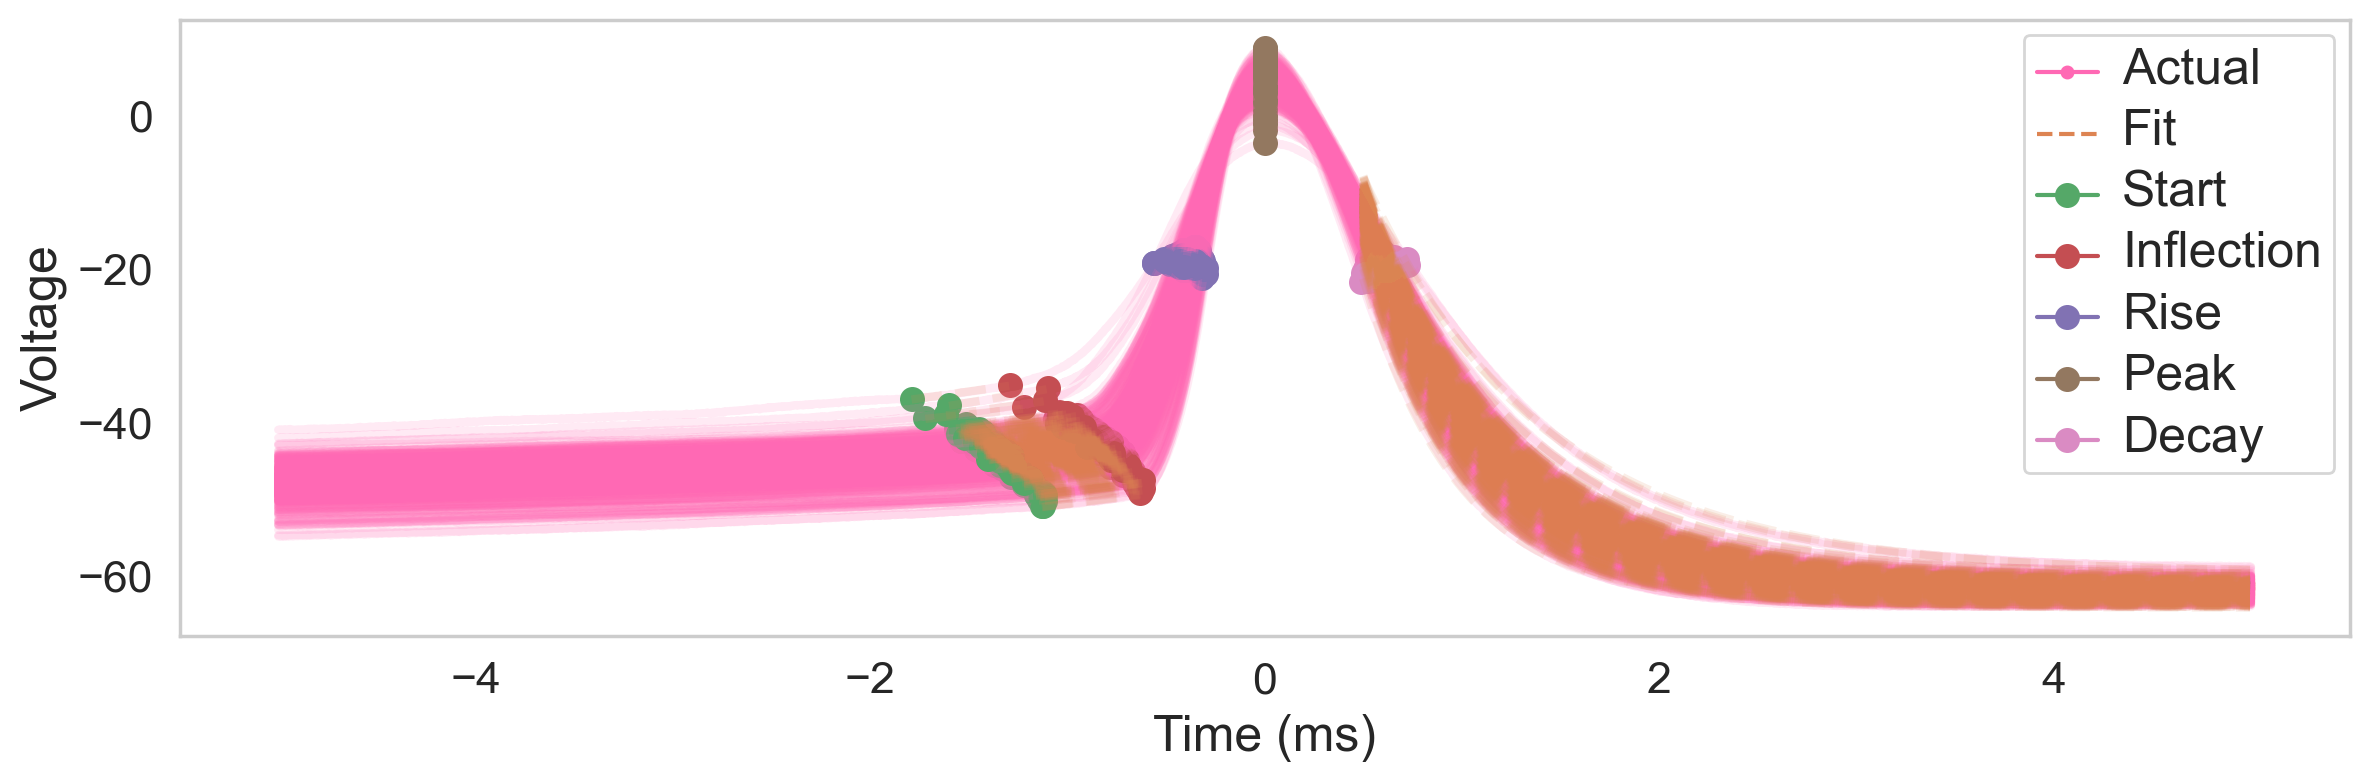

In [20]:
plot_pink_spikes(sp, indices_to_plot)

### 5c. Excluding Last-Spike-of-Sweep Artifacts

The last spike of each sweep is removed before regression analyses — these spikes often have inflated ISIs (no successor spike) that would skew the log ISI distribution and confound the predictors.

In [21]:
last_spikes_indices = df.groupby('sweep').tail(1).index
print("Indices of last spikes in each sweep:", last_spikes_indices)

Indices of last spikes in each sweep: Index([  3,   9,  10,  11,  12,  13,  42,  45,  49,  56,  63,  64,  74,  87,
        98, 104, 132, 158, 185, 193, 194, 198, 204, 211, 212, 221, 236, 249,
       255, 279, 305, 331, 357, 358, 364, 371, 379, 385, 401, 416, 431, 441,
       470, 499, 529, 563, 577, 631, 722, 735, 769, 819],
      dtype='int64')


### 5d. Feature Correlation Structure

We compute pairwise Spearman correlations across all spike + stimulus features for three sub-populations: (1) all spikes, (2) all pink spikes, (3) first spike per pink sweep only. Narrowing to pink then first-pink progressively removes adaptation and sweep-level confounds, letting us isolate correlations driven by instantaneous stimulus statistics rather than history effects.

#### i. All Spikes (constant + ramp + pink combined)

In [ ]:
df_all = df.drop(['sweep', 'stim_type', 'pink_type', 'spike_num'], axis=1)
pd.plotting.scatter_matrix(df_all, alpha=0.5)
plt.show()
spikes_corr = df_all.corr()
sns.heatmap(spikes_corr, xticklabels=spikes_corr.columns, yticklabels=spikes_corr.columns, annot=True)
plt.show()
rho = df_all.corr()
pval = df_all.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.applymap(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

#### ii. Pink Noise Spikes Only

In [ ]:
df_pink = df.loc[df['stim_type'] == 'pink']
df_pink = df_pink.drop(['sweep', 'stim_type', 'pink_type', 'spike_num'], axis=1)
pd.plotting.scatter_matrix(df_pink, alpha=0.5)
plt.show()
spikes_corr = df_pink.corr()
sns.heatmap(spikes_corr, xticklabels=spikes_corr.columns, yticklabels=spikes_corr.columns, annot=True)
plt.show()
rho = df_pink.corr()
pval = df_pink.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.applymap(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

#### iii. First Spike per Pink Sweep — Minimizing Adaptation

In [ ]:
df_pink_first = df.loc[df['stim_type'] == 'pink']
df_pink_first = df_pink_first.loc[df['spike_num'] == 0]
df_pink_first = df_pink_first.drop(['sweep', 'stim_type', 'spike_num', 'pink_type',], axis=1)
pd.plotting.scatter_matrix(df_pink_first, alpha=0.5)
plt.show()
spikes_corr = df_pink_first.corr()
sns.heatmap(spikes_corr, xticklabels=spikes_corr.columns, yticklabels=spikes_corr.columns, annot=True)
plt.show()
rho = df_pink_first.corr()
pval = df_pink_first.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.applymap(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

### 5e. Correlation Scatter Plots — Pink Spikes (Excluding Last-Sweep Spikes)

In [25]:
# Find which indices are actually present in df_pink, remove last spike of sweeps
valid_indices = [idx for idx in last_spikes_indices if idx in df_pink.index]

# Drop the last spikes
df_pink_filtered = df_pink.drop(valid_indices)

In [26]:
#get dfs for regression models 

df_pink_no_stim_filtered = df_pink_filtered.drop(['stim_exp', 'stim_mean', 'stim_std' ], axis=1)
df_pink_no_stim_first = df_pink_first.drop(['stim_exp', 'stim_mean', 'stim_std' ], axis=1)
df_pink_onlystim_filtered = df_pink_filtered.drop(['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width','peak_sharpness', 'exp_lambda', 'exp_const' ], axis=1)
df_pink_onlystim_first = df_pink_first.drop(['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width','peak_sharpness', 'exp_lambda', 'exp_const' ], axis=1)


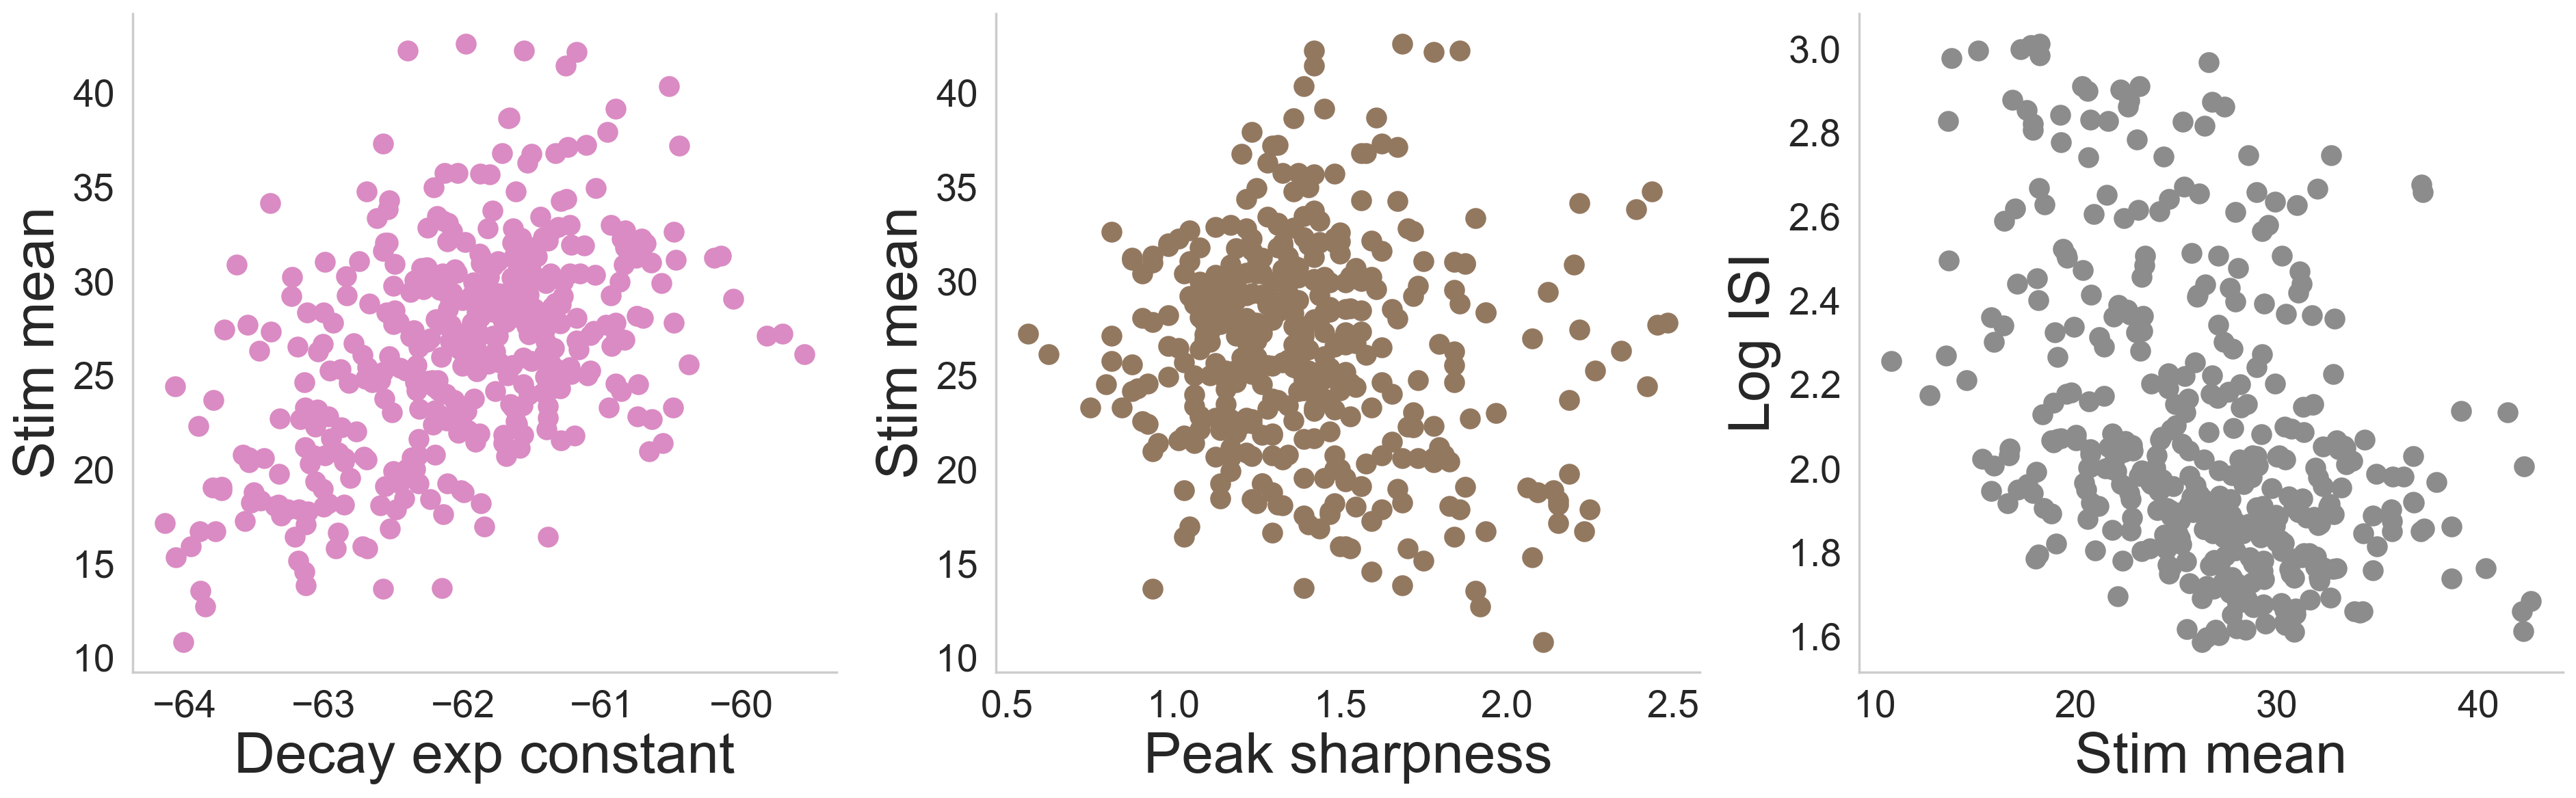

In [27]:
plot_correlation_scatter(df_pink_filtered)

## 6. Classification: Decoding Stimulus Type

As a direct test of stimulus-driven variability, we train three classifiers — logistic regression, SVM, and random forest — to predict stimulus type (constant / ramp / pink) from spike waveform features alone. If waveform features carry no information about input drive, accuracy should be at chance. Above-chance accuracy, especially for a linear classifier, means the waveform feature space is systematically organized by the input condition.

### 6a. Firing Rate Sanity Check

In [28]:
# Calculate the number of spikes in each sweep
spike_counts = df.groupby('sweep')['spike_num'].count()

# Calculate the duration of each sweep in seconds using the indices from spike_counts
sweep_durations = {sweep: len(all_data[int(sweep)]) / fs for sweep in spike_counts.index}

# Calculate the firing rate for each sweep
firing_rates = {sweep: spike_counts[sweep] / sweep_durations[sweep] for sweep in spike_counts.index}

# Convert the dictionary to a DataFrame for easier handling and visualization
firing_rate_df = pd.DataFrame(list(firing_rates.items()), columns=['Sweep', 'Firing Rate'])

# Extract 'stim_type' values for each unique 'sweep'
stim_type_series = df.groupby('sweep')['stim_type'].first()
# Add the 'stim_type' to the firing_rate_df
firing_rate_df['Stim Type'] = firing_rate_df['Sweep'].map(stim_type_series)

# Display the updated DataFrame
print(firing_rate_df)

    Sweep  Firing Rate Stim Type
0       0     0.569800      ramp
1       1     0.854700      ramp
2       3     0.330797  constant
3       4     0.330797  constant
4       6     0.330797  constant
5       7     0.330797  constant
6      11     7.213921  constant
7      12     0.746268  constant
8      13     0.664451      pink
9      14     1.162790      pink
10     15     1.162790      pink
11     16     0.166113  constant
12     17     1.661128      pink
13     18     2.159467      pink
14     19     1.827241      pink
15     20     0.996677  constant
16     21     4.651159      pink
17     22     4.318933      pink
18     23     4.485046      pink
19     24     1.328903  constant
20     27     0.330797  constant
21     28     0.664451      pink
22     29     0.996677      pink
23     30     1.162790      pink
24     31     0.166113  constant
25     32     1.495015      pink
26     33     2.491692      pink
27     34     2.159467      pink
28     35     0.996677  constant
29     36 

In [29]:
df = df.dropna(subset=['stim_type'])

X = df.drop(columns=['stim_type', 'spike_num', 'sweep', 'stim_exp','stim_mean','stim_std', 'pink_type', 'log_isi'], inplace=False)
y = df['stim_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
df

,sweep,stim_type,spike_num,stim_exp,stim_mean,stim_std,pink_type,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi
0,0,ramp,0,NaN,NaN,NaN,ramp,2.102273,0.785,-43.468751,9.03125,0.945,1.765625,1.593883,-61.770969,2.952177
1,0,ramp,1,NaN,NaN,NaN,ramp,2.277978,0.880,-41.250001,8.40625,0.985,1.437500,1.520357,-61.217593,2.325238
2,0,ramp,2,NaN,NaN,NaN,ramp,2.188794,0.935,-40.968751,7.71875,1.005,1.234375,1.501276,-60.882459,2.166401
3,0,ramp,3,NaN,NaN,NaN,ramp,2.565857,0.930,-41.250001,8.06250,1.010,1.296875,1.536490,-60.380460,3.779297
4,1,ramp,0,NaN,NaN,NaN,ramp,2.319044,0.835,-42.437501,9.15625,0.950,1.578125,1.630889,-63.035684,2.315949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
815,65,constant,45,NaN,NaN,NaN,constant,3.534053,0.980,-40.843751,1.00000,1.165,0.843750,1.297449,-58.401222,1.320250
816,65,constant,46,NaN,NaN,NaN,constant,3.775465,0.970,-40.906251,1.93750,1.120,0.890625,1.421559,-57.824847,1.324488
817,65,constant,47,NaN,NaN,NaN,constant,3.736724,0.980,-40.531251,1.28125,1.140,0.843750,1.405411,-57.515739,1.351989
818,65,constant,48,NaN,NaN,NaN,constant,4.195282,0.980,-39.718751,0.62500,1.140,0.843750,1.325566,-58.077151,1.343113


### 6b. Logistic Regression — Linear Stimulus-Type Decoder

In [31]:
#logr_model, logr_accs = logistic_regression_stim(X, y, X_train, X_test, y_train, y_test)

In [32]:
"""
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/logr_model.pkl', 'wb') as file:
    pickle.dump(logr_model, file)

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/logr_accs.pkl', 'wb') as file:
    pickle.dump(logr_accs, file)

"""

"\nwith open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/logr_model.pkl', 'wb') as file:\n    pickle.dump(logr_model, file)\n\nwith open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/logr_accs.pkl', 'wb') as file:\n    pickle.dump(logr_accs, file)\n\n"

In [33]:
# Load saved pickles 
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/logr_model.pkl', 'rb') as file:
    logr_model = pickle.load(file)

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/logr_accs.pkl', 'rb') as file:
    logr_accs = pickle.load(file)

In [34]:
logr_acc = logr_model.score(X_test, y_test)


### 6c. SVM — Nonlinear Stimulus-Type Decoder

In [35]:
#svm_model, svm_accs = svm_stim(X, y, X_train, X_test, y_train, y_test)

In [36]:
"""
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/svm_model.pkl', 'wb') as file:
    pickle.dump(svm_model, file)

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/svm_accs.pkl', 'wb') as file:
    pickle.dump(svm_accs, file)

"""

"\nwith open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/svm_model.pkl', 'wb') as file:\n    pickle.dump(svm_model, file)\n\nwith open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/svm_accs.pkl', 'wb') as file:\n    pickle.dump(svm_accs, file)\n\n"

In [37]:
# Load saved pickles 
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/svm_model.pkl', 'rb') as file:
    svm_model = pickle.load(file)

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/svm_accs.pkl', 'rb') as file:
    svm_accs = pickle.load(file)

In [38]:
svm_acc = logr_model.score(X_test, y_test)

### 6d. Random Forest — Ensemble Decoder + Feature Importance

In [ ]:
_mask = pd.notna(y_train) & pd.notna(y_test)
y_train_clean = y_train[pd.notna(y_train)]
X_train_clean = X_train.loc[y_train_clean.index]
y_test_clean  = y_test[pd.notna(y_test)]
X_test_clean  = X_test.loc[y_test_clean.index]

pickle_path_model = os.path.join(PICKLE_DIR, 'rf_model.pkl')
pickle_path_accs  = os.path.join(PICKLE_DIR, 'rf_accs.pkl')

if not FORCE_RERUN and os.path.exists(pickle_path_model):
    with open(pickle_path_model, 'rb') as file:
        rf_model = pickle.load(file)
    with open(pickle_path_accs, 'rb') as file:
        rf_accs = pickle.load(file)
    print('Loaded rf_model and rf_accs from pickle.')
else:
    rf_model, rf_accs = random_forest_stim(X_train_clean, y_train_clean, X_train_clean, X_test_clean, y_train_clean, y_test_clean)
    with open(pickle_path_model, 'wb') as file:
        pickle.dump(rf_model, file)
    with open(pickle_path_accs, 'wb') as file:
        pickle.dump(rf_accs, file)
    print('Trained and saved rf_model and rf_accs to pickle.')

In [40]:
"""
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/rf_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/rf_accs.pkl', 'wb') as file:
    pickle.dump(rf_accs, file)
"""

"\nwith open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/rf_model.pkl', 'wb') as file:\n    pickle.dump(rf_model, file)\n\nwith open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/rf_accs.pkl', 'wb') as file:\n    pickle.dump(rf_accs, file)\n"

In [ ]:
# rf_model and rf_accs are already defined by the training cell above.
# Re-save pickles to match the current NumPy version (fixes numpy._core mismatch on reload).
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/rf_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/rf_accs.pkl', 'wb') as file:
    pickle.dump(rf_accs, file)

In [42]:
rf_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [43]:
# Calculate average accuracy
rf_avg_accs = np.mean(rf_accs)

rf_stdev_accs = np.std(rf_accs)

### 6e. Model Comparison

Bootstrap-estimated accuracy distributions for logistic regression, SVM, and random forest side-by-side. We also extract random forest feature importances — which waveform features carry the most discriminative information about stimulus type?

In [44]:
print(f"Accuracy Logistic Regression: {logr_acc: .3f}")
print(f"Accuracy SVM: {svm_acc: .3f}")
print(f"Mean Accuracy Random Forest: {rf_avg_accs: .3f}")
print(f"Stdev Accuracy Random Forest: {rf_stdev_accs: .3f}")

Accuracy Logistic Regression:  0.622
Accuracy SVM:  0.622
Mean Accuracy Random Forest:  0.733
Stdev Accuracy Random Forest:  0.016


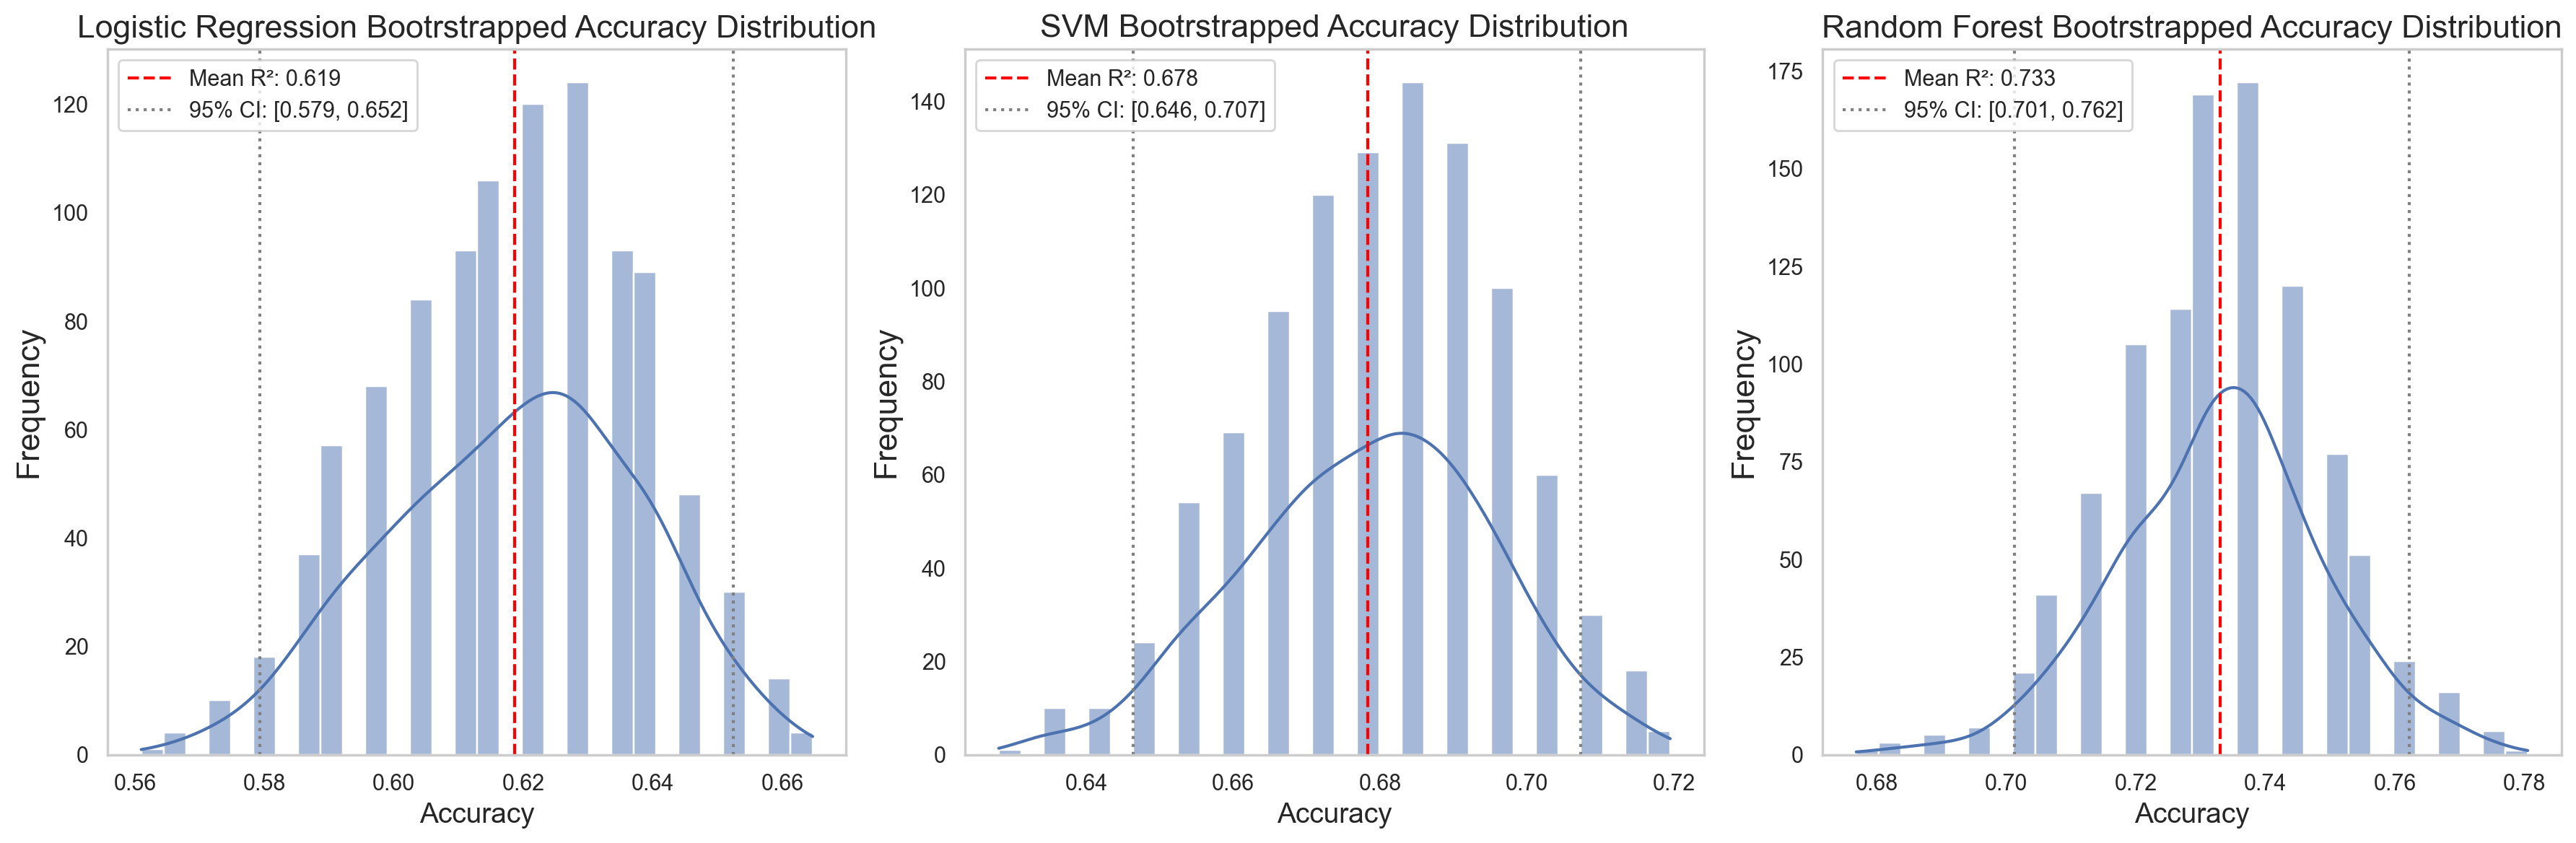

In [45]:
plot_bootstrap_histograms([logr_accs, svm_accs, rf_accs], ["Logistic Regression", "SVM", "Random Forest"])

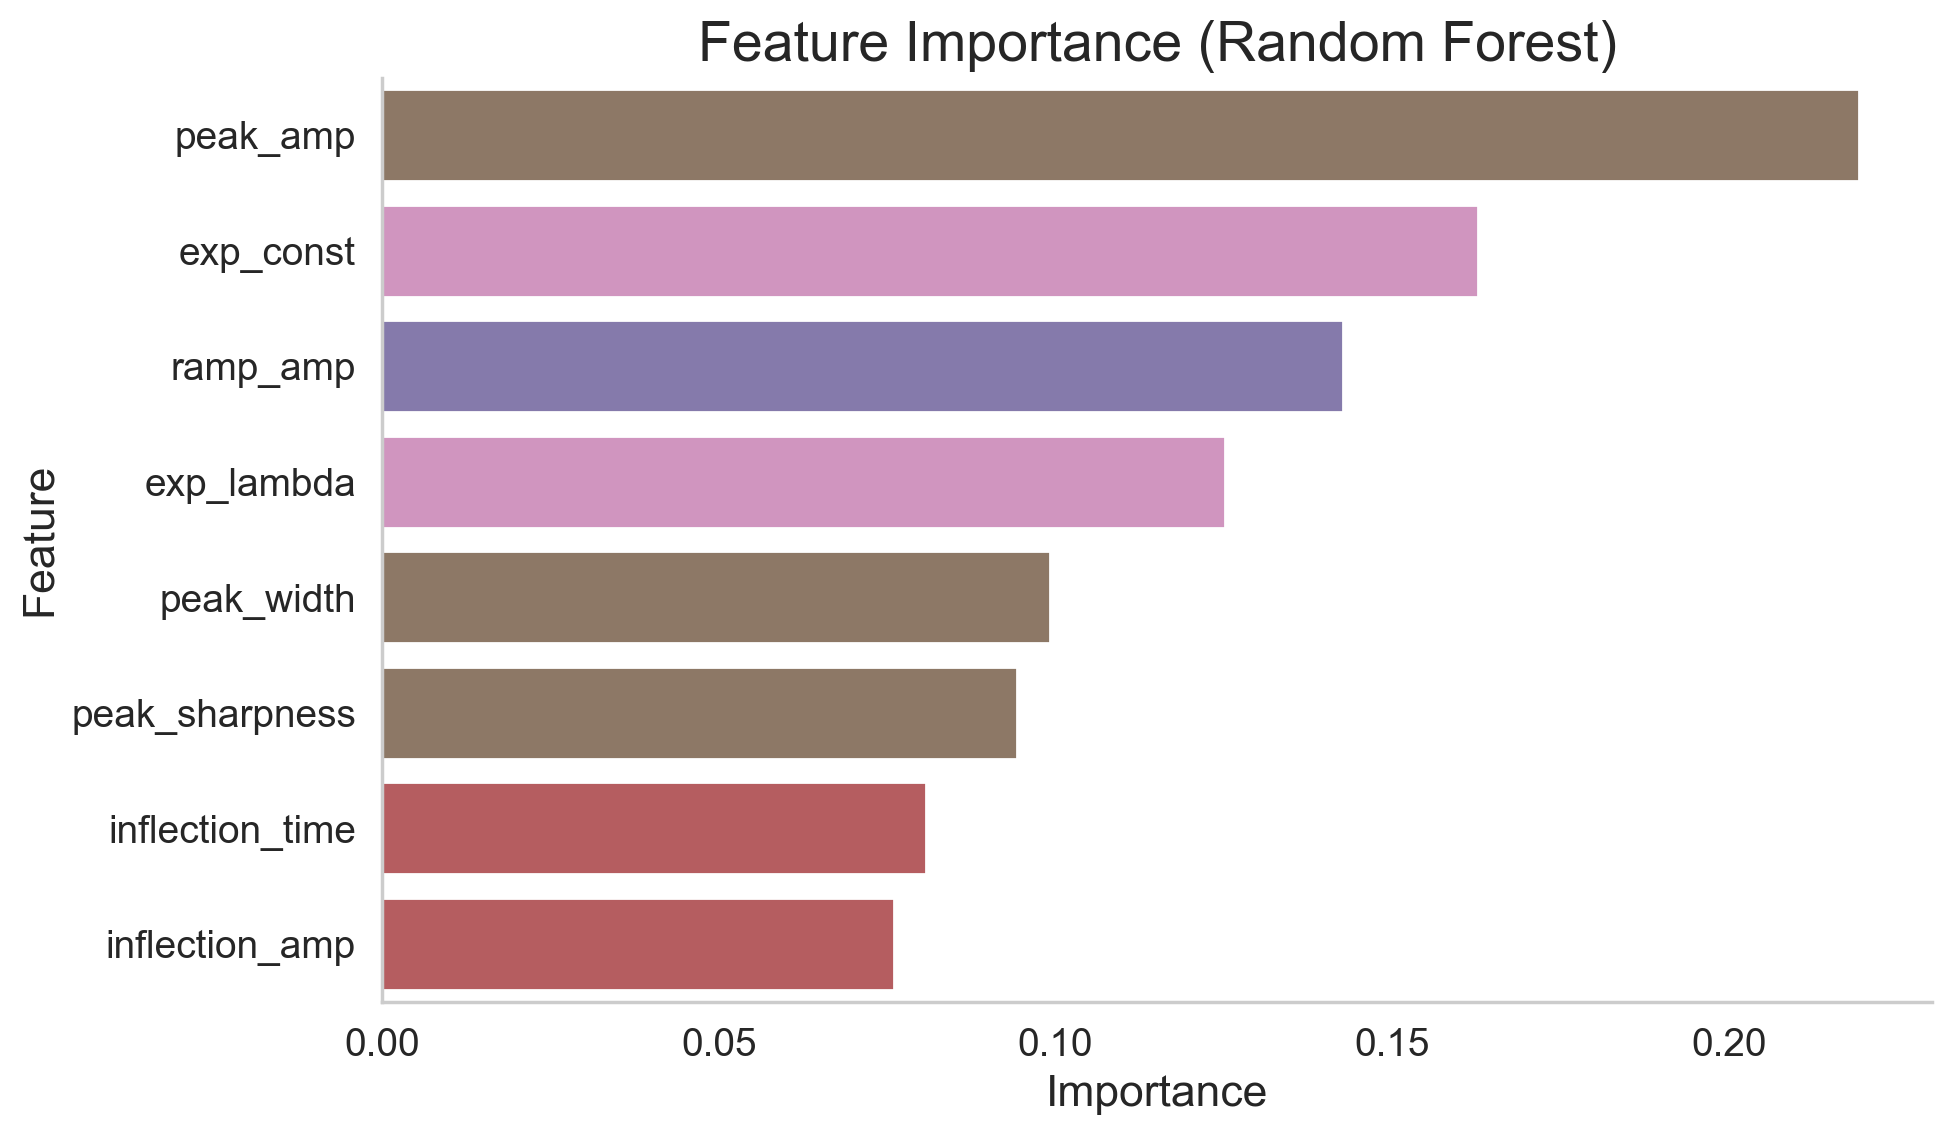

In [46]:
plot_feature_importance_categorical(rf_model,X)

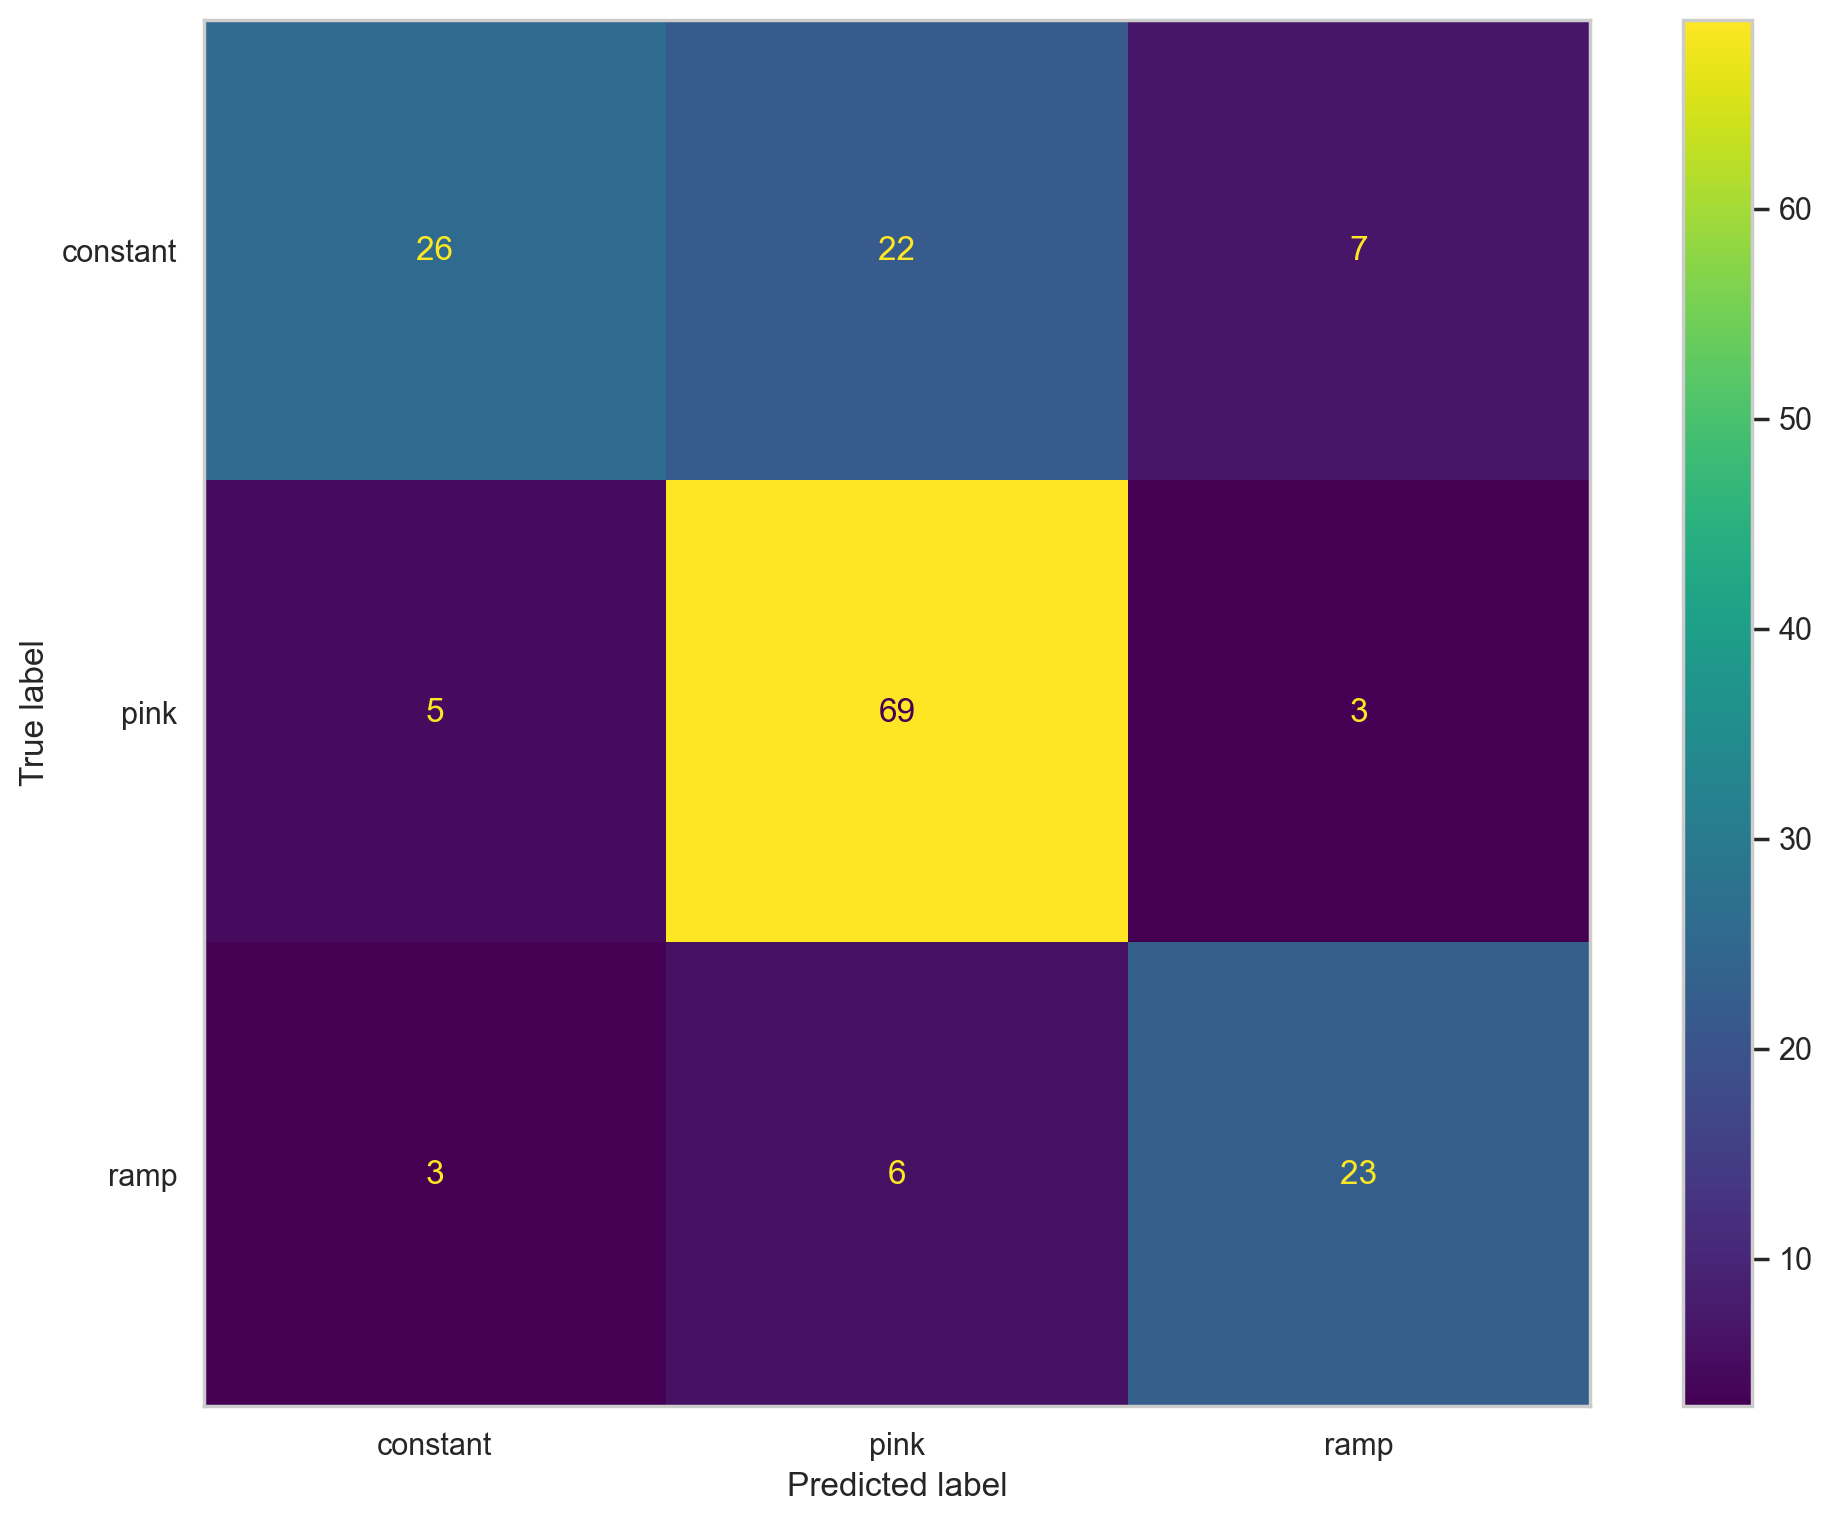

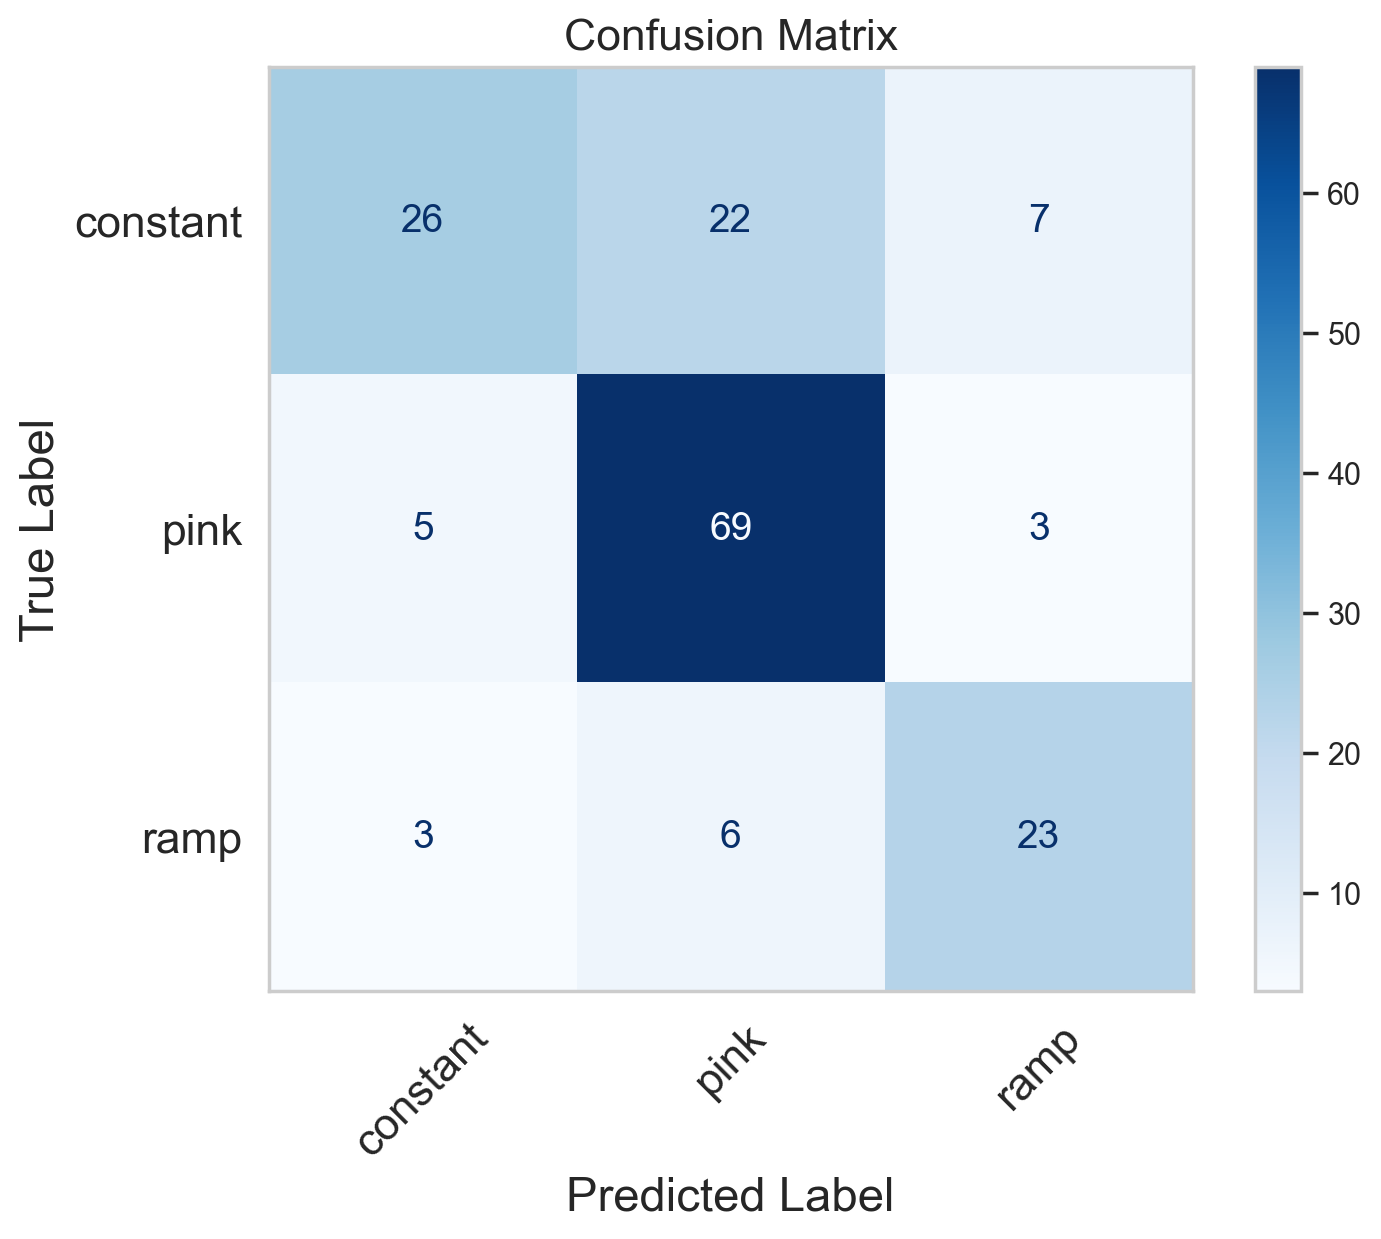

In [47]:
plot_confusion_matrix(rf_model, X_test, y_test)

## 7. Regression: Predicting Stimulus Statistics

We shift from categorical decoding to continuous regression: using ridge regression (k-fold CV), we predict instantaneous pink noise stimulus properties (exponent, mean, std) from spike waveform features. R² tells us how much variance in the stimulus is captured by waveform shape alone — a key estimate of how faithfully spike morphology tracks the input.

In [ ]:
pickle_path = os.path.join(PICKLE_DIR, 'ridge_results_stim_stats.pkl')
if not FORCE_RERUN and os.path.exists(pickle_path):
    with open(pickle_path, 'rb') as file:
        ridge_results_dict = pickle.load(file)
    print('Loaded ridge_results_dict from pickle.')
else:
    ridge_results_dict = {}
    for stim_feature in ['stim_exp', 'stim_mean', 'stim_std']:
        print(f"\n--- Processing {stim_feature} ---\n")
        data = df_pink_filtered.dropna(subset=[stim_feature])
        X = data.drop(columns=['stim_exp', 'stim_mean', 'stim_std'])
        y = data[stim_feature]
        ridge_results = run_ridge_regression_kfold(X, y)
        ridge_results_dict[stim_feature] = ridge_results
        print(f"Mean R² for {stim_feature}: {ridge_results['r2_mean']:.3f}")
        print(f"95% CI for R²: {ridge_results['r2_ci']}")
    with open(pickle_path, 'wb') as file:
        pickle.dump(ridge_results_dict, file)
    print('Saved ridge_results_dict to pickle.')

### 7a. Results


--- Plotting stim_exp ---



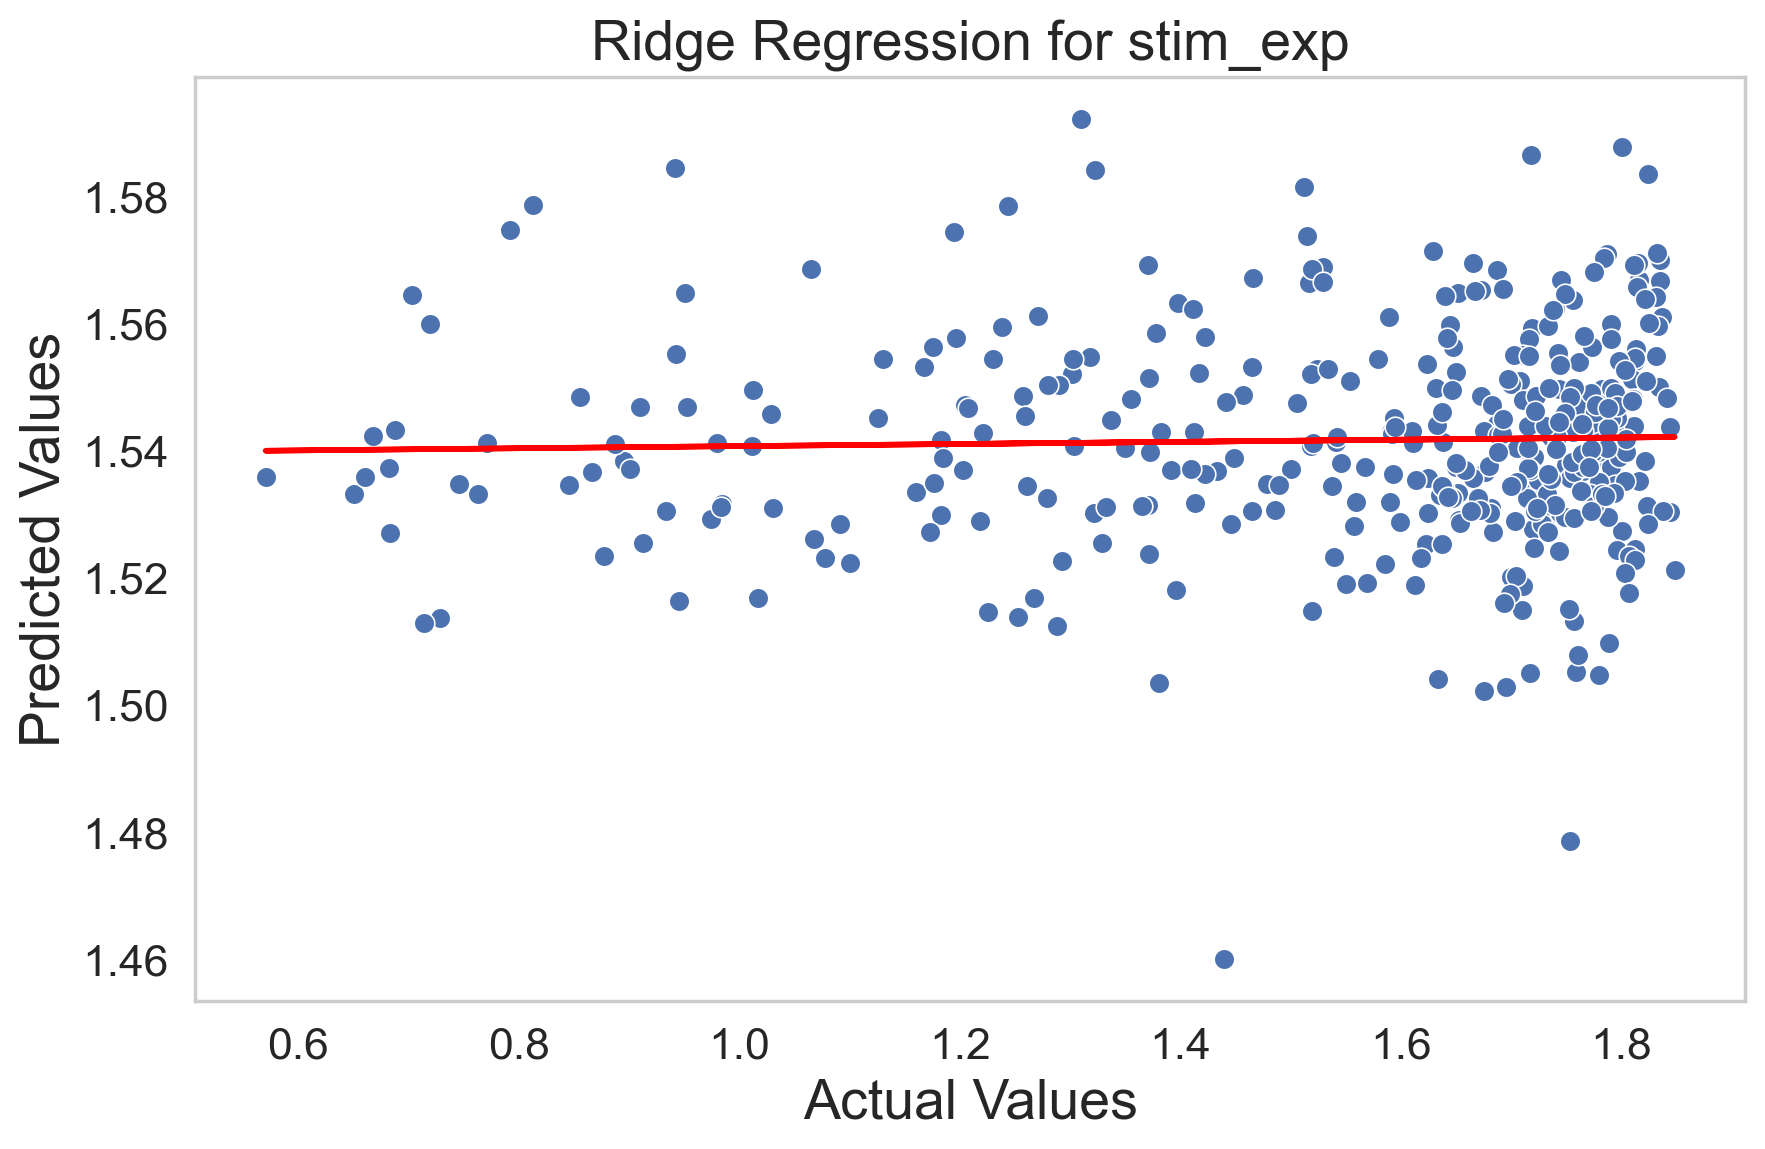

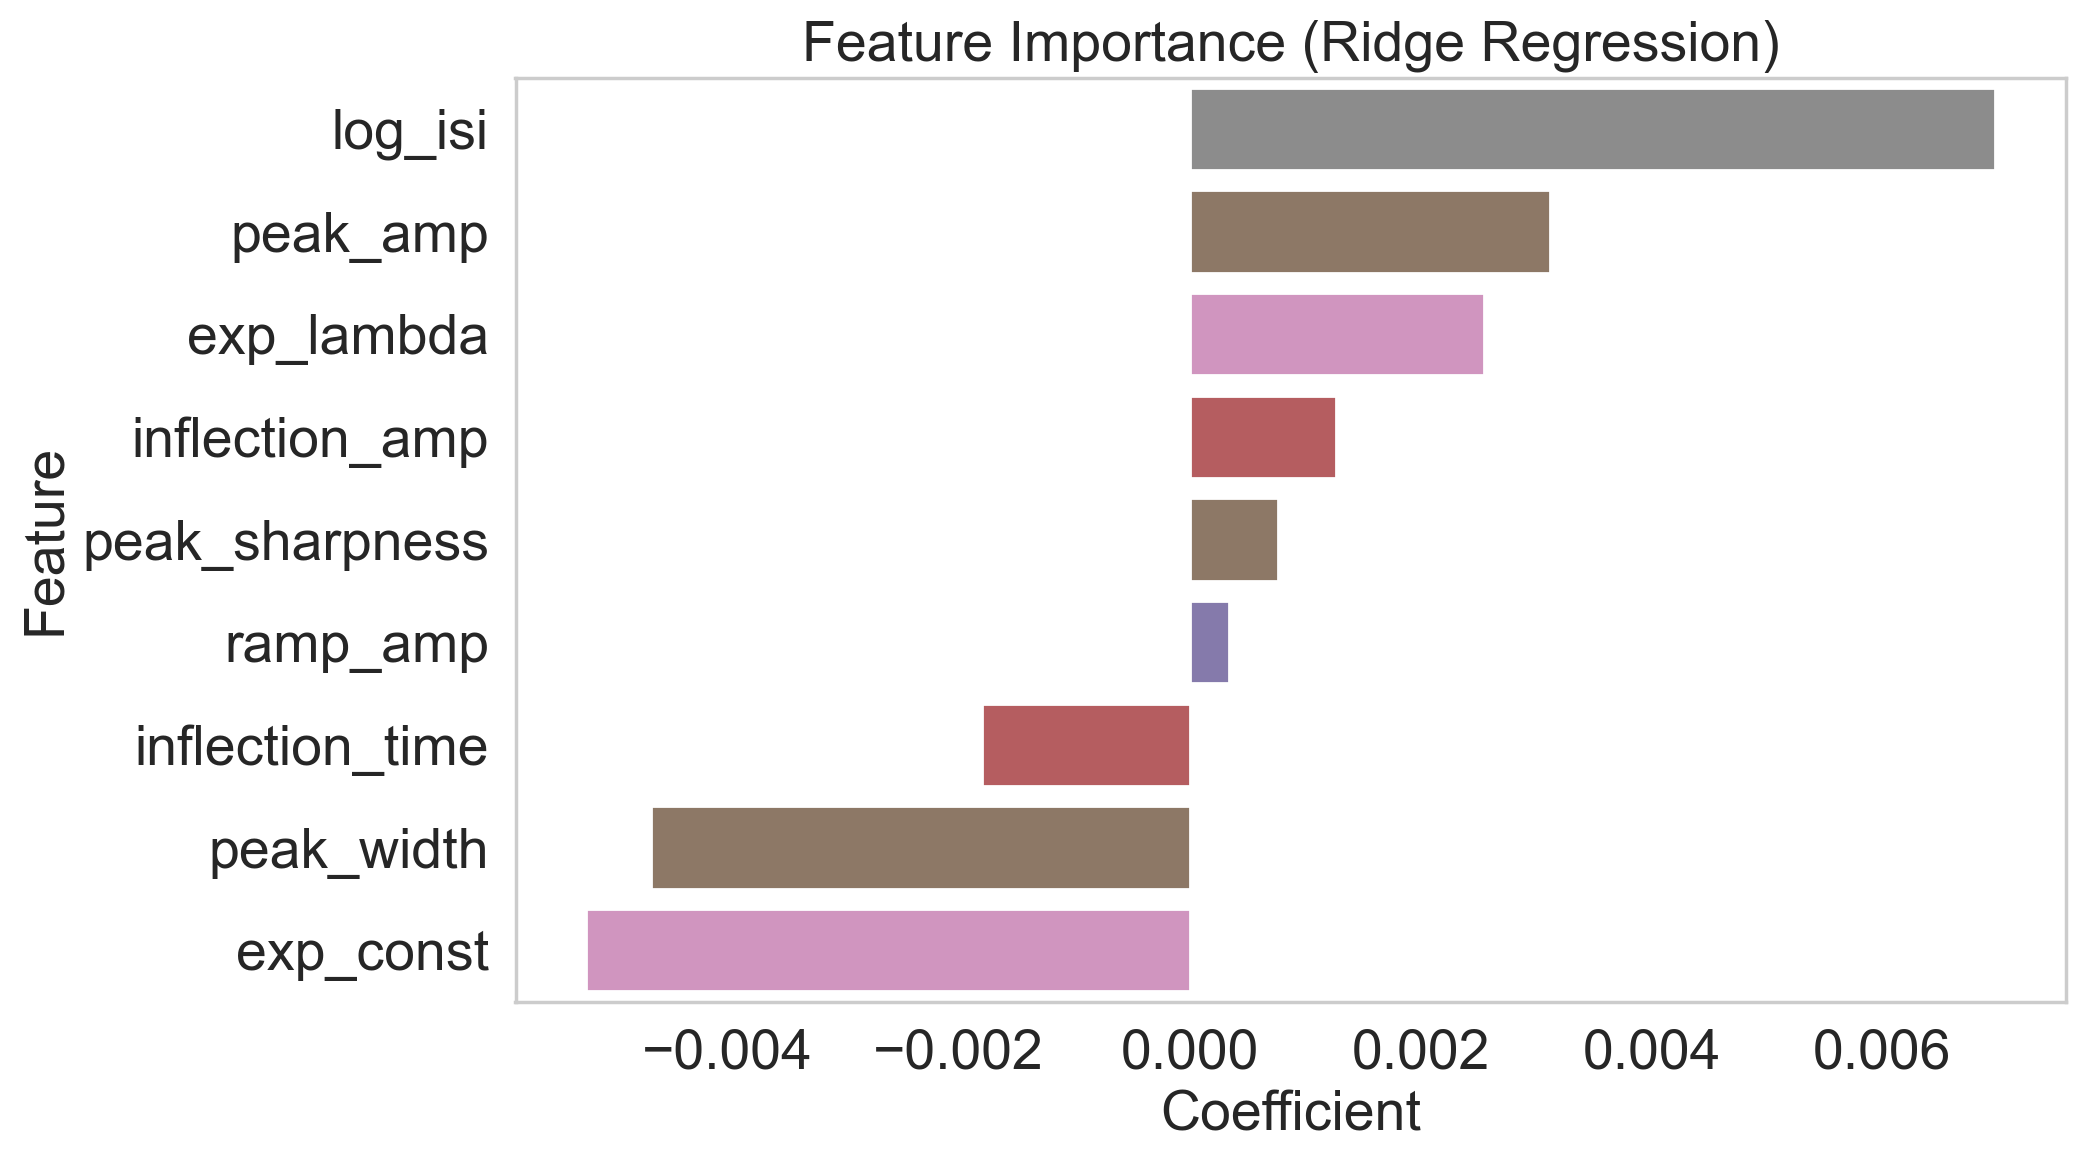


Significant Features (p < 0.05):
           Feature  Coefficient  CI Lower  CI Upper        p-value
8          log_isi     0.006975 -0.000717  0.014329   0.000000e+00
3         peak_amp     0.003119 -0.002870  0.008936  4.794588e-167
6       exp_lambda     0.002550 -0.001854  0.006289  3.529441e-192
2   inflection_amp     0.001271 -0.003106  0.005996   2.818144e-62
5   peak_sharpness     0.000762 -0.004299  0.004872   7.387642e-18
0         ramp_amp     0.000344 -0.008903  0.009112   1.514511e-02
1  inflection_time    -0.001800 -0.006077  0.003030   4.384512e-91
4       peak_width    -0.004664 -0.008647 -0.000369   0.000000e+00
7        exp_const    -0.005228 -0.011348  0.001080  1.444036e-301


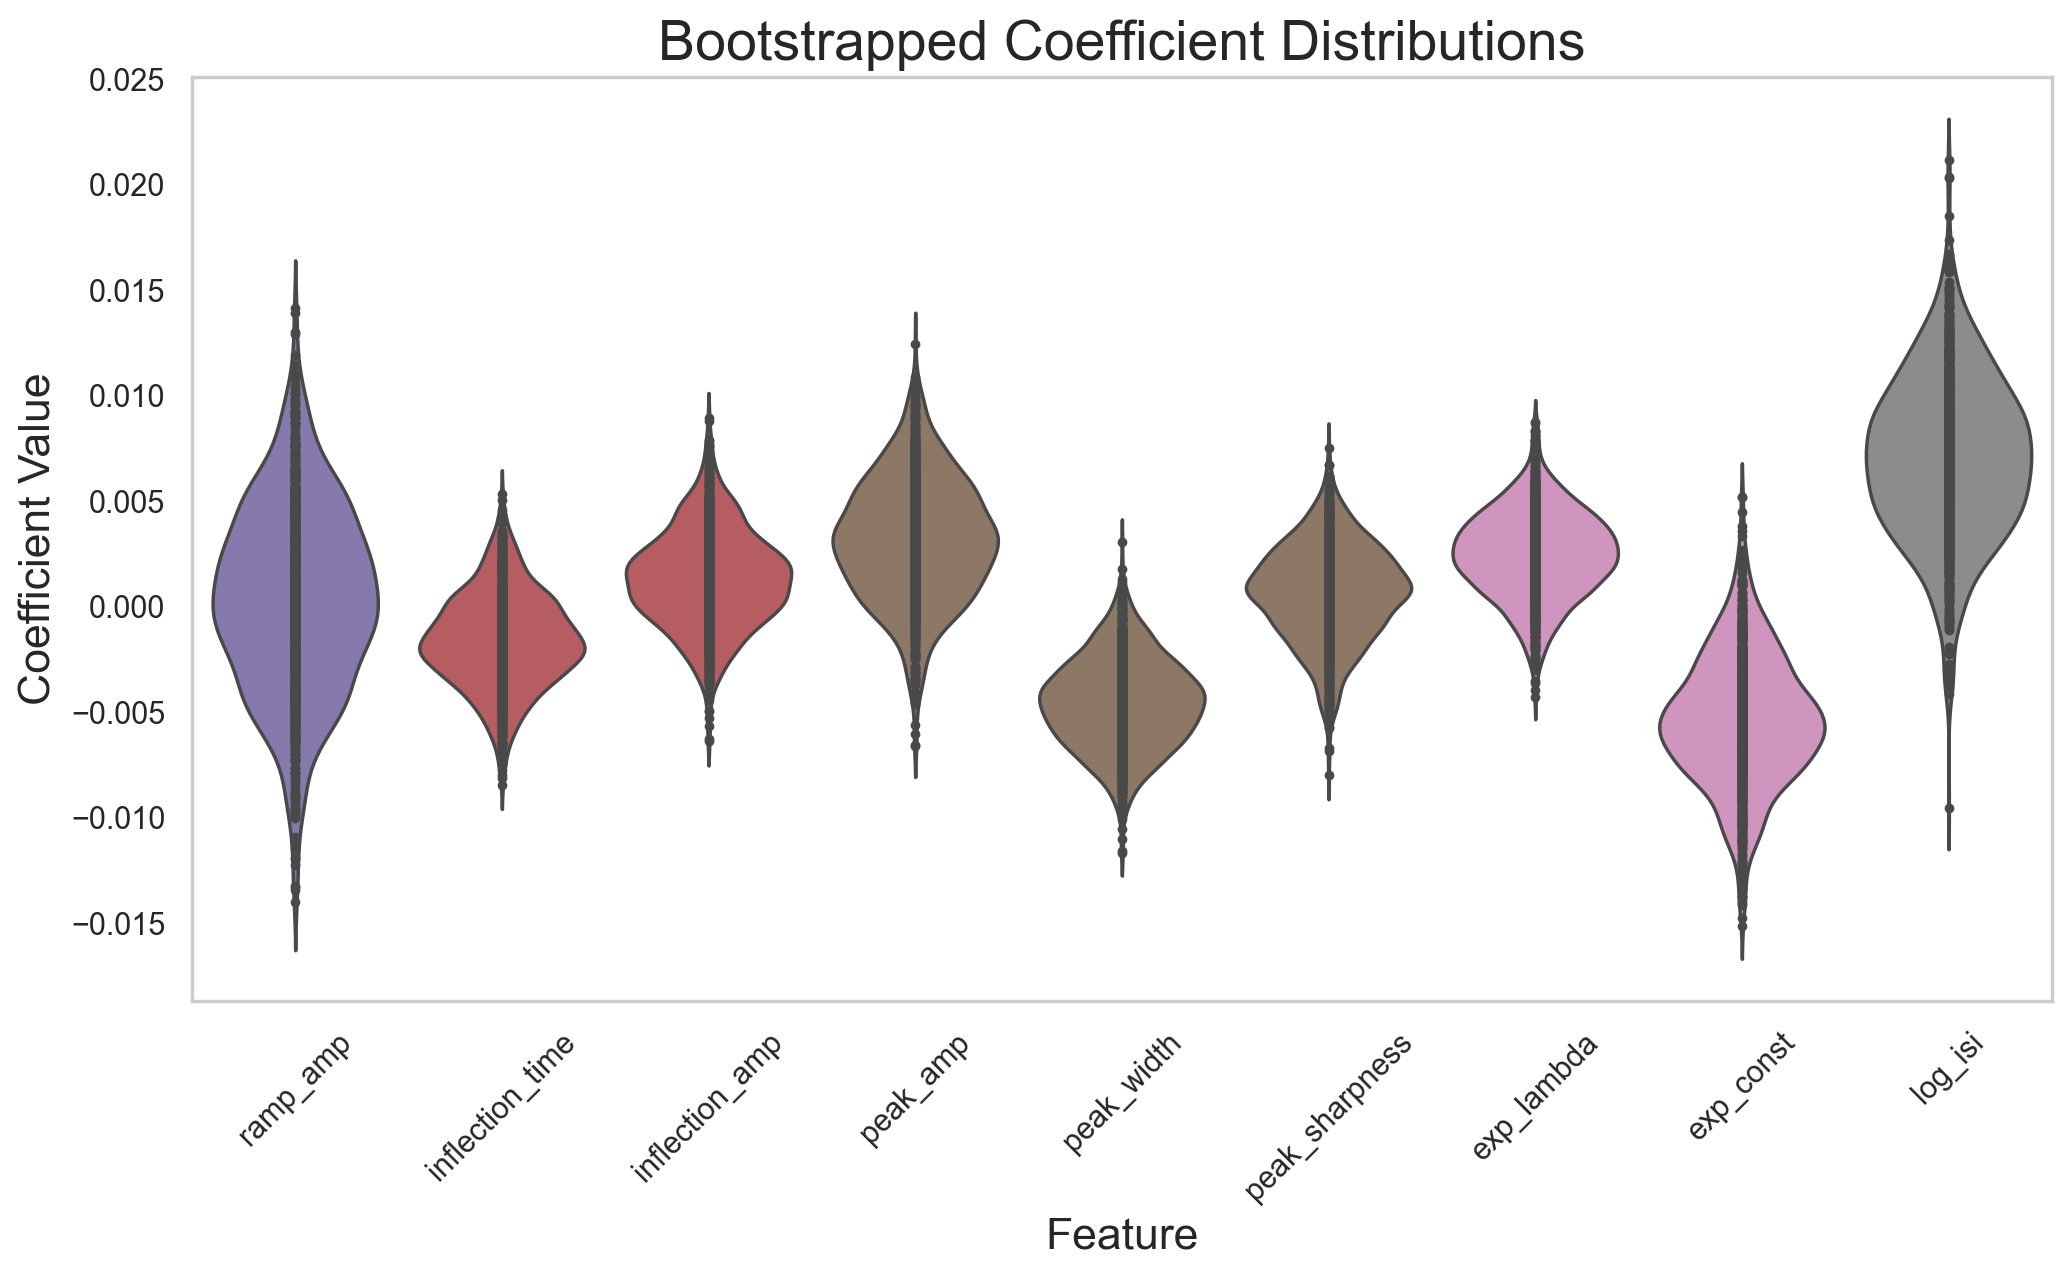

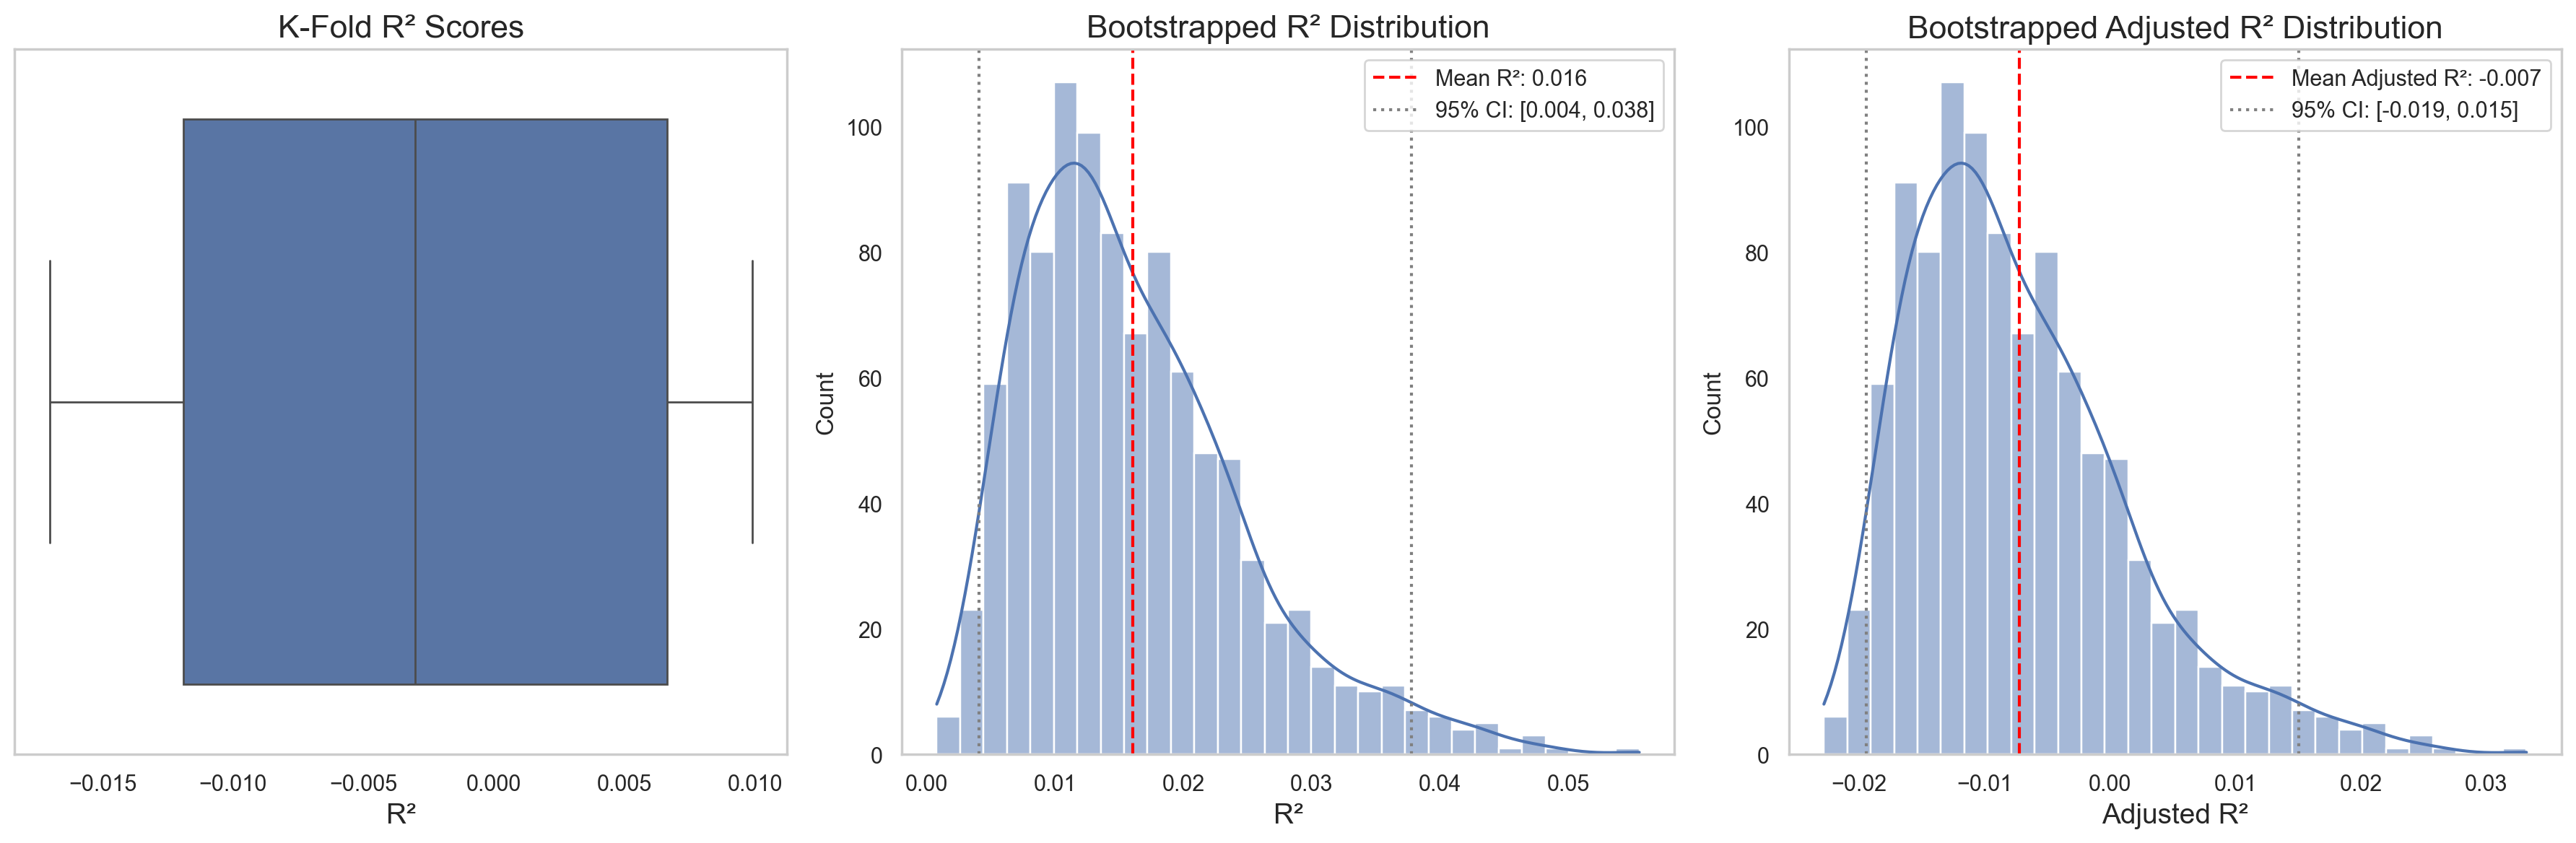


Mean Adjusted R-squared (Bootstrapped): -0.007
95% CI for Adjusted R-squared: [-0.01942285  0.01505773]

--- Plotting stim_mean ---



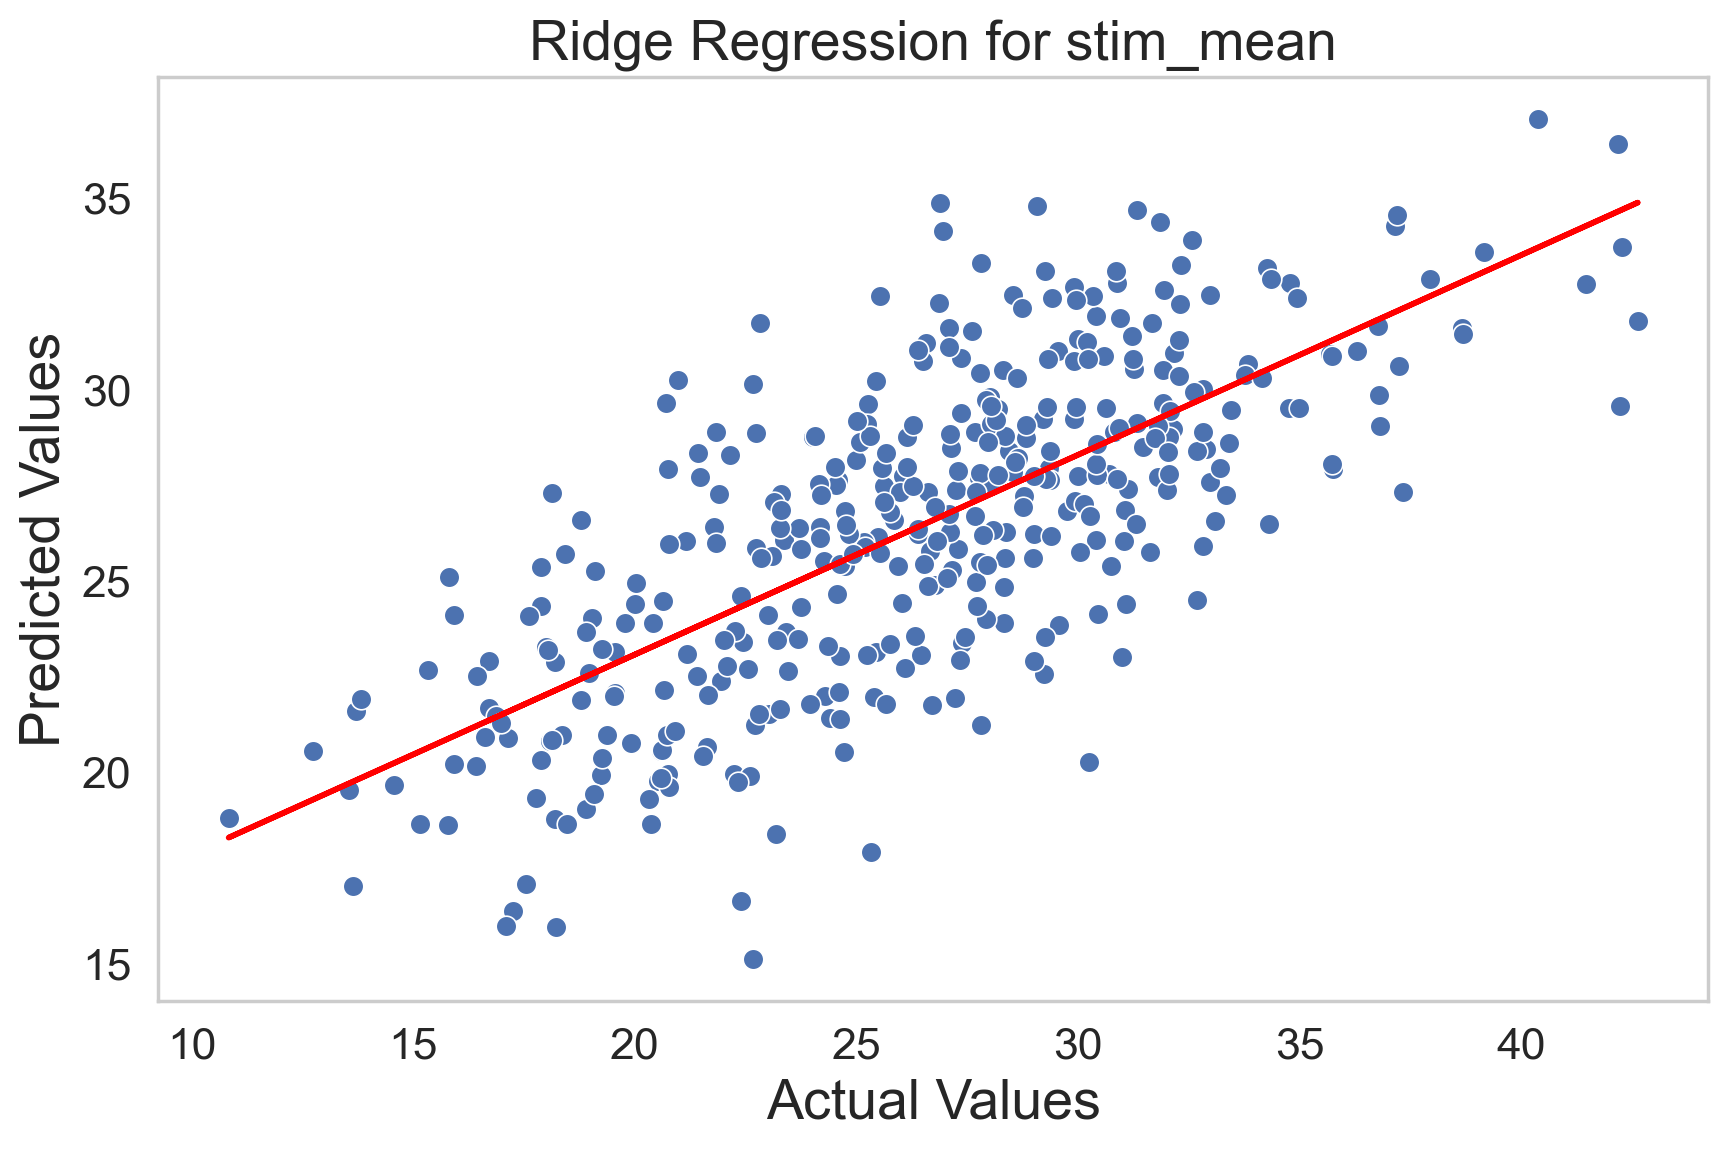

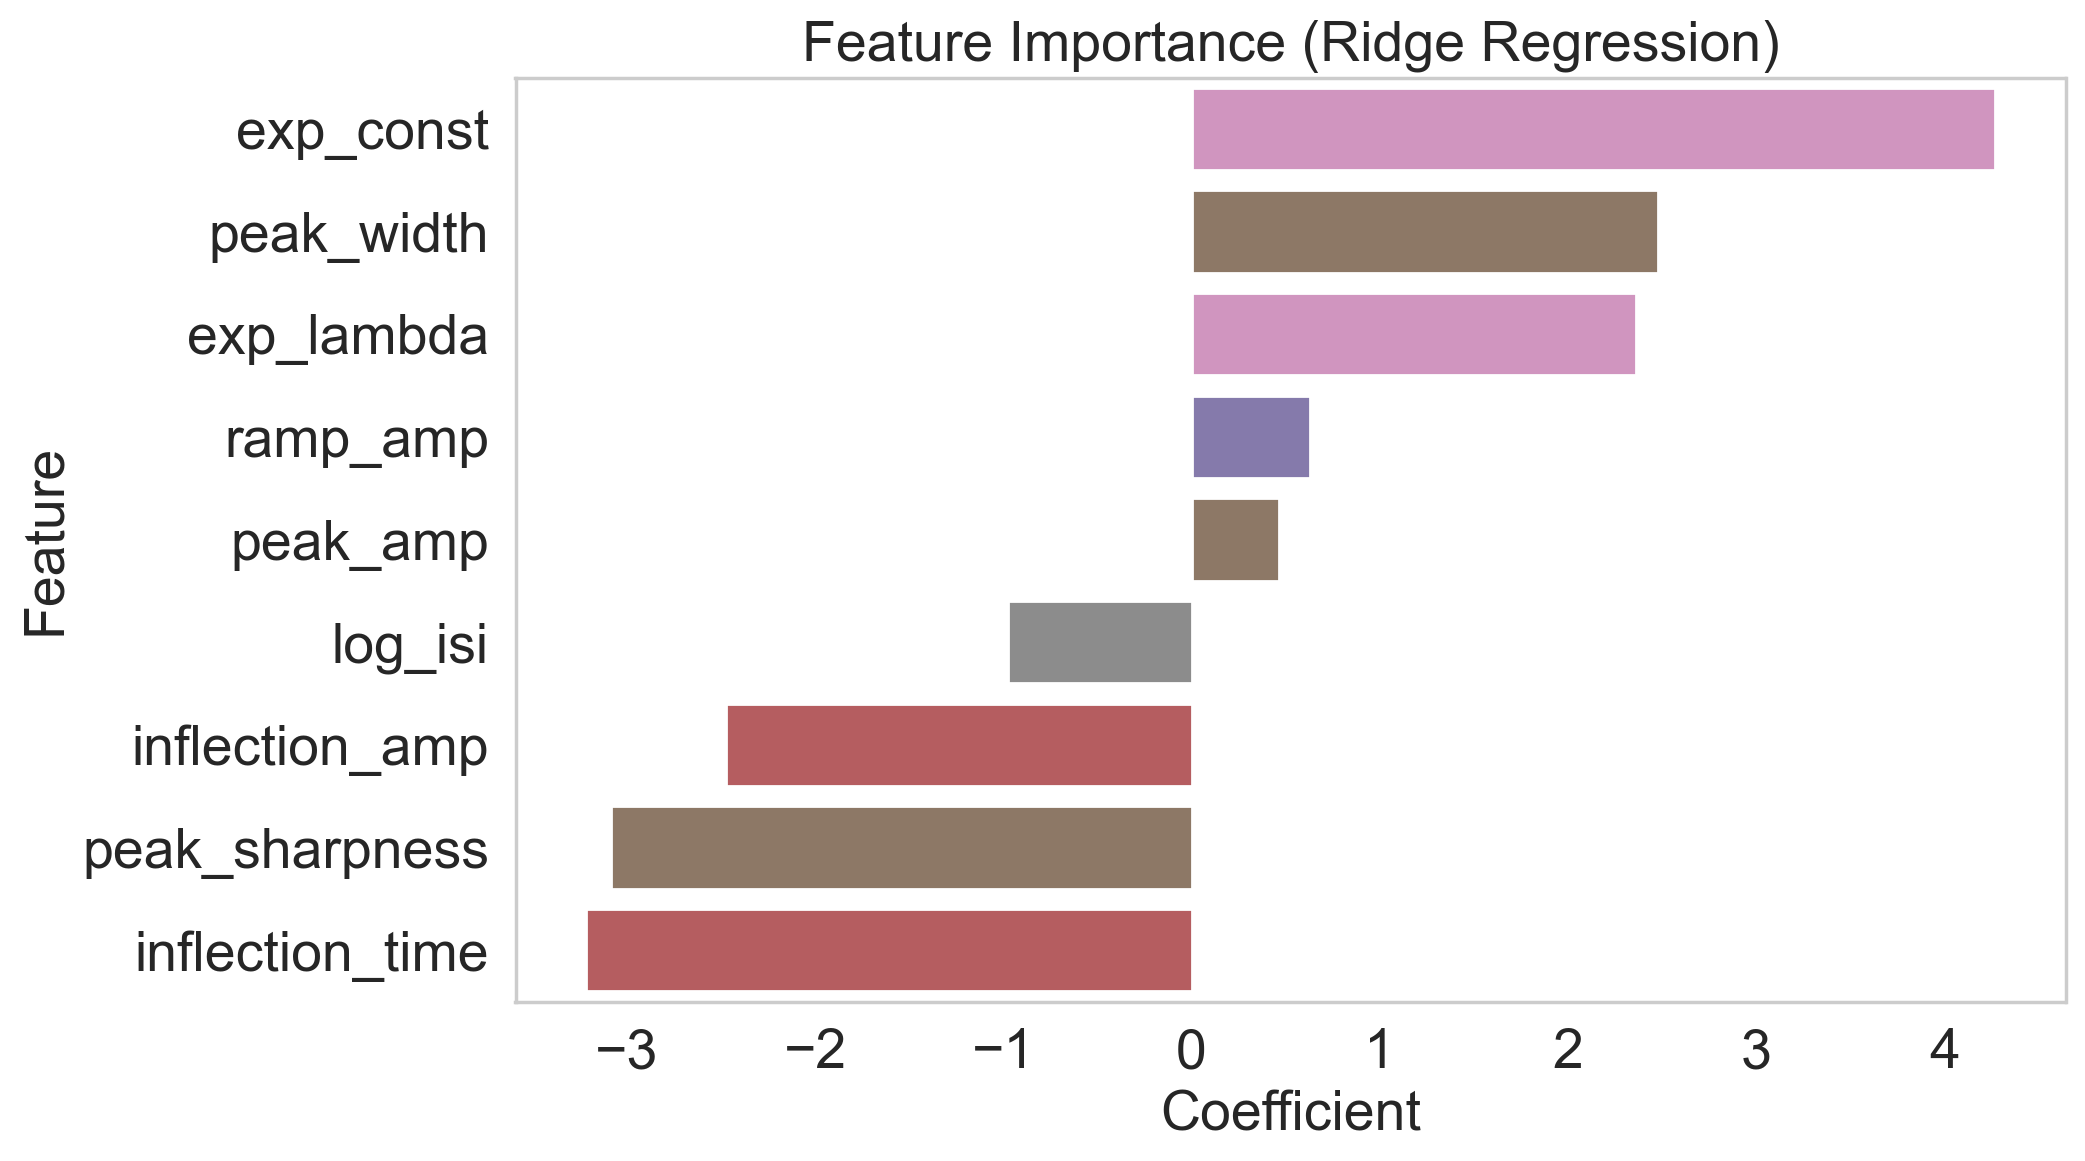


Significant Features (p < 0.05):
           Feature  Coefficient  CI Lower  CI Upper        p-value
7        exp_const     4.267334  3.477738  5.027735   0.000000e+00
4       peak_width     2.477927  0.486317  4.213561   0.000000e+00
6       exp_lambda     2.357954  0.696813  3.861153   0.000000e+00
0         ramp_amp     0.627916  0.215169  1.060572   0.000000e+00
3         peak_amp     0.465375 -0.149782  1.084607  6.001856e-247
8          log_isi    -0.975502 -1.356432 -0.599649   0.000000e+00
2   inflection_amp    -2.474677 -3.758895 -1.257672   0.000000e+00
5   peak_sharpness    -3.083268 -4.667533 -1.651146   0.000000e+00
1  inflection_time    -3.216266 -4.850014 -1.769557   0.000000e+00


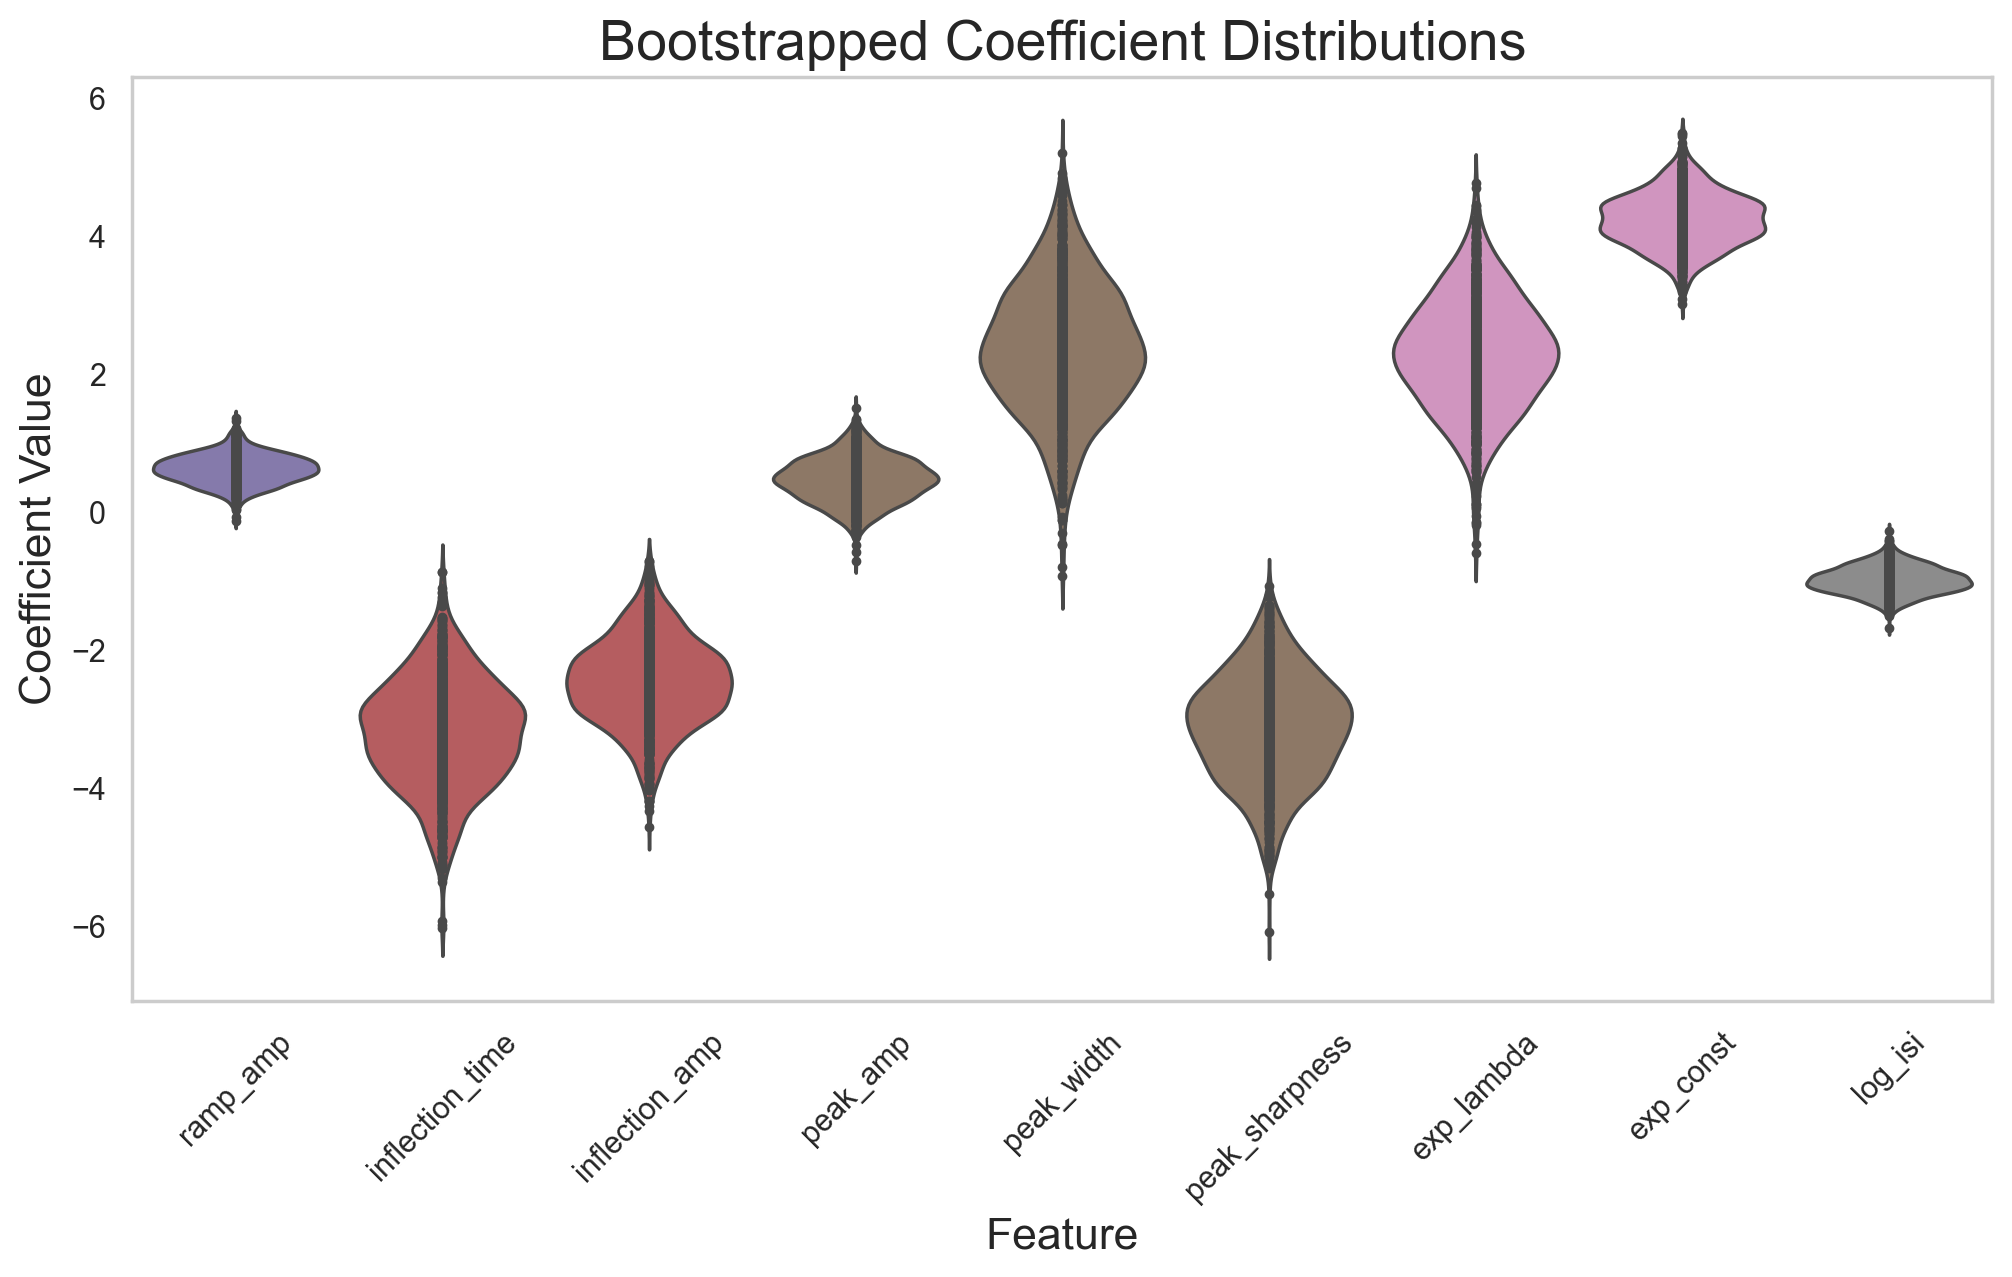

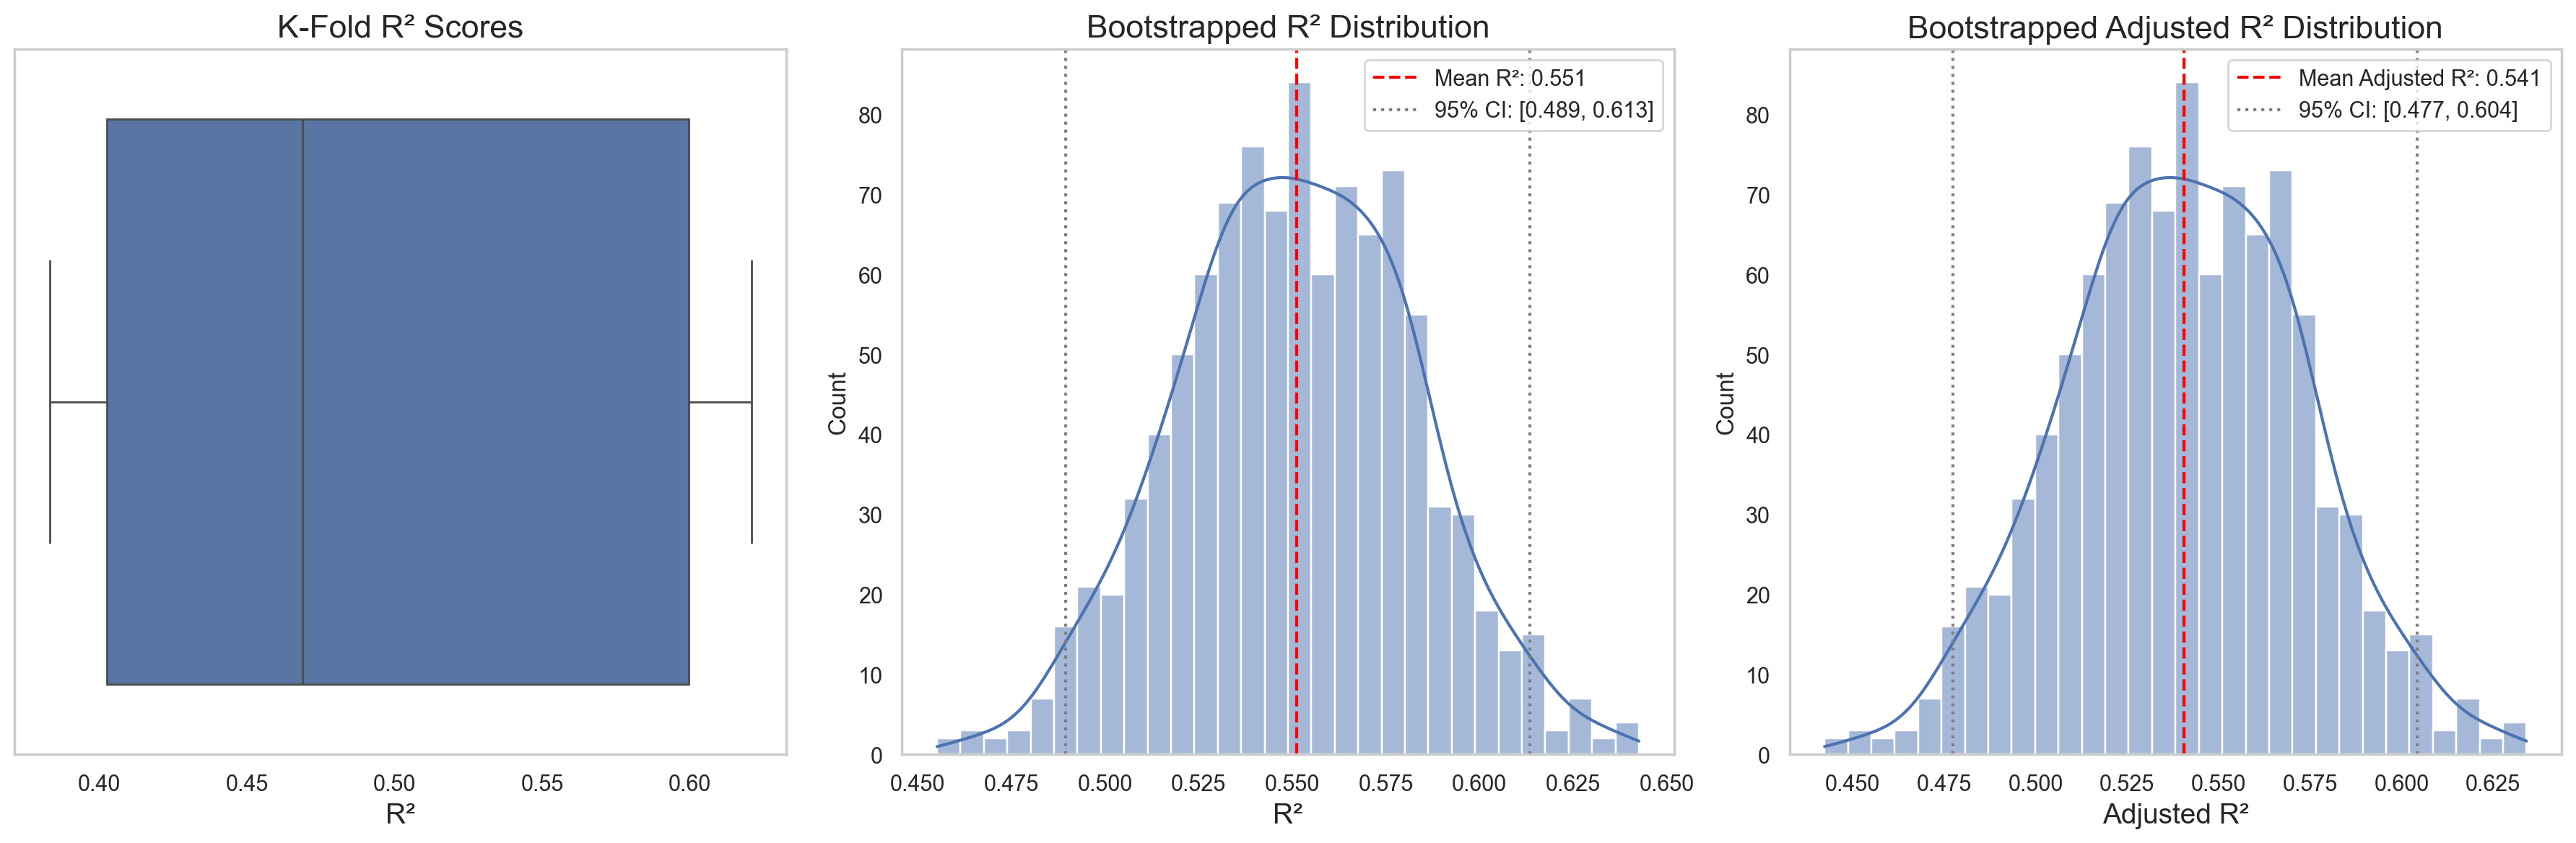


Mean Adjusted R-squared (Bootstrapped): 0.541
95% CI for Adjusted R-squared: [0.47743143 0.60431341]

--- Plotting stim_std ---



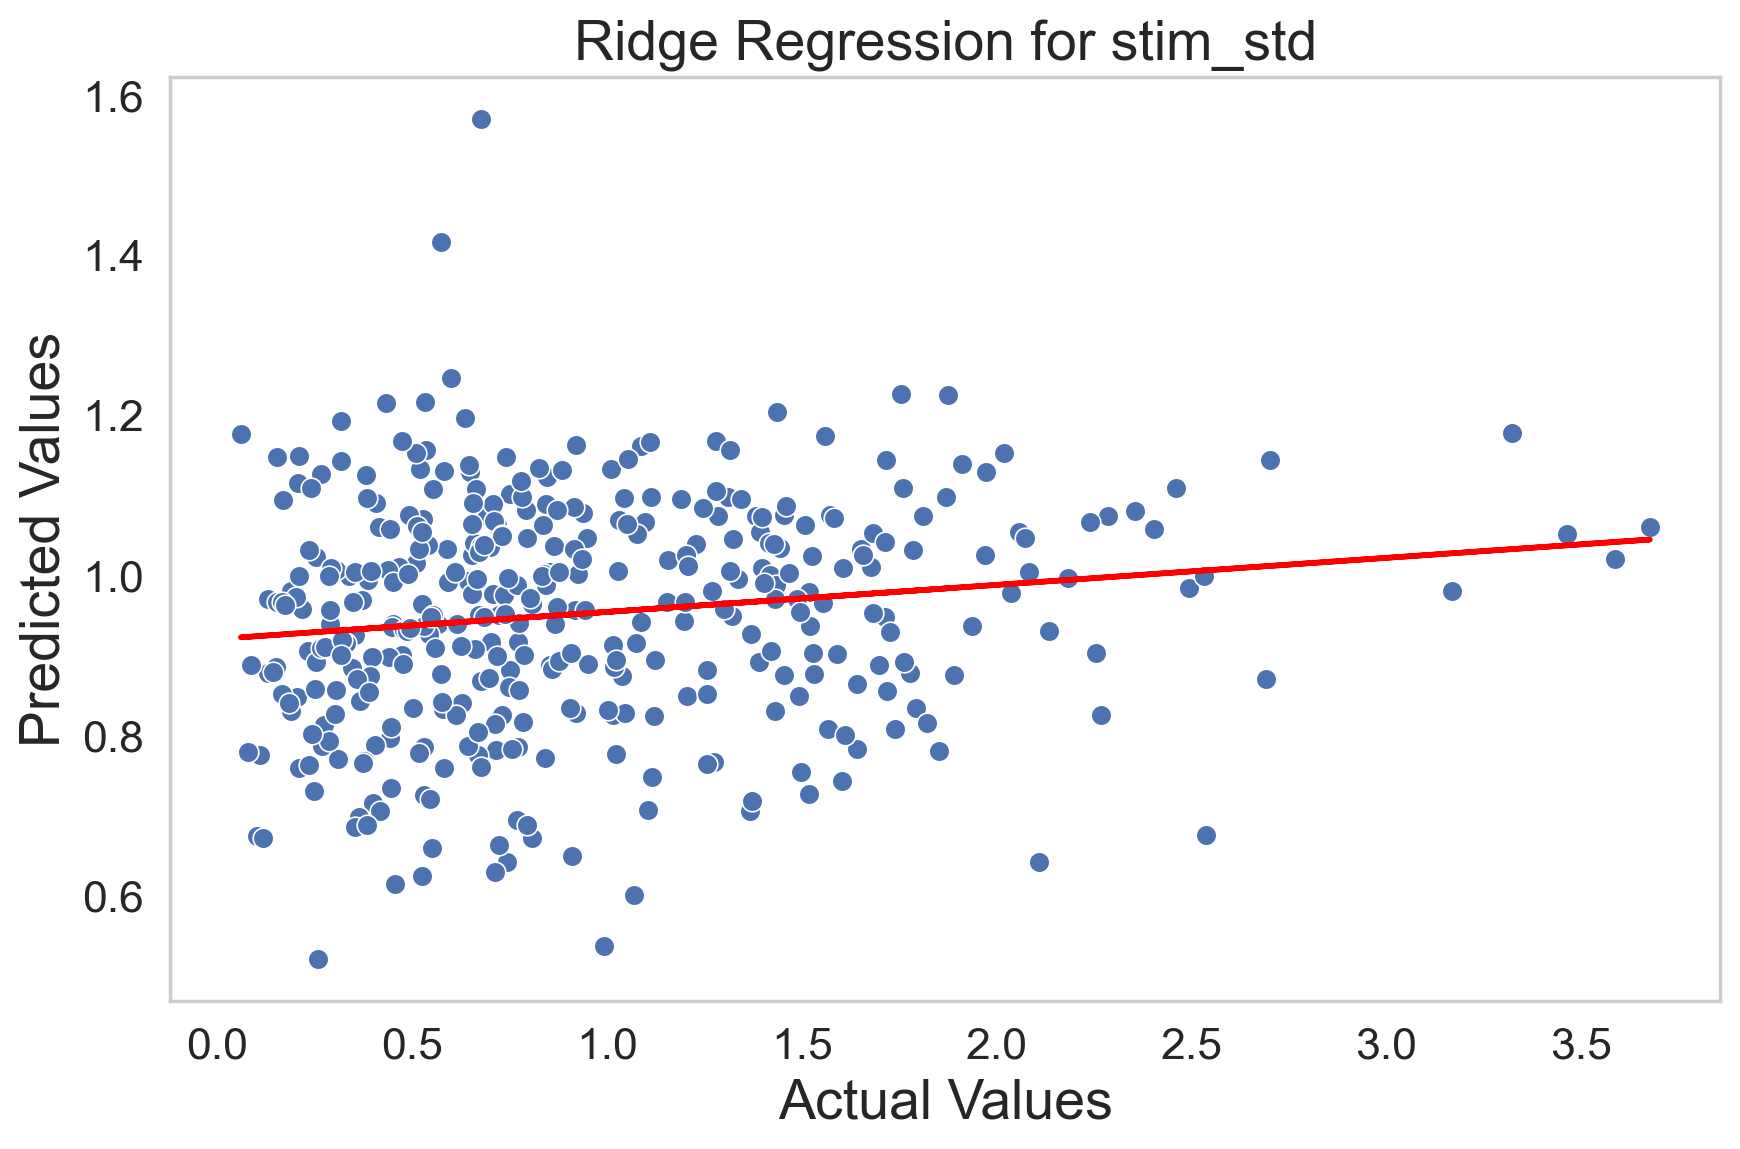

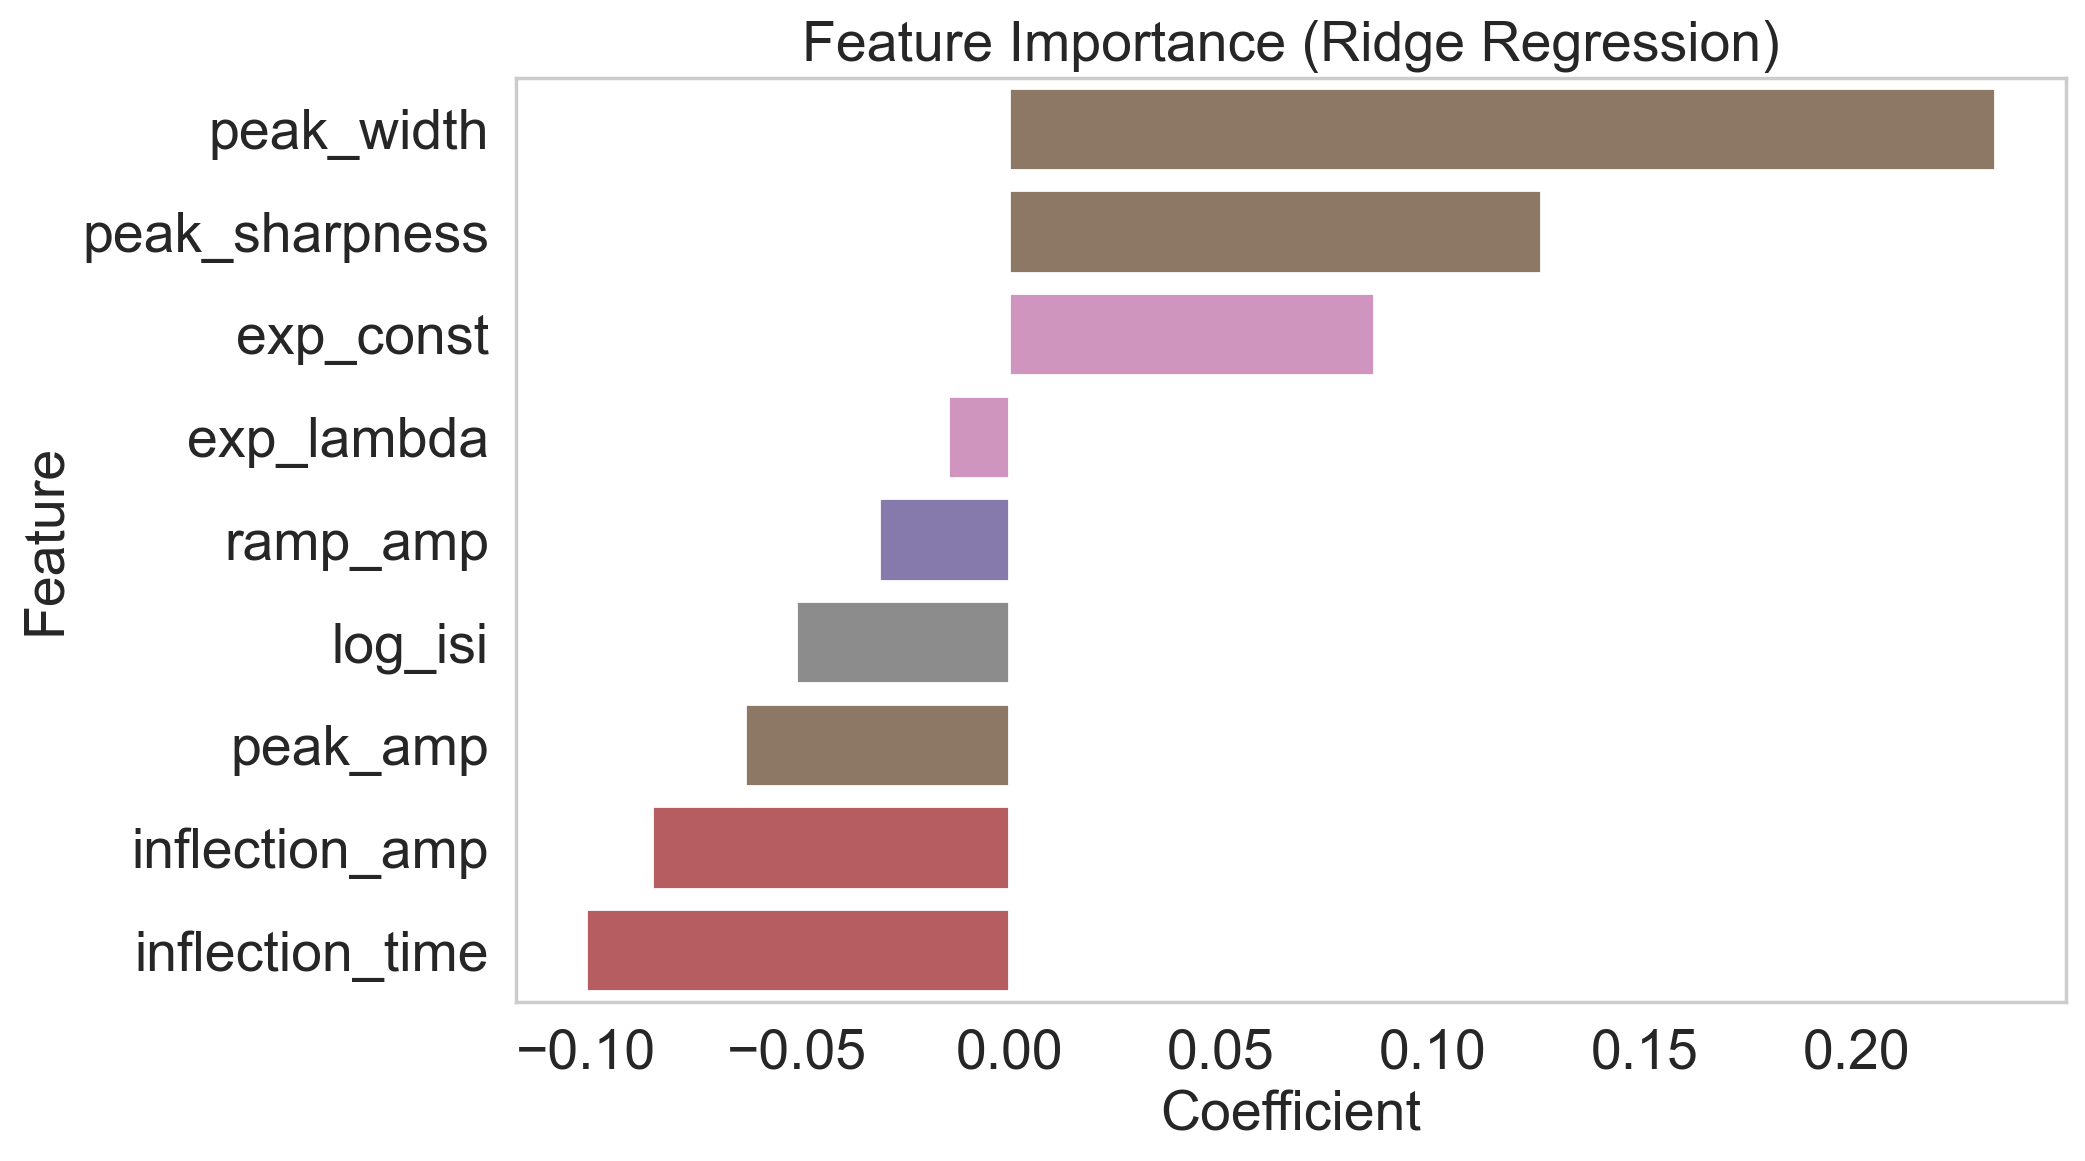


Significant Features (p < 0.05):
           Feature  Coefficient  CI Lower  CI Upper        p-value
4       peak_width     0.232780  0.071609  0.406219   0.000000e+00
5   peak_sharpness     0.125526 -0.022638  0.288834  1.116317e-284
7        exp_const     0.086076  0.000097  0.175114   0.000000e+00
6       exp_lambda    -0.014520 -0.149487  0.132113   7.672784e-06
0         ramp_amp    -0.030802 -0.096011  0.035656  1.527368e-133
8          log_isi    -0.050430 -0.111720  0.013390  1.757419e-267
3         peak_amp    -0.062388 -0.152923  0.035374  9.622183e-226
2   inflection_amp    -0.084371 -0.212648  0.047997  1.152501e-193
1  inflection_time    -0.099935 -0.245604  0.040110  3.229162e-219


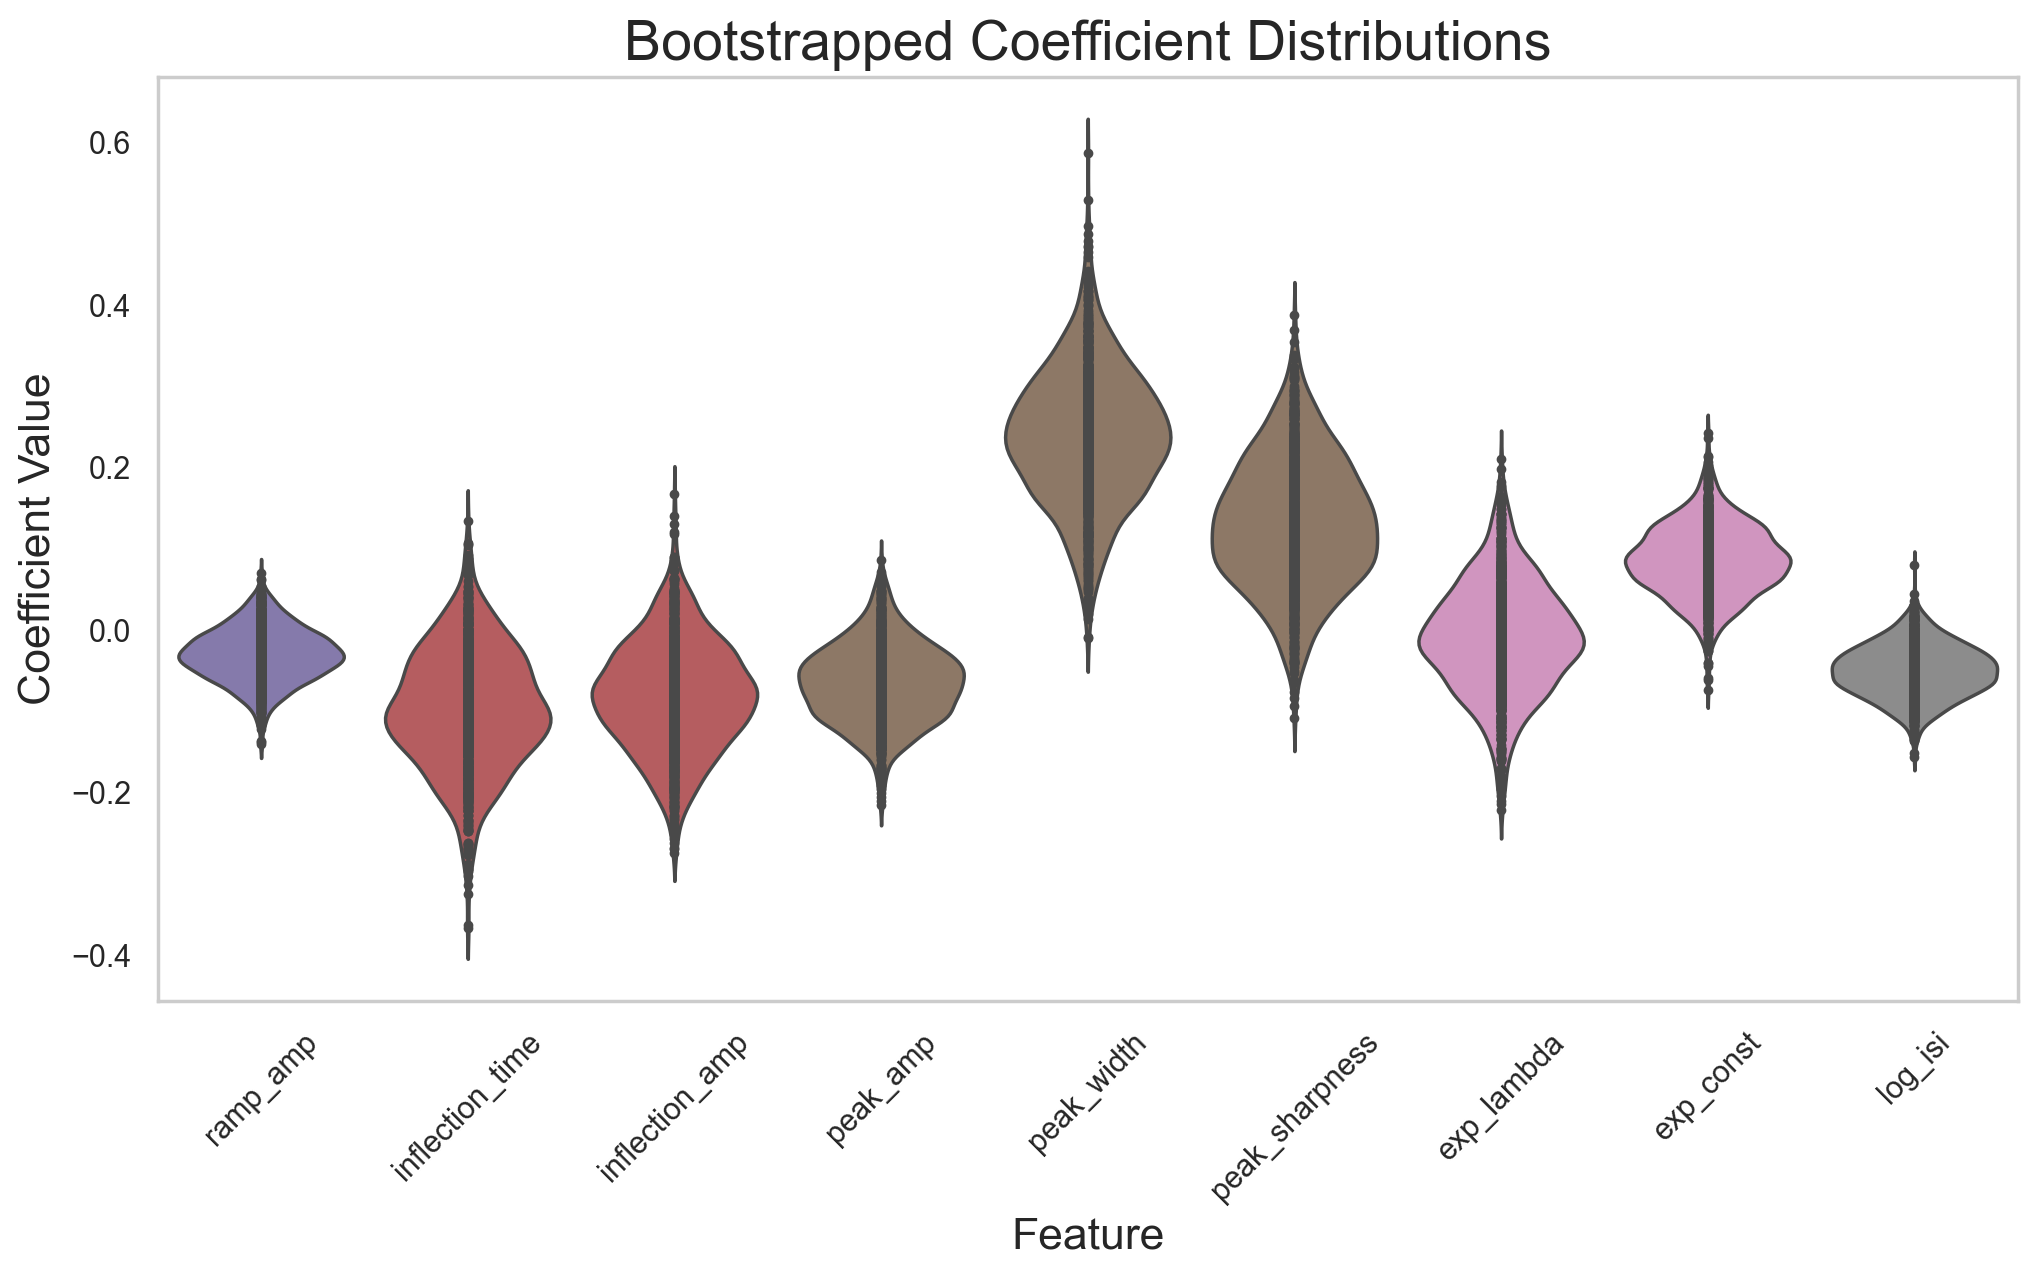

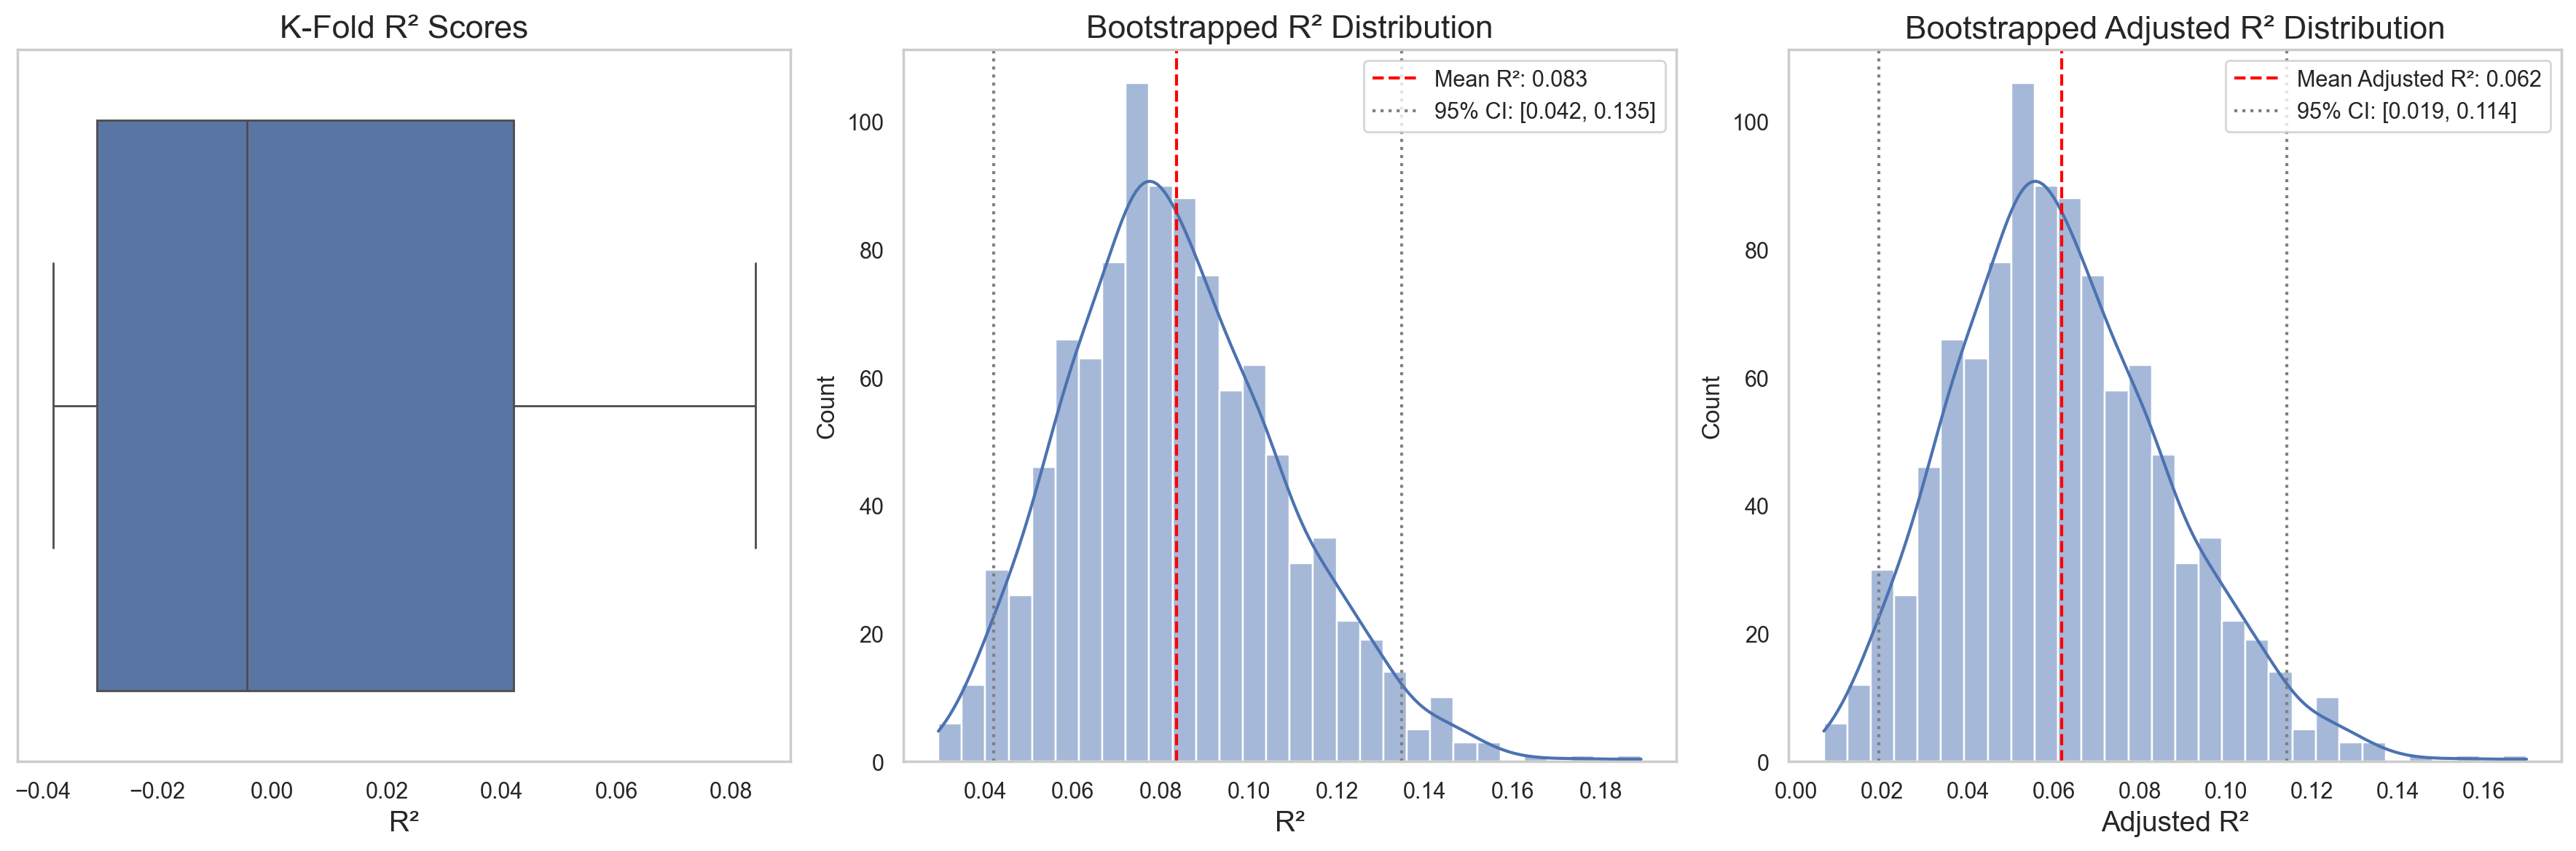


Mean Adjusted R-squared (Bootstrapped): 0.062
95% CI for Adjusted R-squared: [0.0193397  0.11427068]
FDR (BH, q=0.05): 2/3 raw p<0.05 → 2/3 after correction
  stim_exp         R²=0.016  p_perm=0.059  p_fdr=0.059  
  stim_mean        R²=0.551  p_perm=0.001  p_fdr=0.003 *
  stim_std         R²=0.083  p_perm=0.005  p_fdr=0.007 *


{'stim_exp': {'y_pred_cv': array([1.56659004, 1.56940285, 1.57087085, 1.56999031, 1.56685998,
         1.57835889, 1.58445928, 1.5814116 , 1.56362118, 1.55849856,
         1.58645063, 1.54614255, 1.54430017, 1.544089  , 1.54571889,
         1.55926066, 1.57104947, 1.58413733, 1.53764136, 1.5640916 ,
         1.53797766, 1.5647969 , 1.54874419, 1.54912211, 1.5921878 ,
         1.54954419, 1.55354832, 1.5509629 , 1.55789694, 1.54376976,
         1.54122106, 1.5430141 , 1.53900679, 1.56481515, 1.54857937,
         1.53737488, 1.58348855, 1.55231493, 1.54229992, 1.5609511 ,
         1.54361761, 1.53777442, 1.54851053, 1.51872901, 1.53566664,
         1.53891945, 1.54760641, 1.55398626, 1.54502628, 1.53690215,
         1.53973141, 1.54677963, 1.53433677, 1.53729813, 1.51894485,
         1.54049647, 1.52905618, 1.53979767, 1.5131681 , 1.53676276,
         1.5398091 , 1.52738747, 1.53459877, 1.53661262, 1.53397741,
         1.53559457, 1.54420714, 1.53667869, 1.52429081, 1.53316249,
         

In [49]:
for stim_feature in ['stim_exp', 'stim_mean', 'stim_std']:
    print(f"\n--- Plotting {stim_feature} ---\n")
    data = df_pink_filtered.dropna(subset=[stim_feature])
    y = data[stim_feature]
    plot_ridge_results(y, ridge_results_dict[stim_feature], title=f"Ridge Regression for {stim_feature}")

# FDR correction across the three stim-prediction regressions
apply_fdr_pvc6(ridge_results_dict)

## 8. Regression: Predicting Log ISI

Log ISI is a proxy for instantaneous firing rate — a direct readout of neural drive. We fit three ridge regression models: (1) spike waveform features only, (2) stimulus features only, (3) both combined. Comparing R² across models tells us how much of firing rate variability is explained by waveform shape alone, whether the stimulus adds independent information, and whether waveform features are essentially redundant with the stimulus signal.

### 8a. Model 1 — Spike Waveform Features Only

In [ ]:
y_log_isi = df_pink_filtered['log_isi']

pickle_path = os.path.join(PICKLE_DIR, 'ridge_results_spike_only.pkl')
if not FORCE_RERUN and os.path.exists(pickle_path):
    with open(pickle_path, 'rb') as file:
        ridge_results_spike_only = pickle.load(file)
    print('Loaded ridge_results_spike_only from pickle.')
else:
    X_spike_only = df_pink_filtered.drop(columns=['log_isi', 'stim_exp', 'stim_mean', 'stim_std'])
    ridge_results_spike_only = run_ridge_regression_kfold(X_spike_only, y_log_isi)
    with open(pickle_path, 'wb') as file:
        pickle.dump(ridge_results_spike_only, file)
    print('Saved ridge_results_spike_only to pickle.')

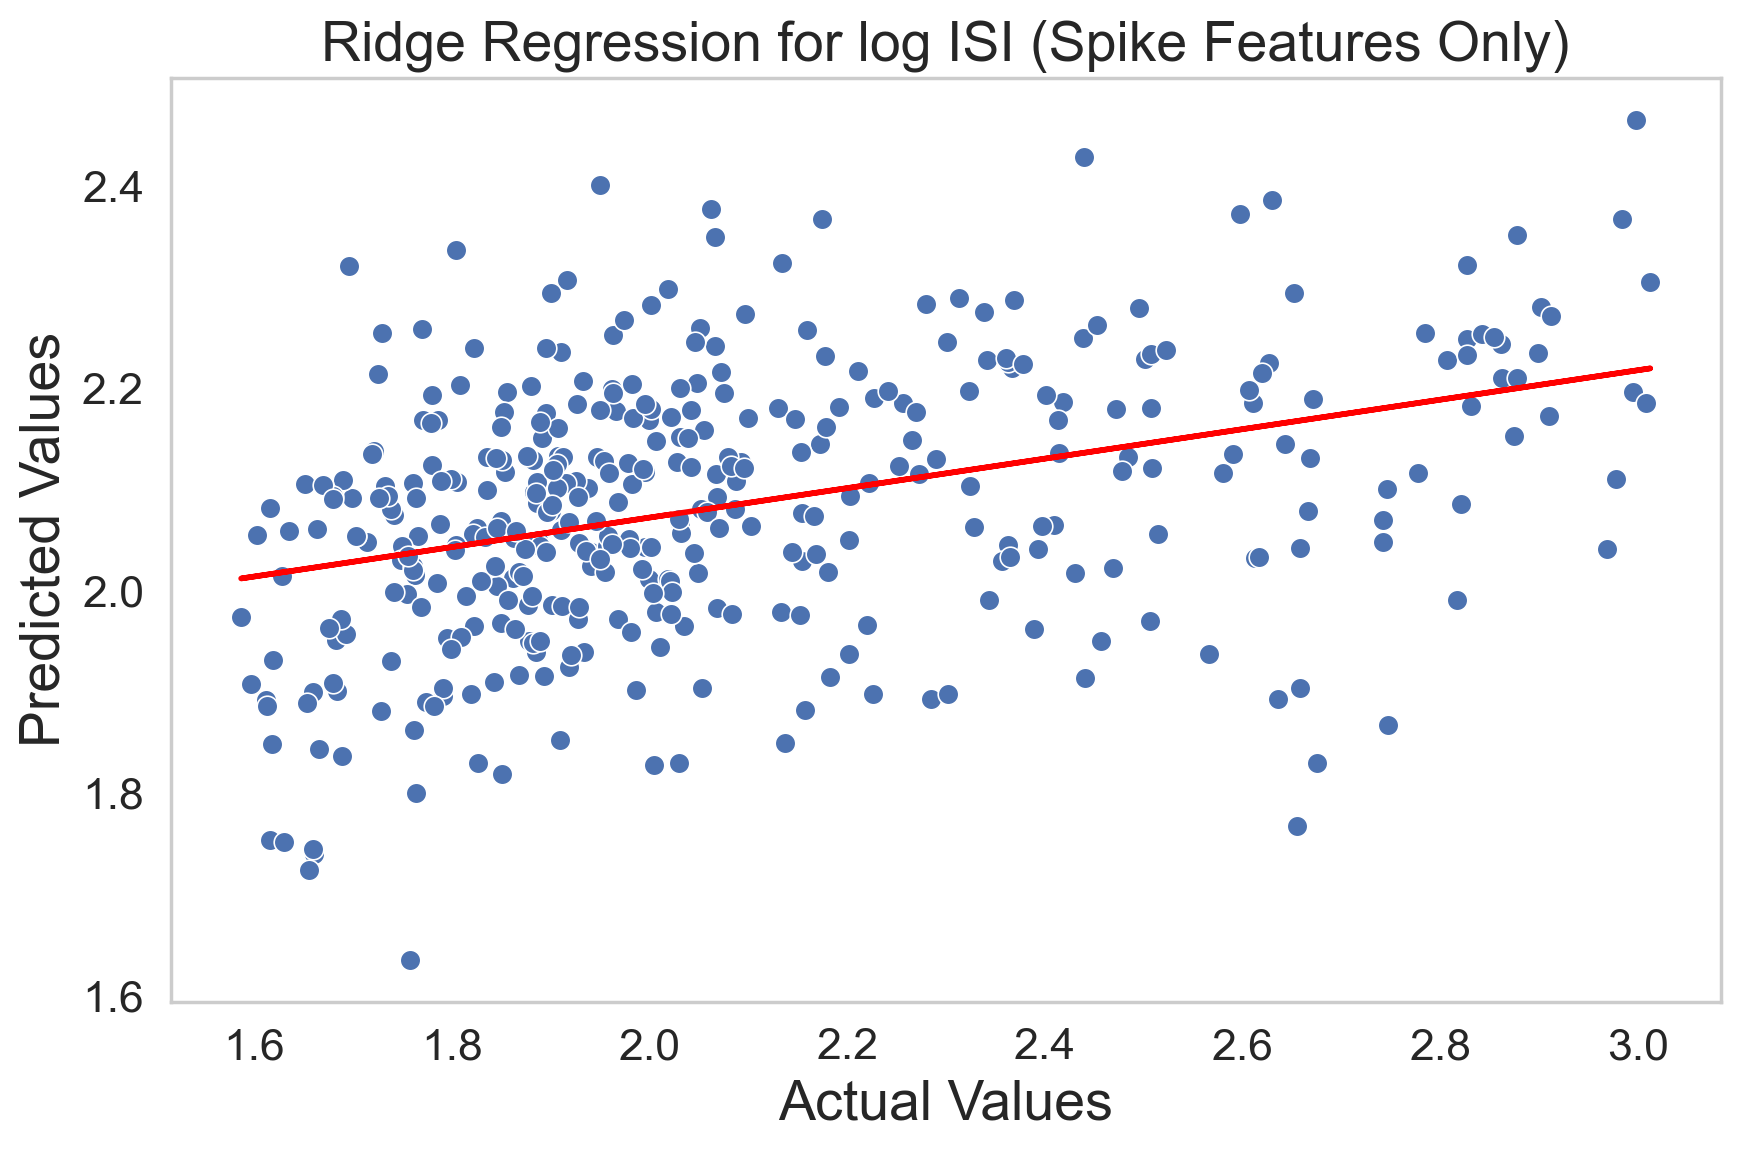

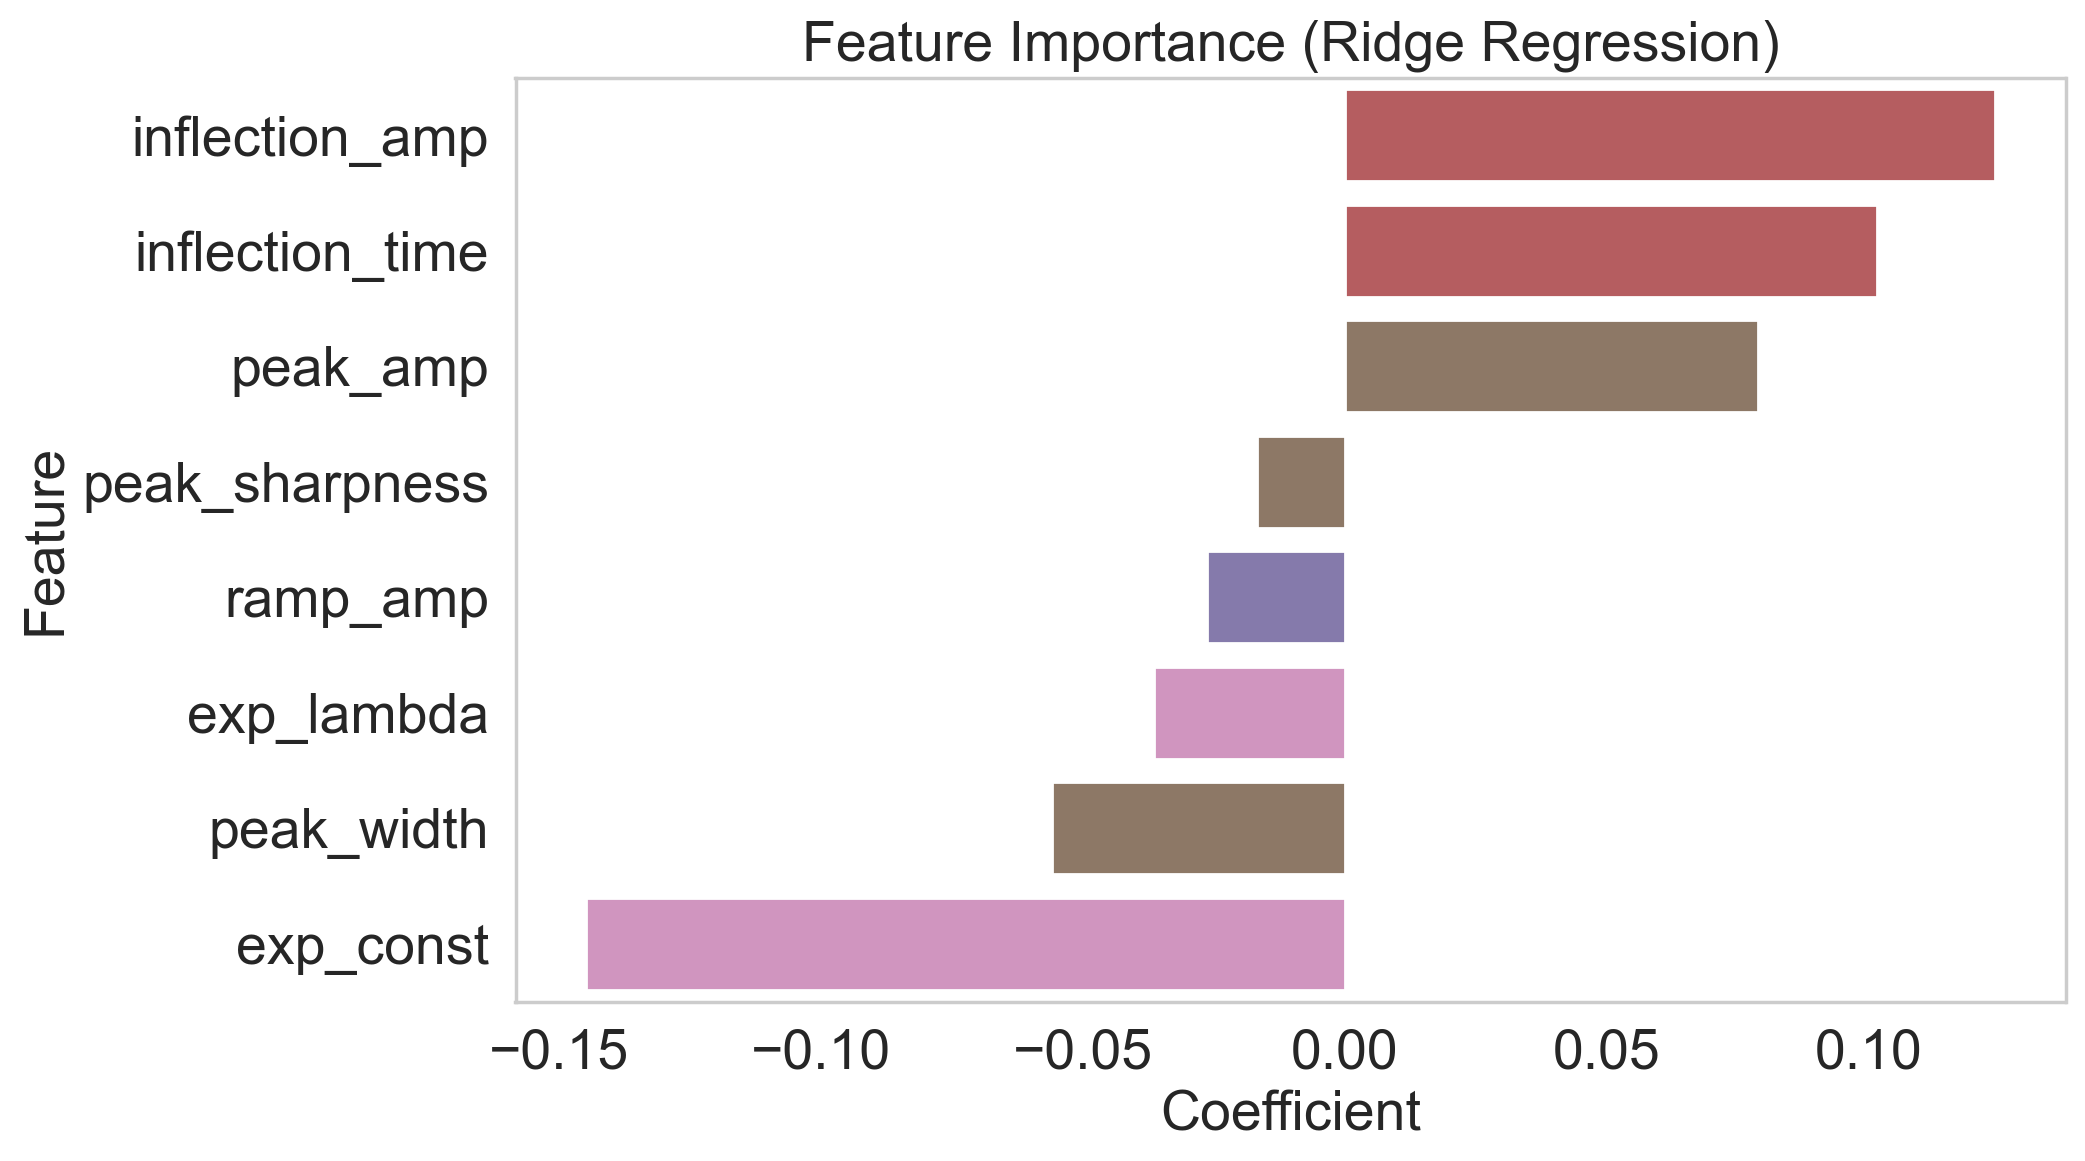


Significant Features (p < 0.05):
           Feature  Coefficient  CI Lower  CI Upper        p-value
2   inflection_amp     0.124196  0.048322  0.190326   0.000000e+00
1  inflection_time     0.101598  0.034550  0.170643   0.000000e+00
3         peak_amp     0.078977  0.025665  0.128264   0.000000e+00
5   peak_sharpness    -0.016662 -0.091376  0.058036   5.218641e-41
0         ramp_amp    -0.026205 -0.056665  0.004125  8.200747e-293
6       exp_lambda    -0.036315 -0.109072  0.035319  4.989705e-157
4       peak_width    -0.055814 -0.129014  0.022722  9.128397e-255
7        exp_const    -0.144832 -0.193735 -0.096358   0.000000e+00


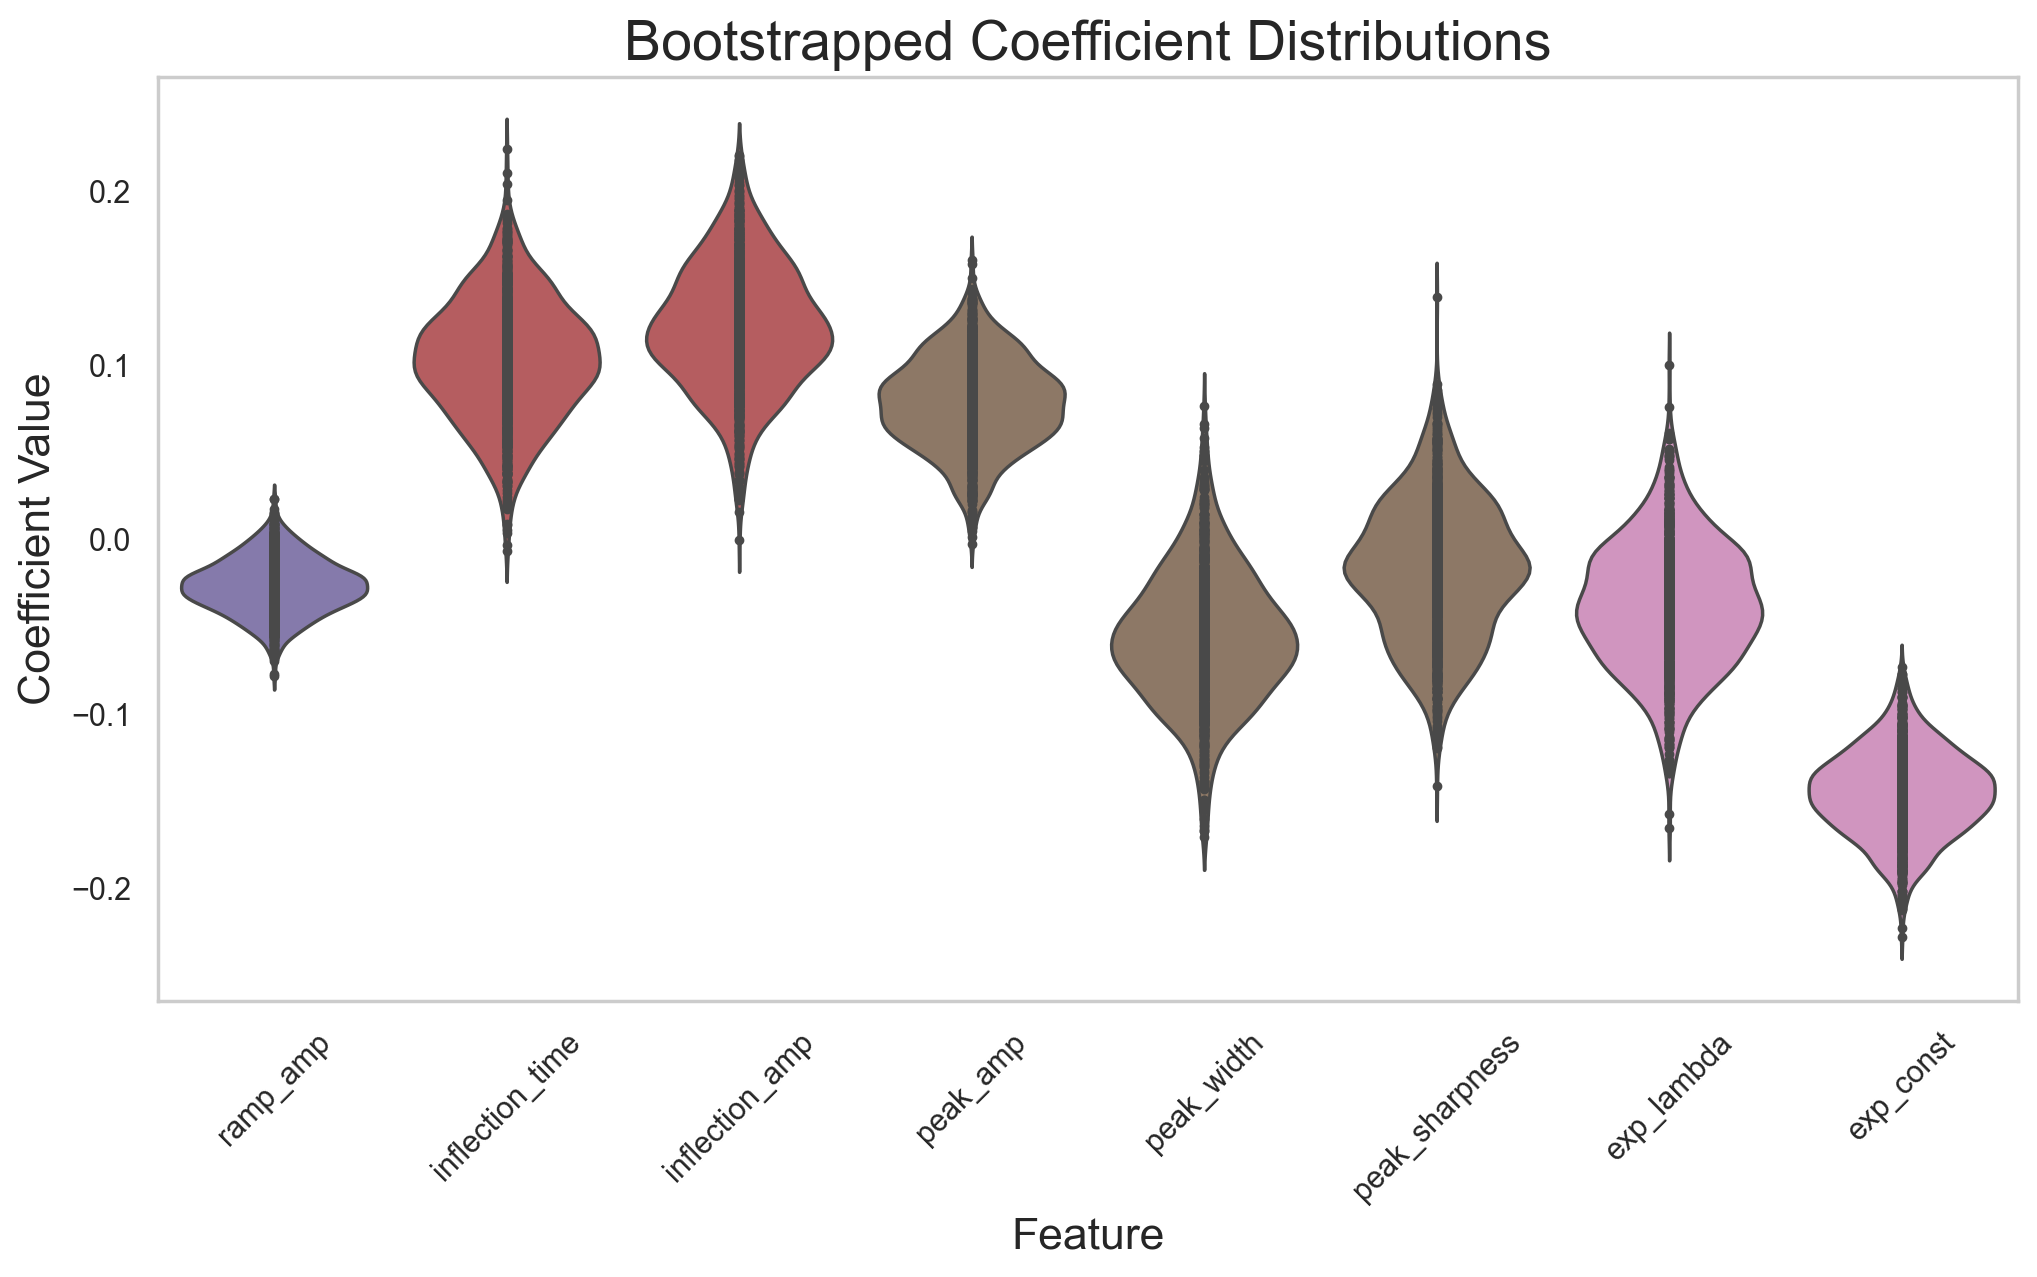

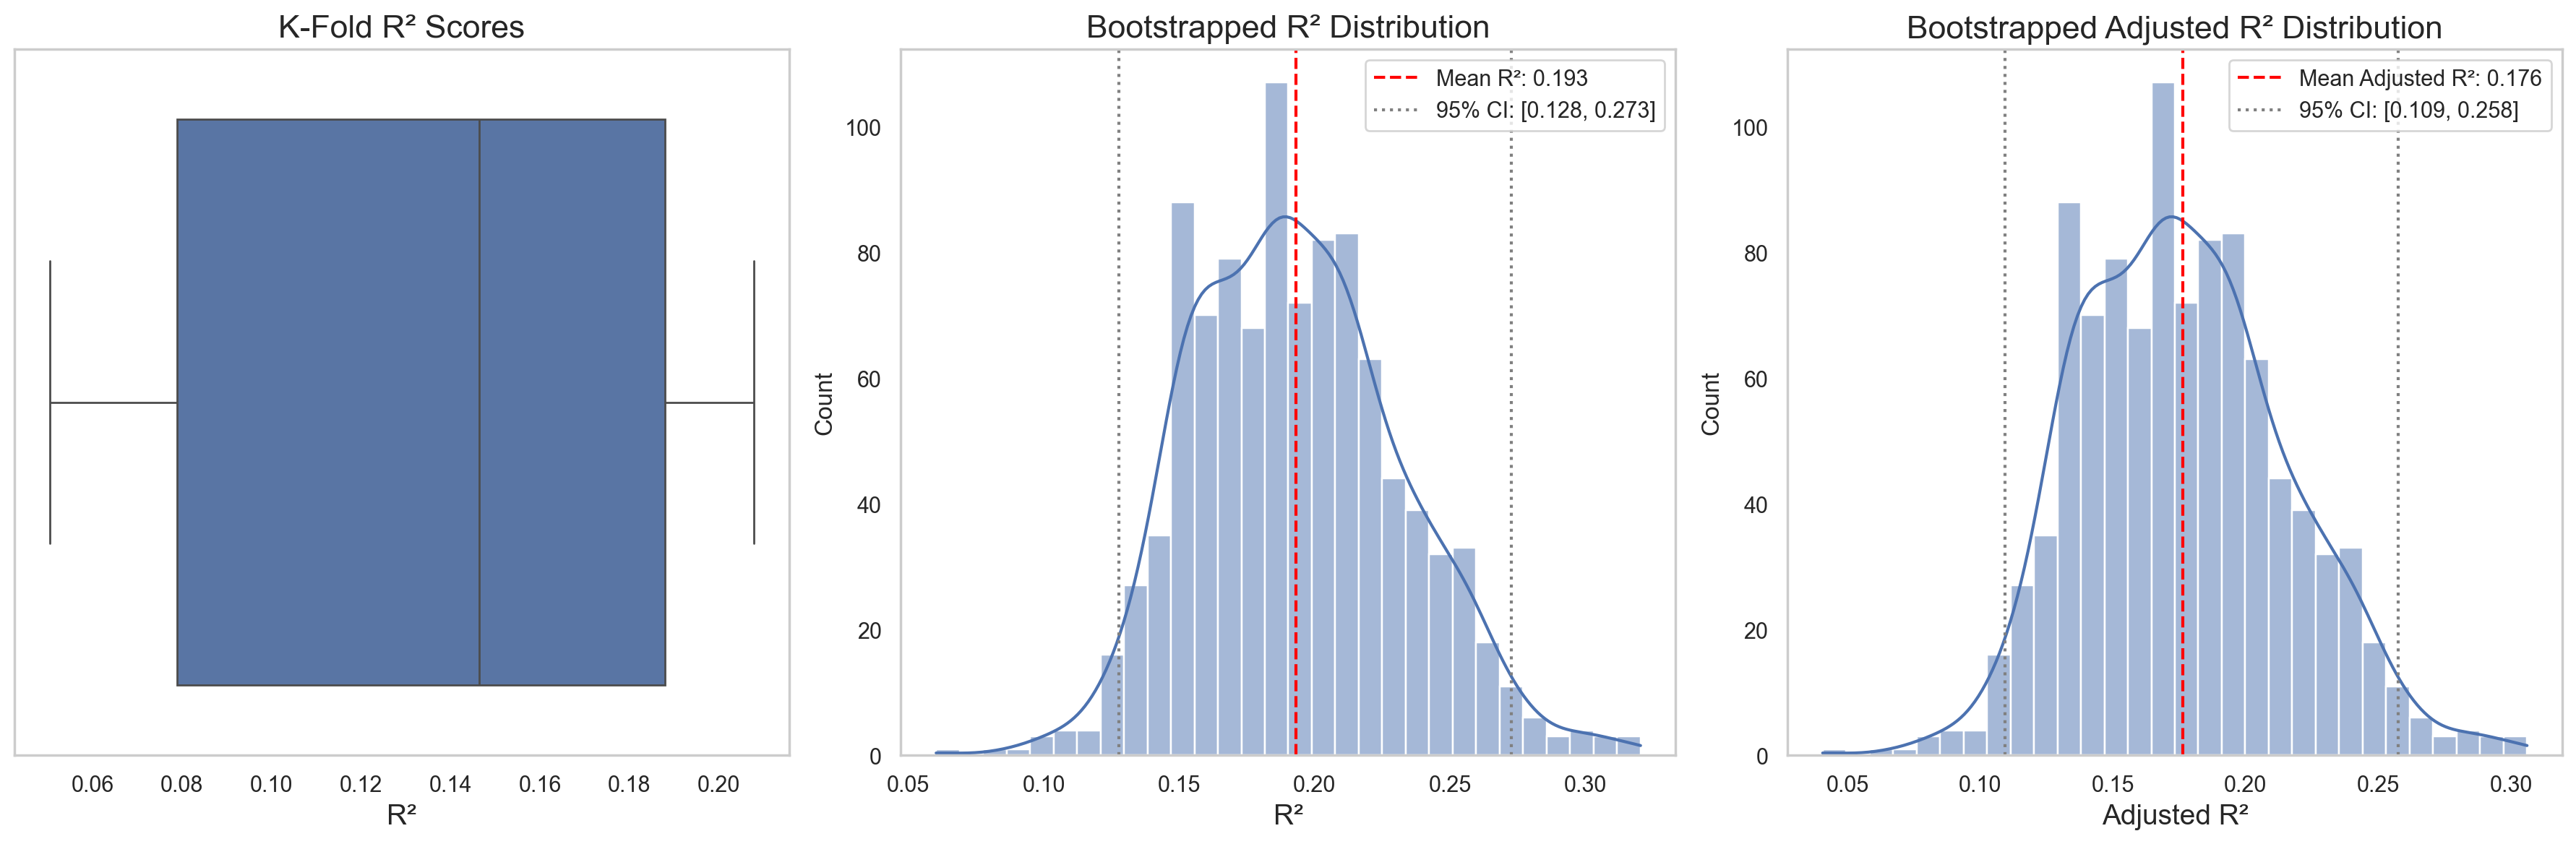


Mean Adjusted R-squared (Bootstrapped): 0.176
95% CI for Adjusted R-squared: [0.10945137 0.25750102]


In [51]:
# Plot the Results
plot_ridge_results(y_log_isi, ridge_results_spike_only, title="Ridge Regression for log ISI (Spike Features Only)")

### 8b. Model 2 — Spike + Stimulus Features

In [ ]:
pickle_path = os.path.join(PICKLE_DIR, 'ridge_results_spike_stim.pkl')
if not FORCE_RERUN and os.path.exists(pickle_path):
    with open(pickle_path, 'rb') as file:
        ridge_results_spike_stim = pickle.load(file)
    print('Loaded ridge_results_spike_stim from pickle.')
else:
    X_spike_stim = df_pink_filtered.drop(columns=['log_isi'])
    ridge_results_spike_stim = run_ridge_regression_kfold(X_spike_stim, y_log_isi)
    with open(pickle_path, 'wb') as file:
        pickle.dump(ridge_results_spike_stim, file)
    print('Saved ridge_results_spike_stim to pickle.')

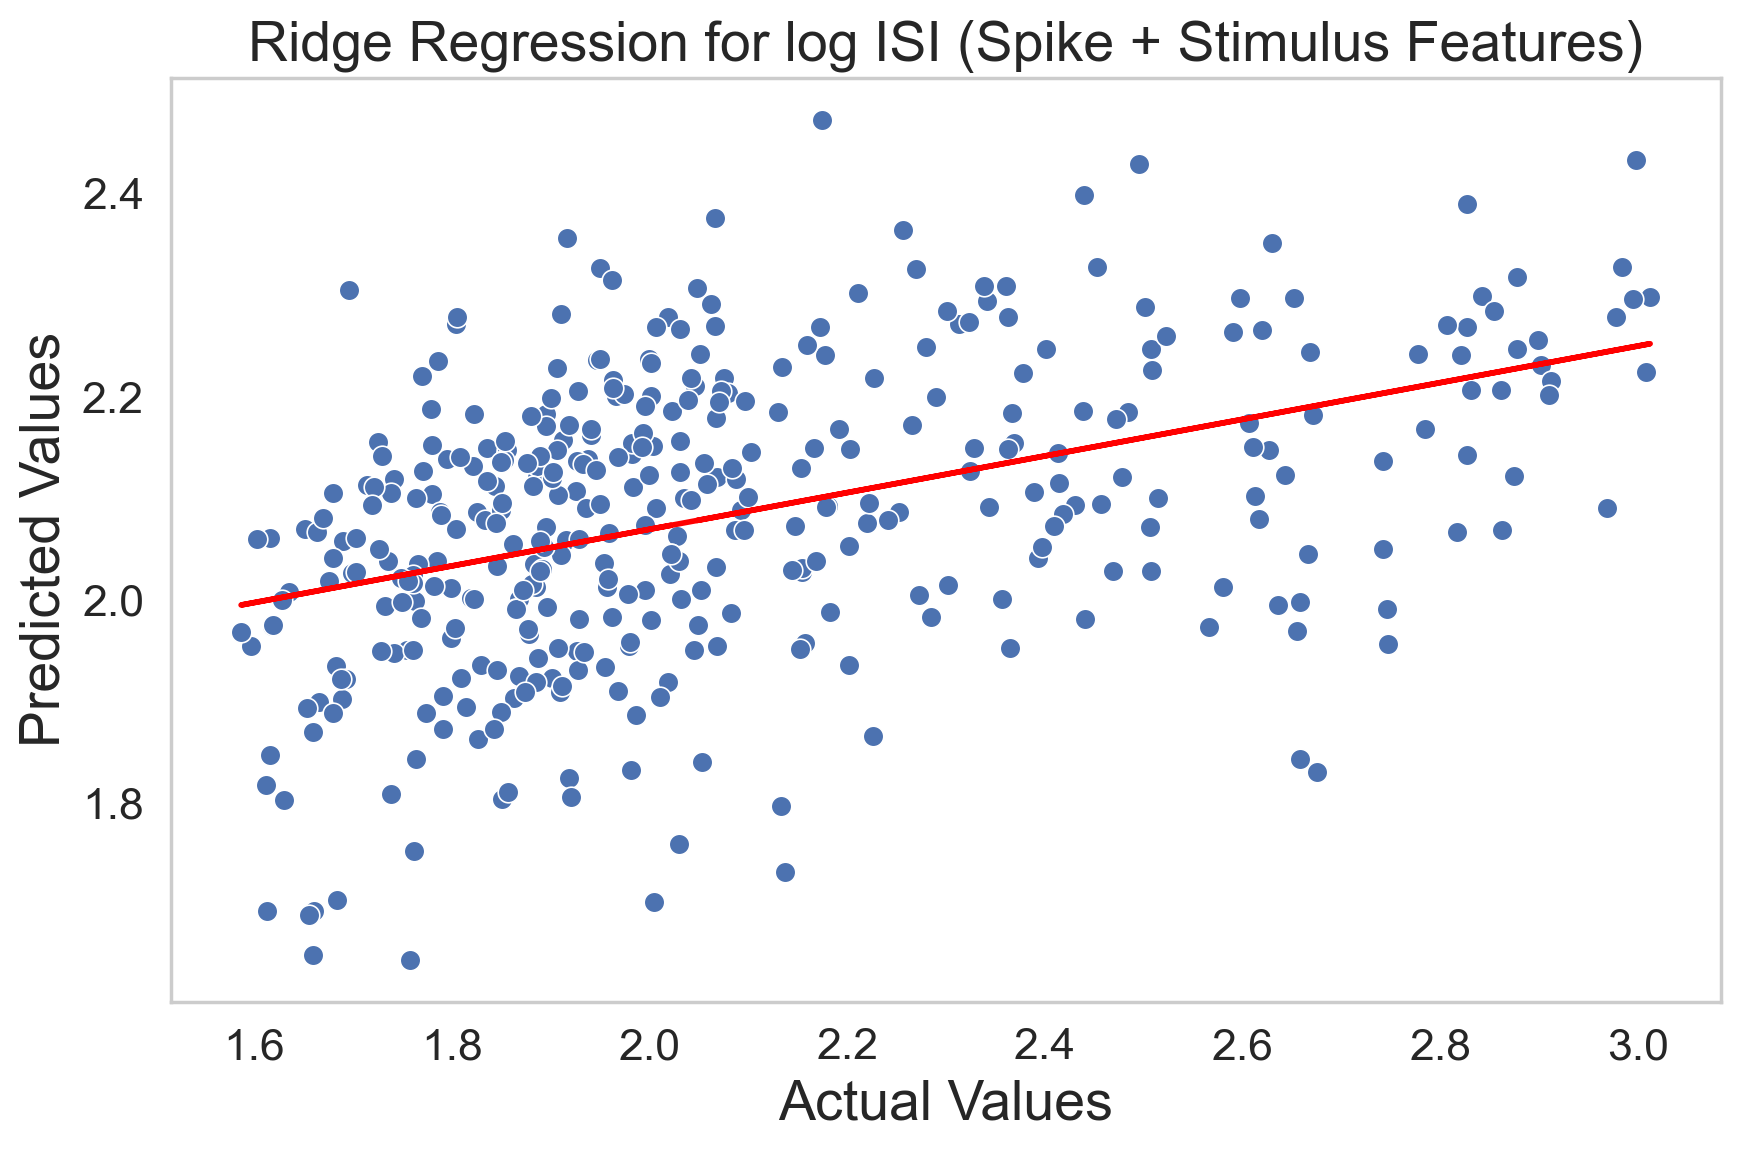

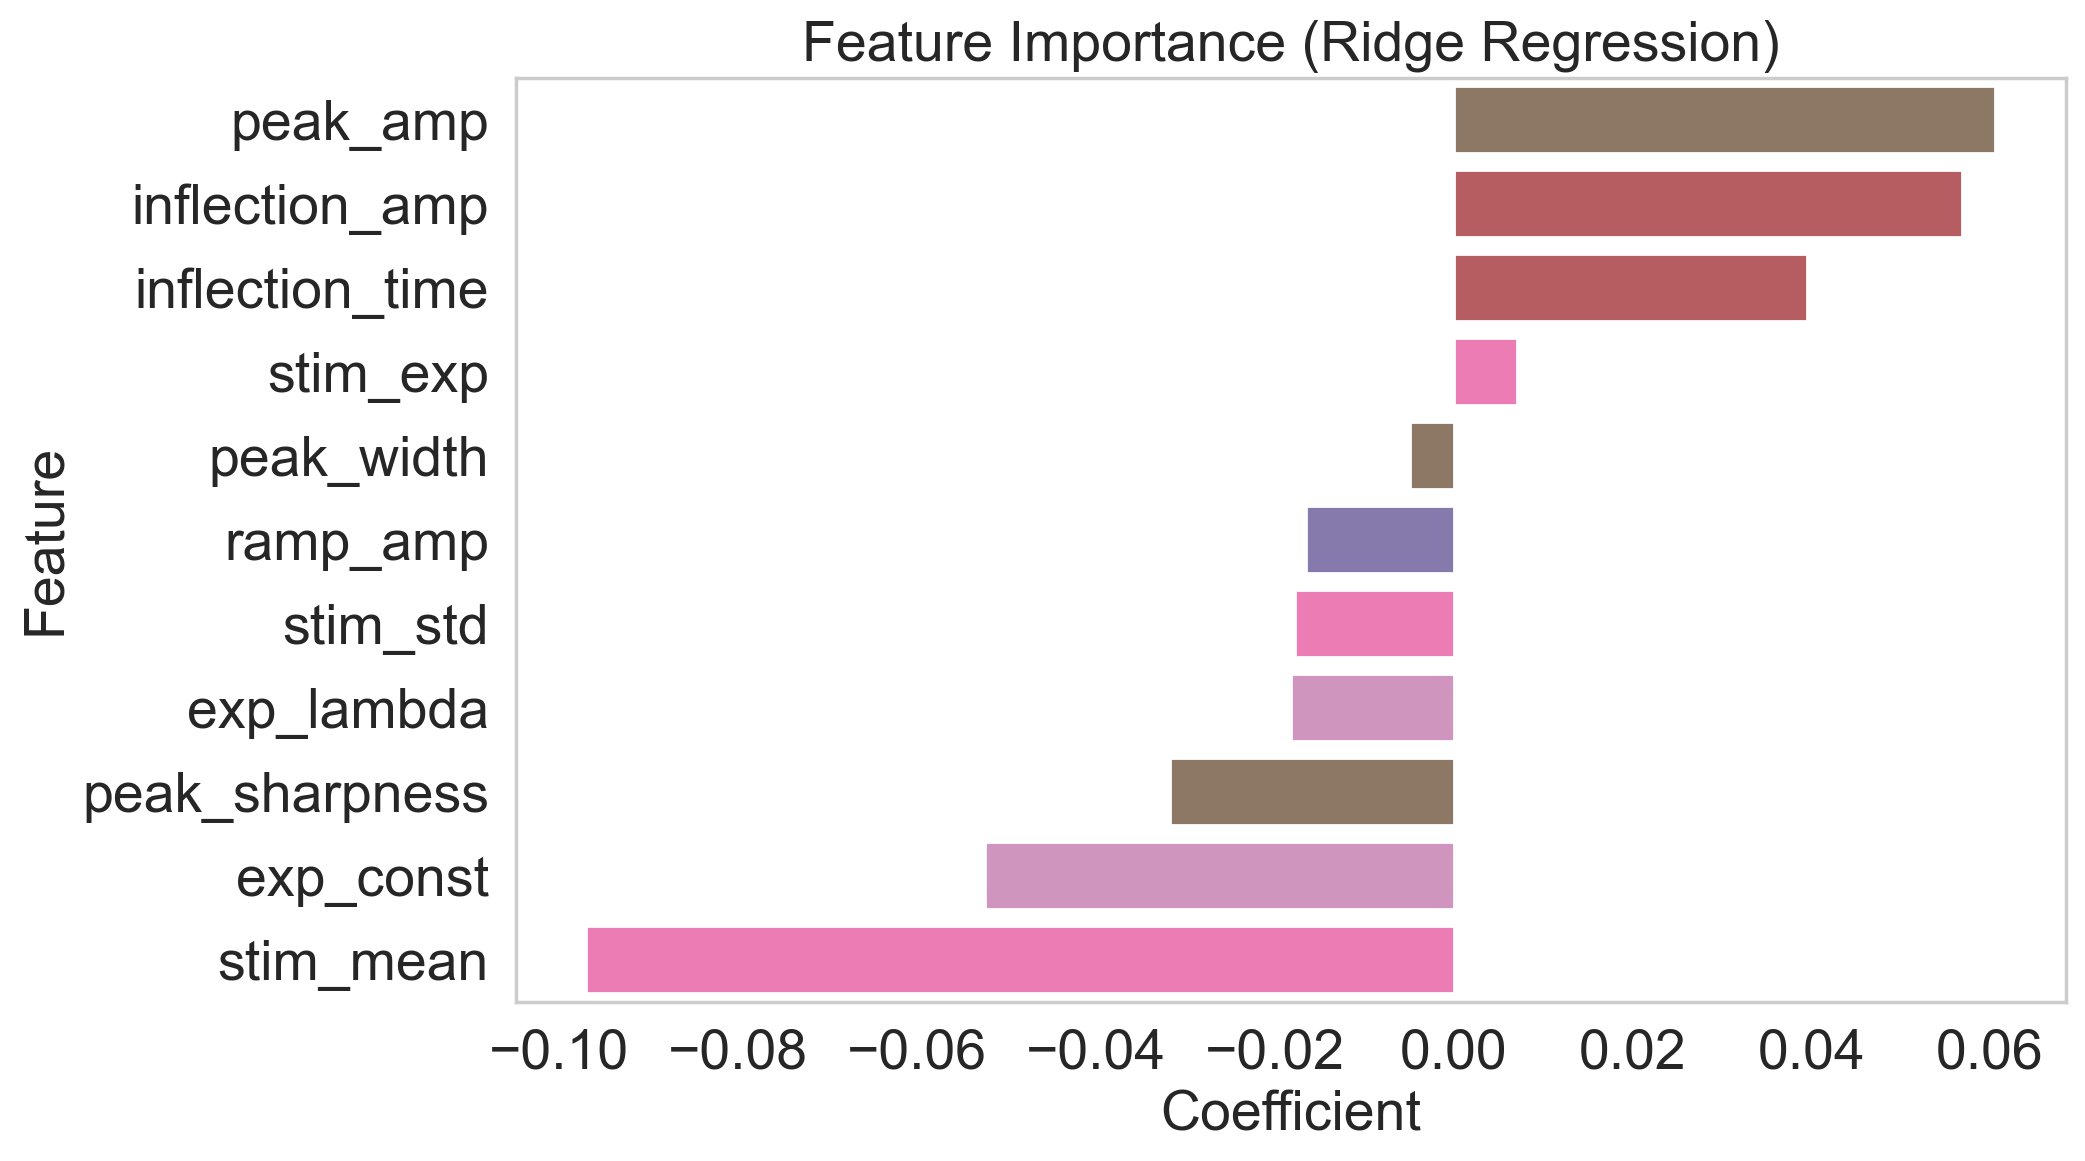


Significant Features (p < 0.05):
            Feature  Coefficient  CI Lower  CI Upper        p-value
6          peak_amp     0.060552  0.017464  0.100892   0.000000e+00
5    inflection_amp     0.056860  0.017343  0.098489   0.000000e+00
4   inflection_time     0.039510  0.003642  0.078388   0.000000e+00
0          stim_exp     0.007129 -0.025669  0.041085   2.299617e-27
7        peak_width    -0.004912 -0.035889  0.026140   4.515562e-18
3          ramp_amp    -0.016487 -0.045227  0.011221  1.932474e-184
2          stim_std    -0.017782 -0.052448  0.019183  1.724110e-148
9        exp_lambda    -0.018149 -0.051628  0.016683  1.753020e-153
8    peak_sharpness    -0.031733 -0.067797  0.007551  1.003514e-285
10        exp_const    -0.052390 -0.098019 -0.008697   0.000000e+00
1         stim_mean    -0.097022 -0.126480 -0.066803   0.000000e+00


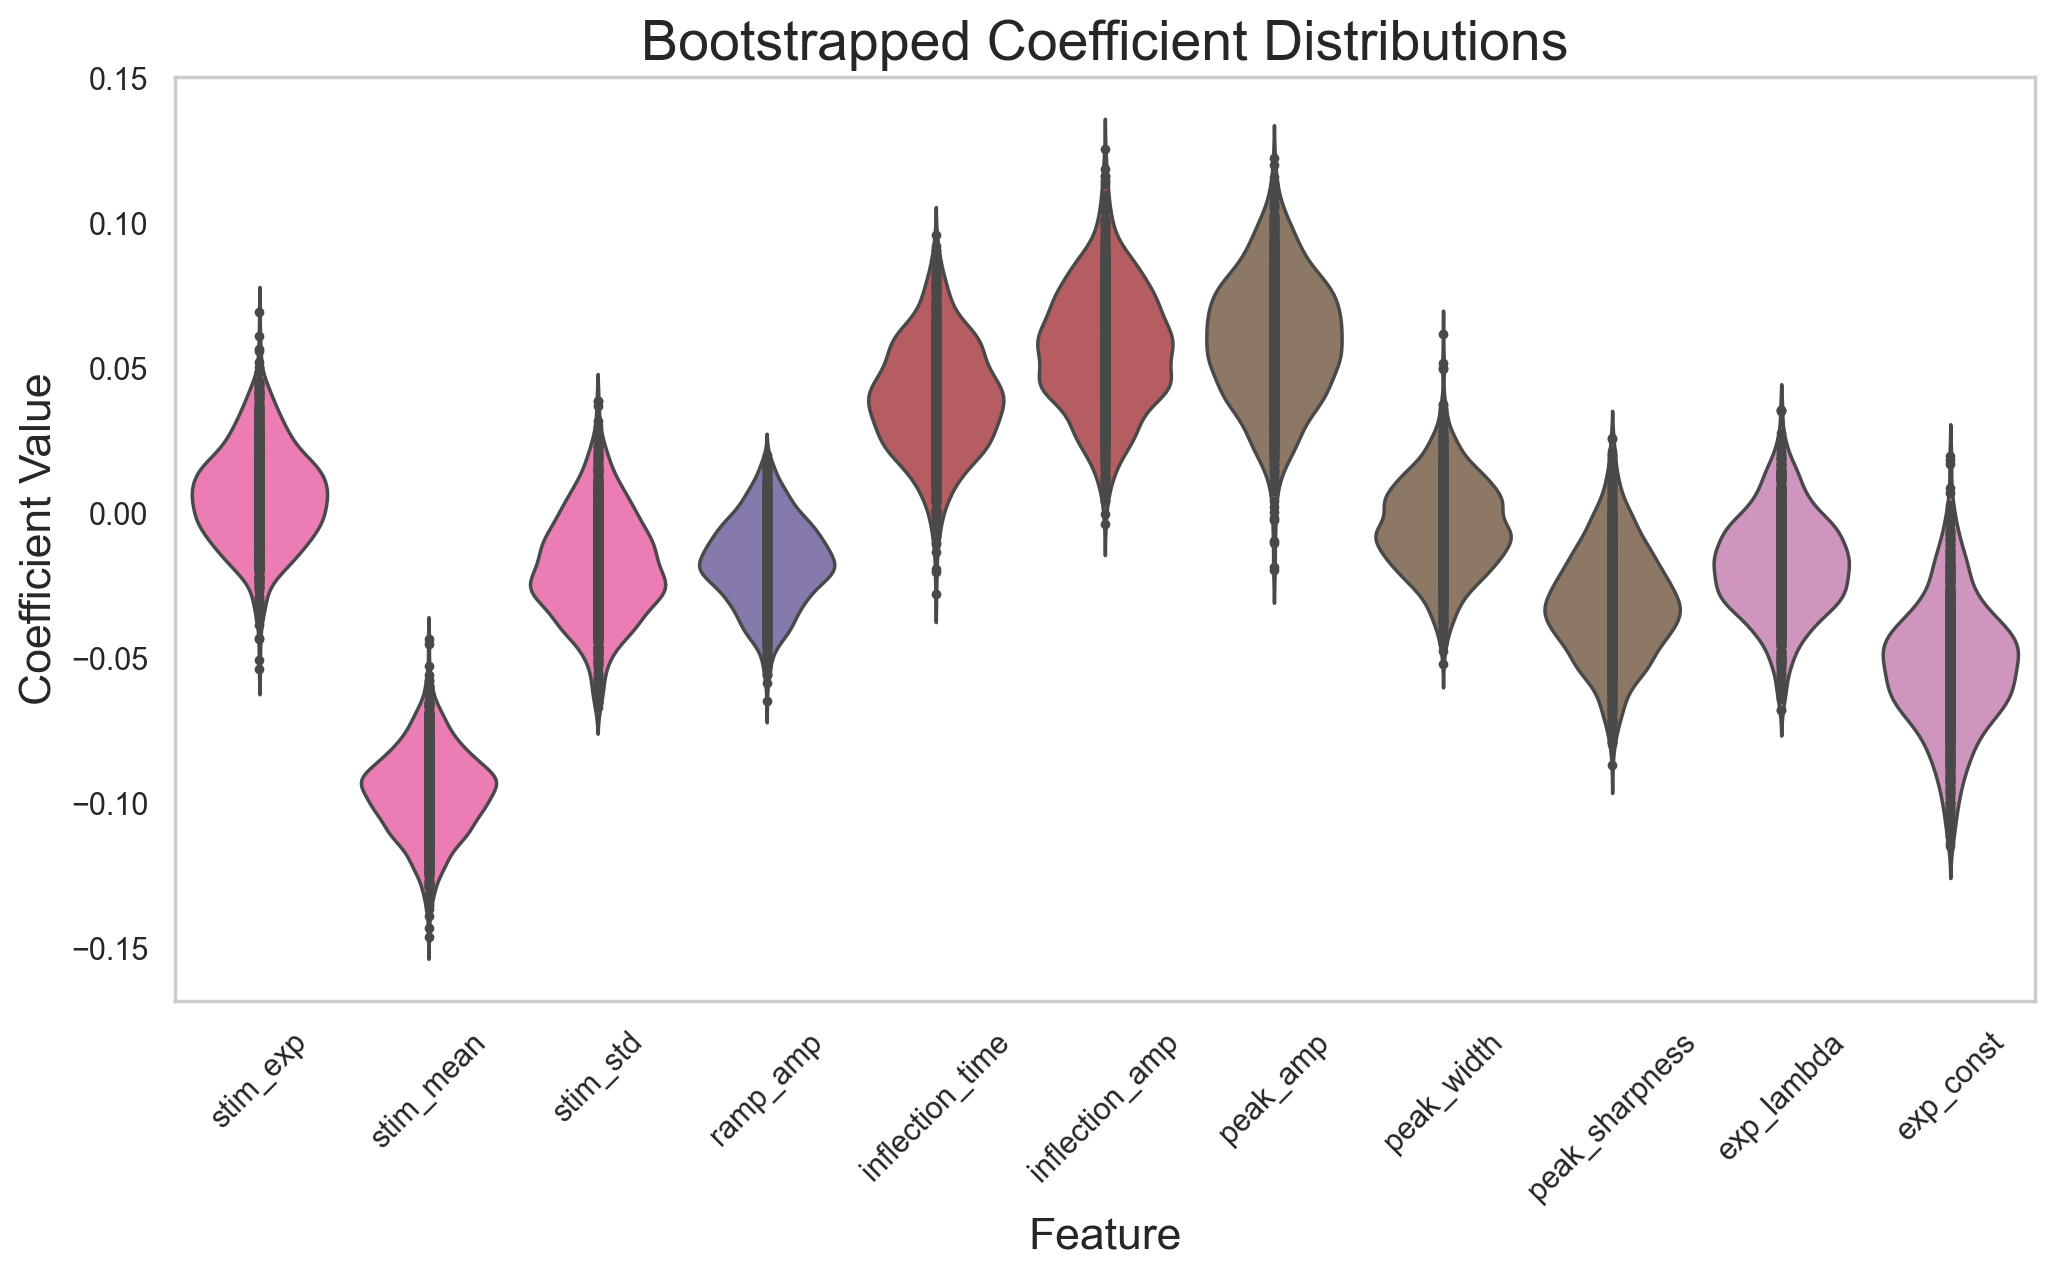

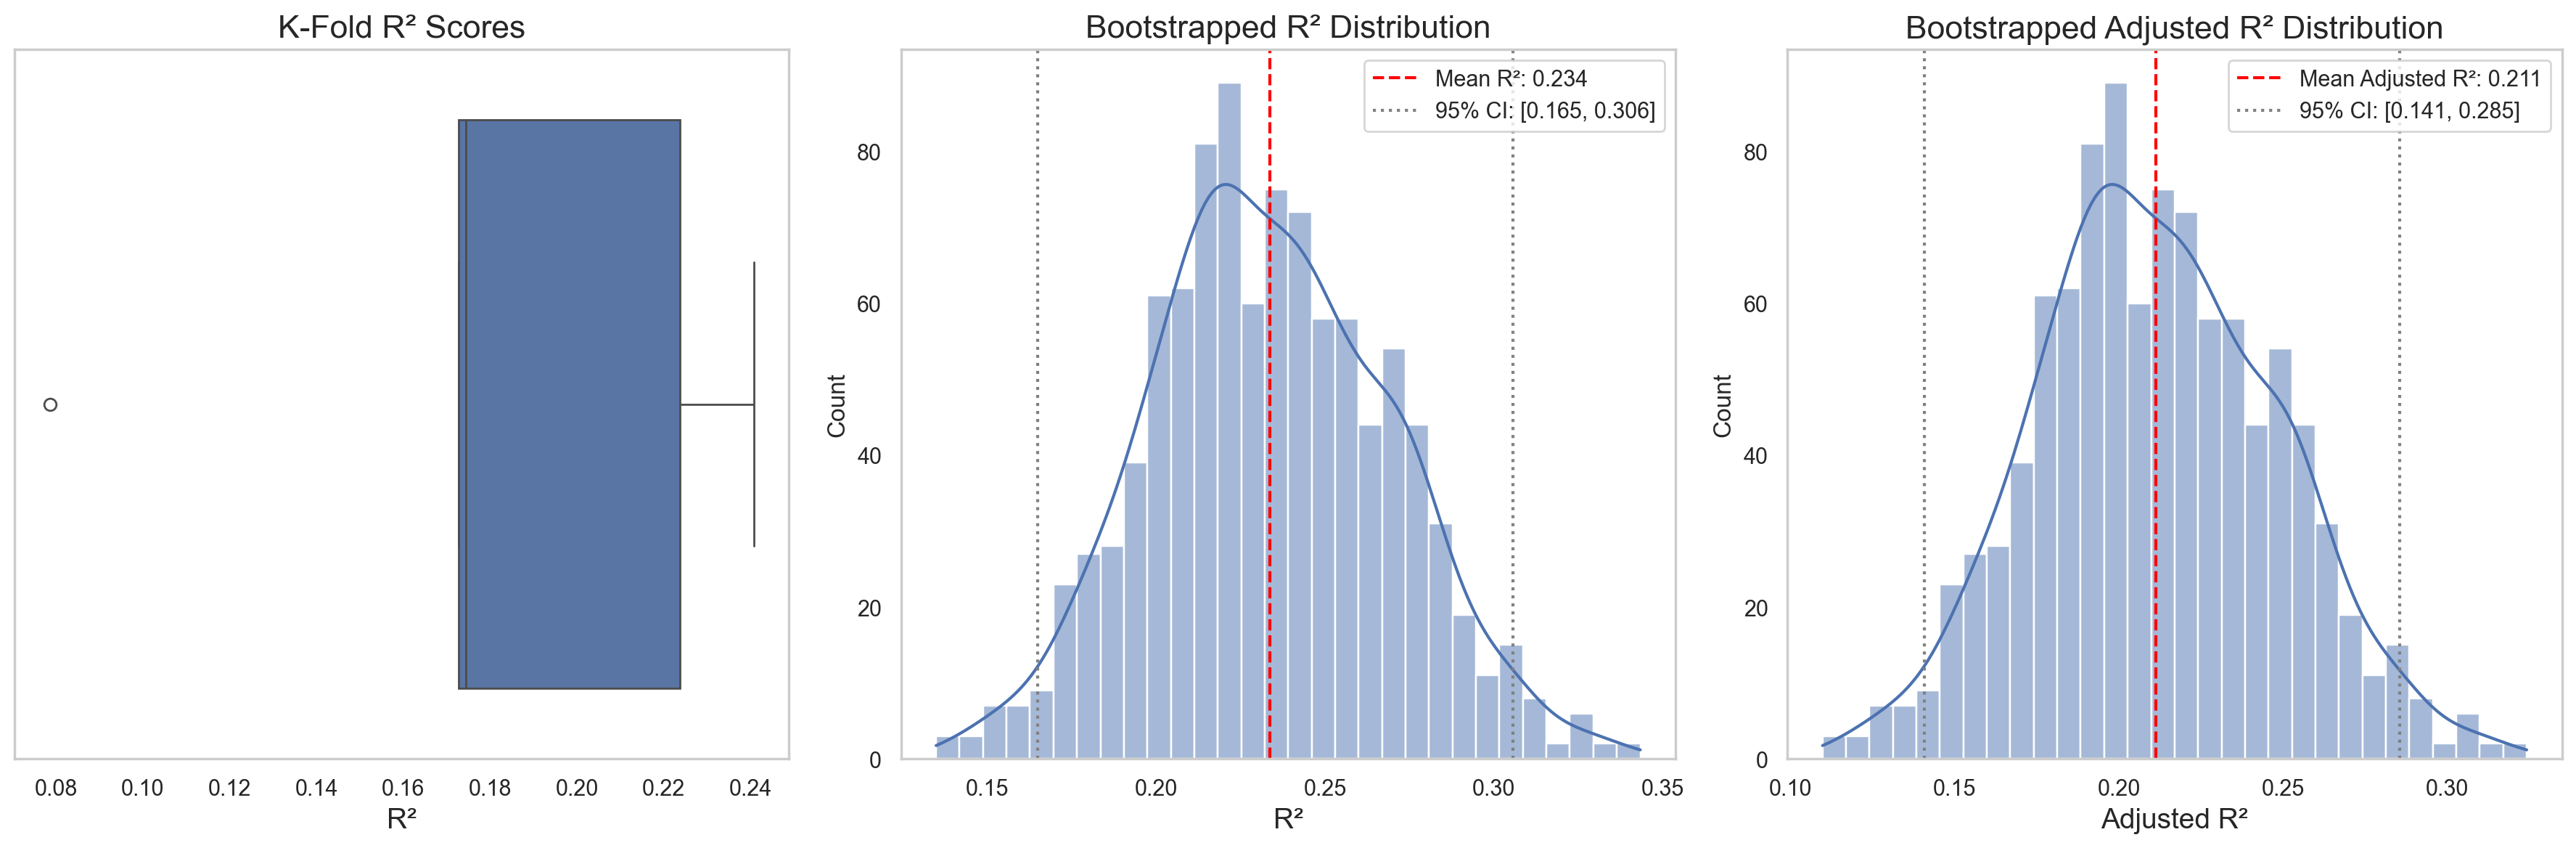


Mean Adjusted R-squared (Bootstrapped): 0.211
95% CI for Adjusted R-squared: [0.14071717 0.28548356]


In [53]:
# Plot the Results
plot_ridge_results(y_log_isi, ridge_results_spike_stim, title="Ridge Regression for log ISI (Spike + Stimulus Features)")

### 8c. Model 3 — Stimulus Features Only

In [ ]:
pickle_path = os.path.join(PICKLE_DIR, 'ridge_results_stim_only.pkl')
if not FORCE_RERUN and os.path.exists(pickle_path):
    with open(pickle_path, 'rb') as file:
        ridge_results_stim_only = pickle.load(file)
    print('Loaded ridge_results_stim_only from pickle.')
else:
    X_stim_only = df_pink_filtered[['stim_exp', 'stim_mean', 'stim_std']]
    ridge_results_stim_only = run_ridge_regression_kfold(X_stim_only, y_log_isi)
    with open(pickle_path, 'wb') as file:
        pickle.dump(ridge_results_stim_only, file)
    print('Saved ridge_results_stim_only to pickle.')

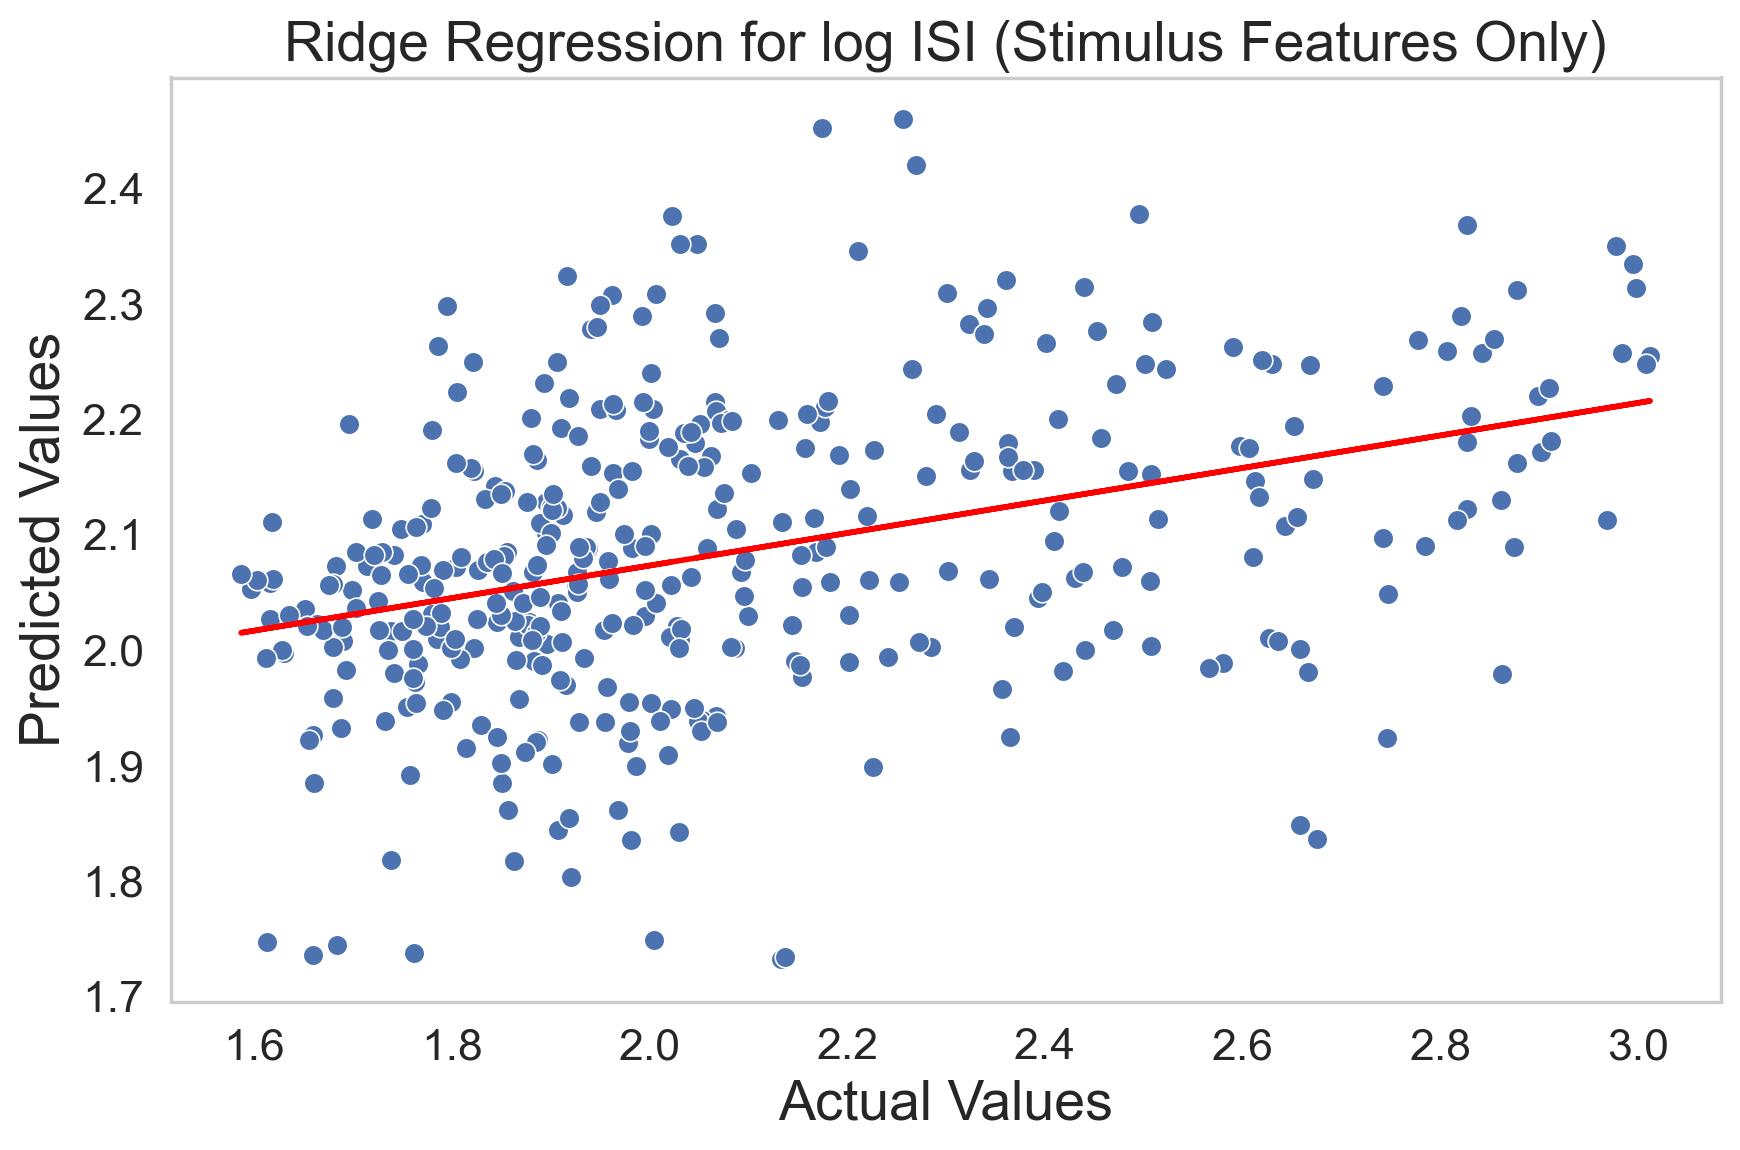

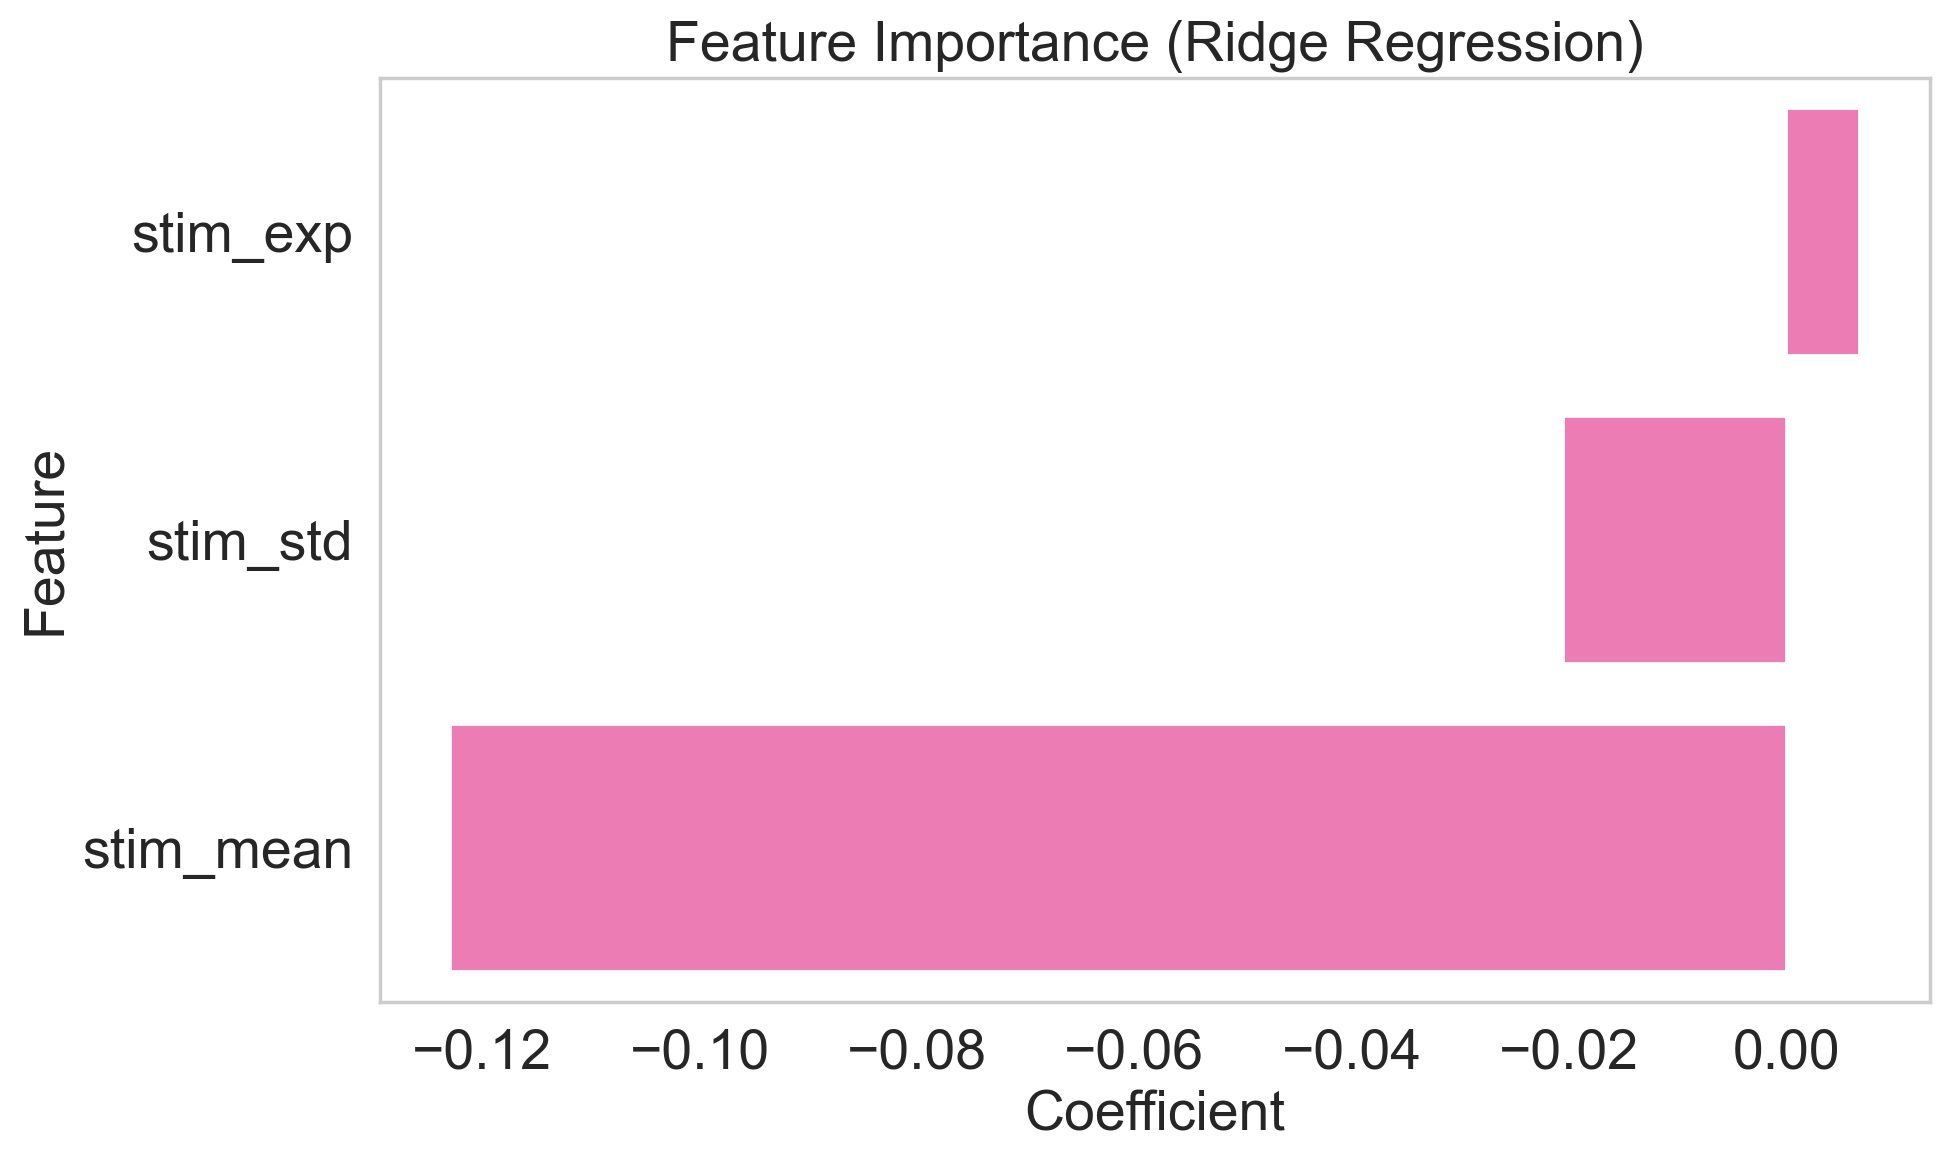


Significant Features (p < 0.05):
     Feature  Coefficient  CI Lower  CI Upper        p-value
0   stim_exp     0.006739 -0.032138  0.043992   1.230478e-25
2   stim_std    -0.020524 -0.058931  0.017928  8.329933e-171
1  stim_mean    -0.122930 -0.152465 -0.092914   0.000000e+00


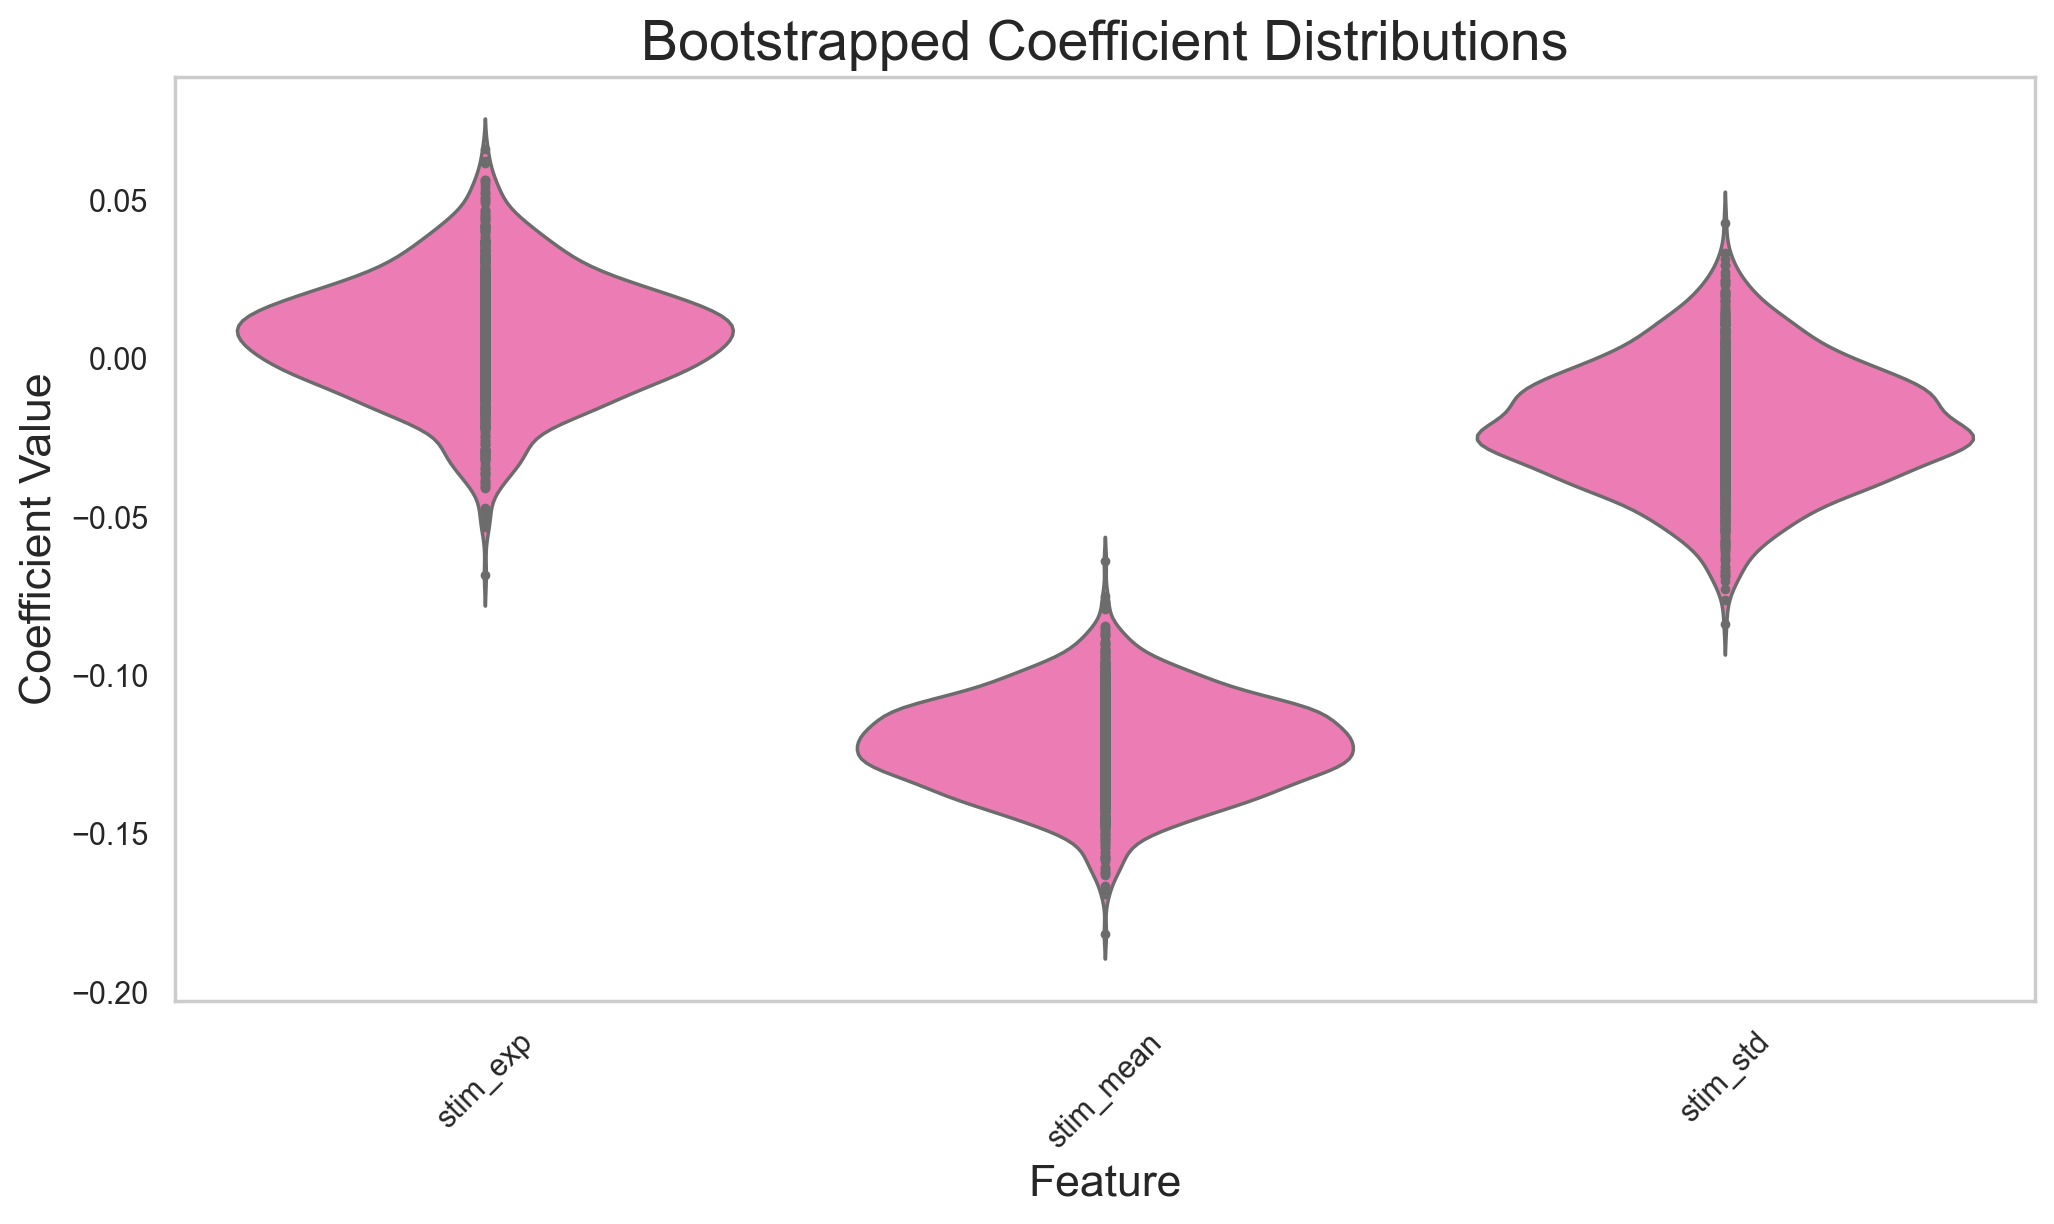

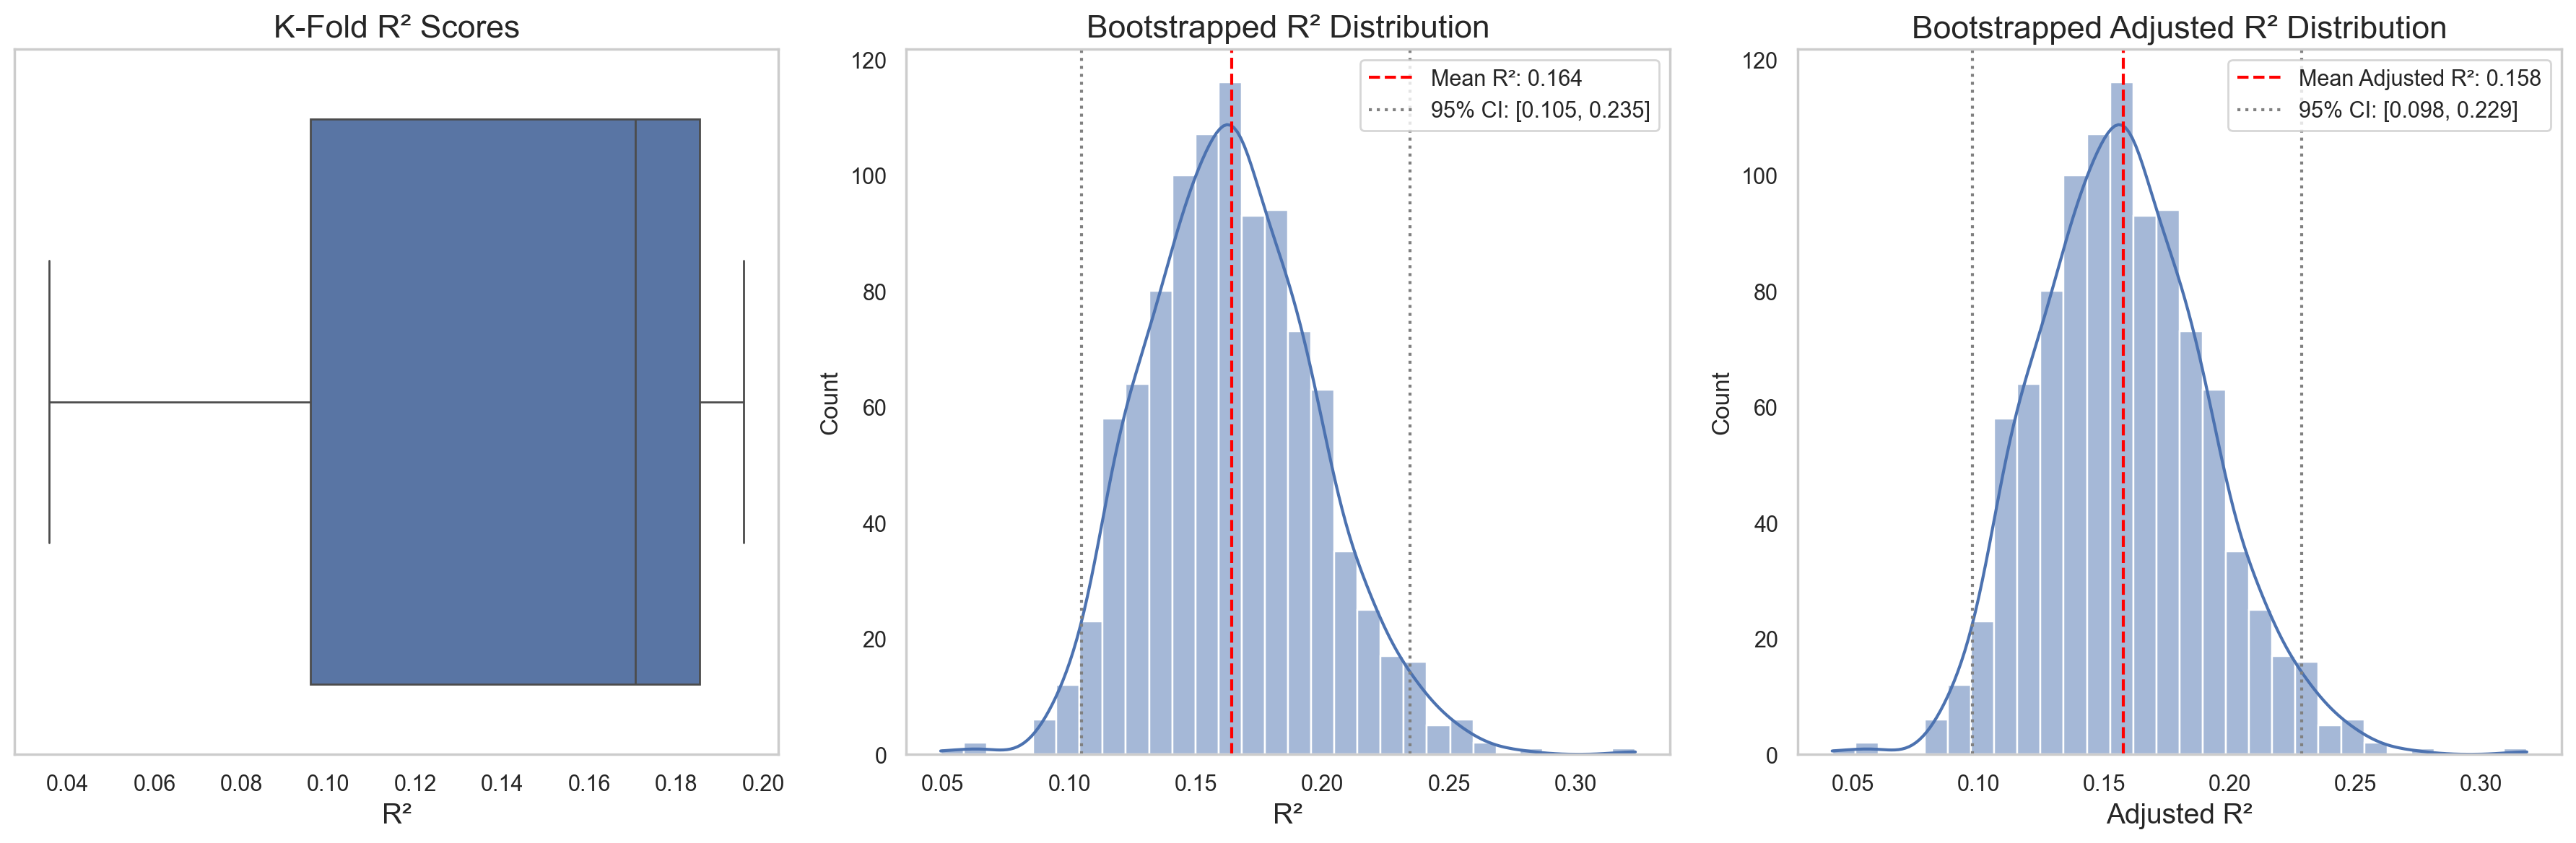


Mean Adjusted R-squared (Bootstrapped): 0.158
95% CI for Adjusted R-squared: [0.09777295 0.22877994]
FDR (BH, q=0.05): 3/3 raw p<0.05 → 3/3 after correction
  M1_spike_only    R²=0.193  p_perm=0.001  p_fdr=0.001 *
  M2_spike_stim    R²=0.234  p_perm=0.001  p_fdr=0.001 *
  M3_stim_only     R²=0.164  p_perm=0.001  p_fdr=0.001 *


{'M1_spike_only': {'y_pred_cv': array([2.20554054, 2.36768103, 2.46579448, 2.36791477, 2.1035475 ,
         2.28077753, 2.28945628, 2.23545712, 2.21984042, 2.03810825,
         2.08579372, 2.27940466, 2.24928759, 2.22933208, 2.24344536,
         1.97656033, 2.23977237, 2.25452422, 2.34942801, 2.19073612,
         2.40082533, 2.15282588, 2.32431722, 2.06648981, 2.18021341,
         2.13227945, 2.12799638, 2.09221067, 2.11668713, 2.37191475,
         2.25326673, 2.10841346, 2.12892614, 2.21064727, 2.12696138,
         2.2985066 , 1.89758494, 1.95015653, 2.19972602, 2.18990179,
         2.13241943, 2.01232378, 1.89762504, 2.29464573, 2.23385534,
         2.17543393, 1.74019806, 2.0914572 , 1.84381891, 1.90015905,
         1.81883499, 2.04364743, 2.07900612, 2.06312064, 2.20397787,
         2.24176795, 2.07724196, 1.98608465, 2.07500765, 2.01558987,
         1.97245602, 2.0245409 , 2.01783999, 2.10183715, 2.10874101,
         2.00466996, 2.08056078, 2.04675518, 2.08111782, 2.10945851,
    

In [55]:
# Plot the Results
plot_ridge_results(y_log_isi, ridge_results_stim_only, title="Ridge Regression for log ISI (Stimulus Features Only)")

# FDR correction across ISI models (M1 / M2 / M3)
apply_fdr_pvc6({'M1_spike_only': ridge_results_spike_only,
                'M2_spike_stim': ridge_results_spike_stim,
                'M3_stim_only':  ridge_results_stim_only})

### 8d. Model Comparison

Side-by-side R² with bootstrapped CIs for all three models. If the waveform-only model approaches the combined model's performance, it means spike shape is already capturing most of the stimulus-relevant variance — consistent with waveform features being a faithful readout of instantaneous input drive.

In [56]:
#Set up dataframes for plotting 

feature_importance_spike_only_df = pd.DataFrame({'Feature': ridge_results_spike_only['feature_names'], 'Coefficient': ridge_results_spike_only['coefficients']})
feature_importance_spike_stim_df = pd.DataFrame({'Feature': ridge_results_spike_stim['feature_names'], 'Coefficient': ridge_results_spike_stim['coefficients']})
feature_importance_stim_only_df = pd.DataFrame({'Feature': ridge_results_stim_only['feature_names'], 'Coefficient': ridge_results_stim_only['coefficients']})

feature_importance_spike_only_df['Model'] = 'No stim features'
feature_importance_spike_stim_df['Model'] = 'With stim features (Combined)'
feature_importance_stim_only_df['Model'] = 'Only stim features'

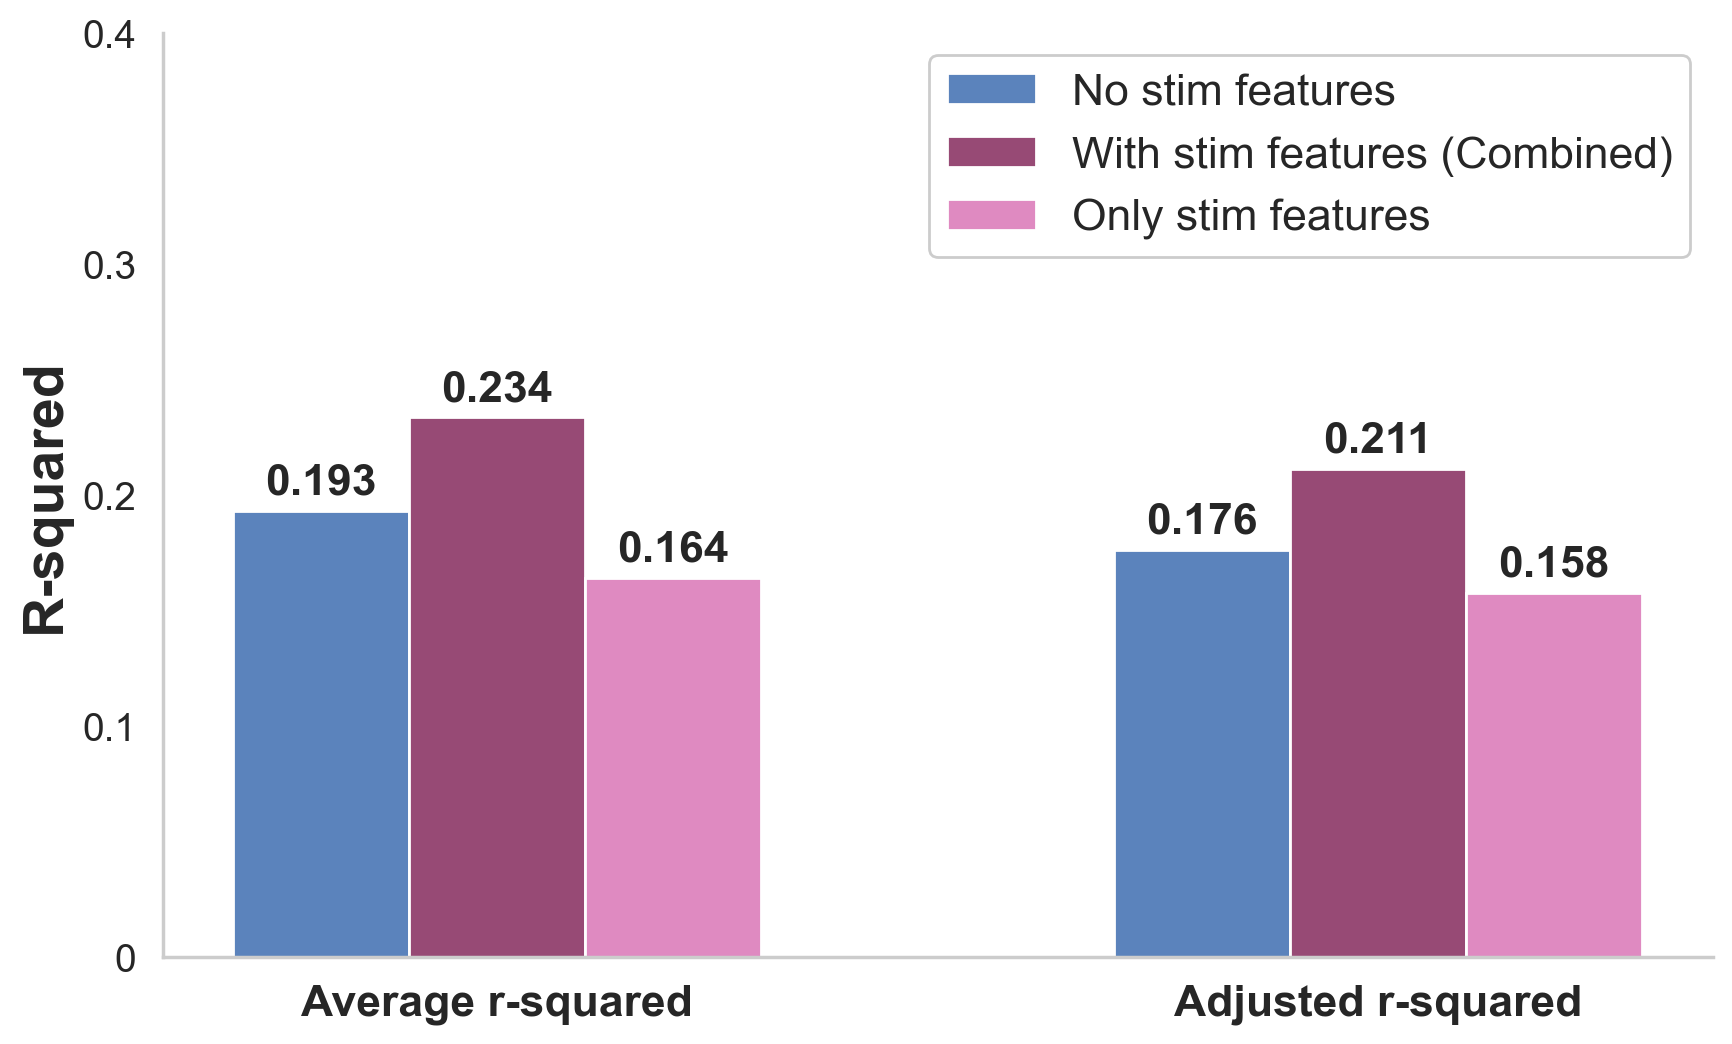

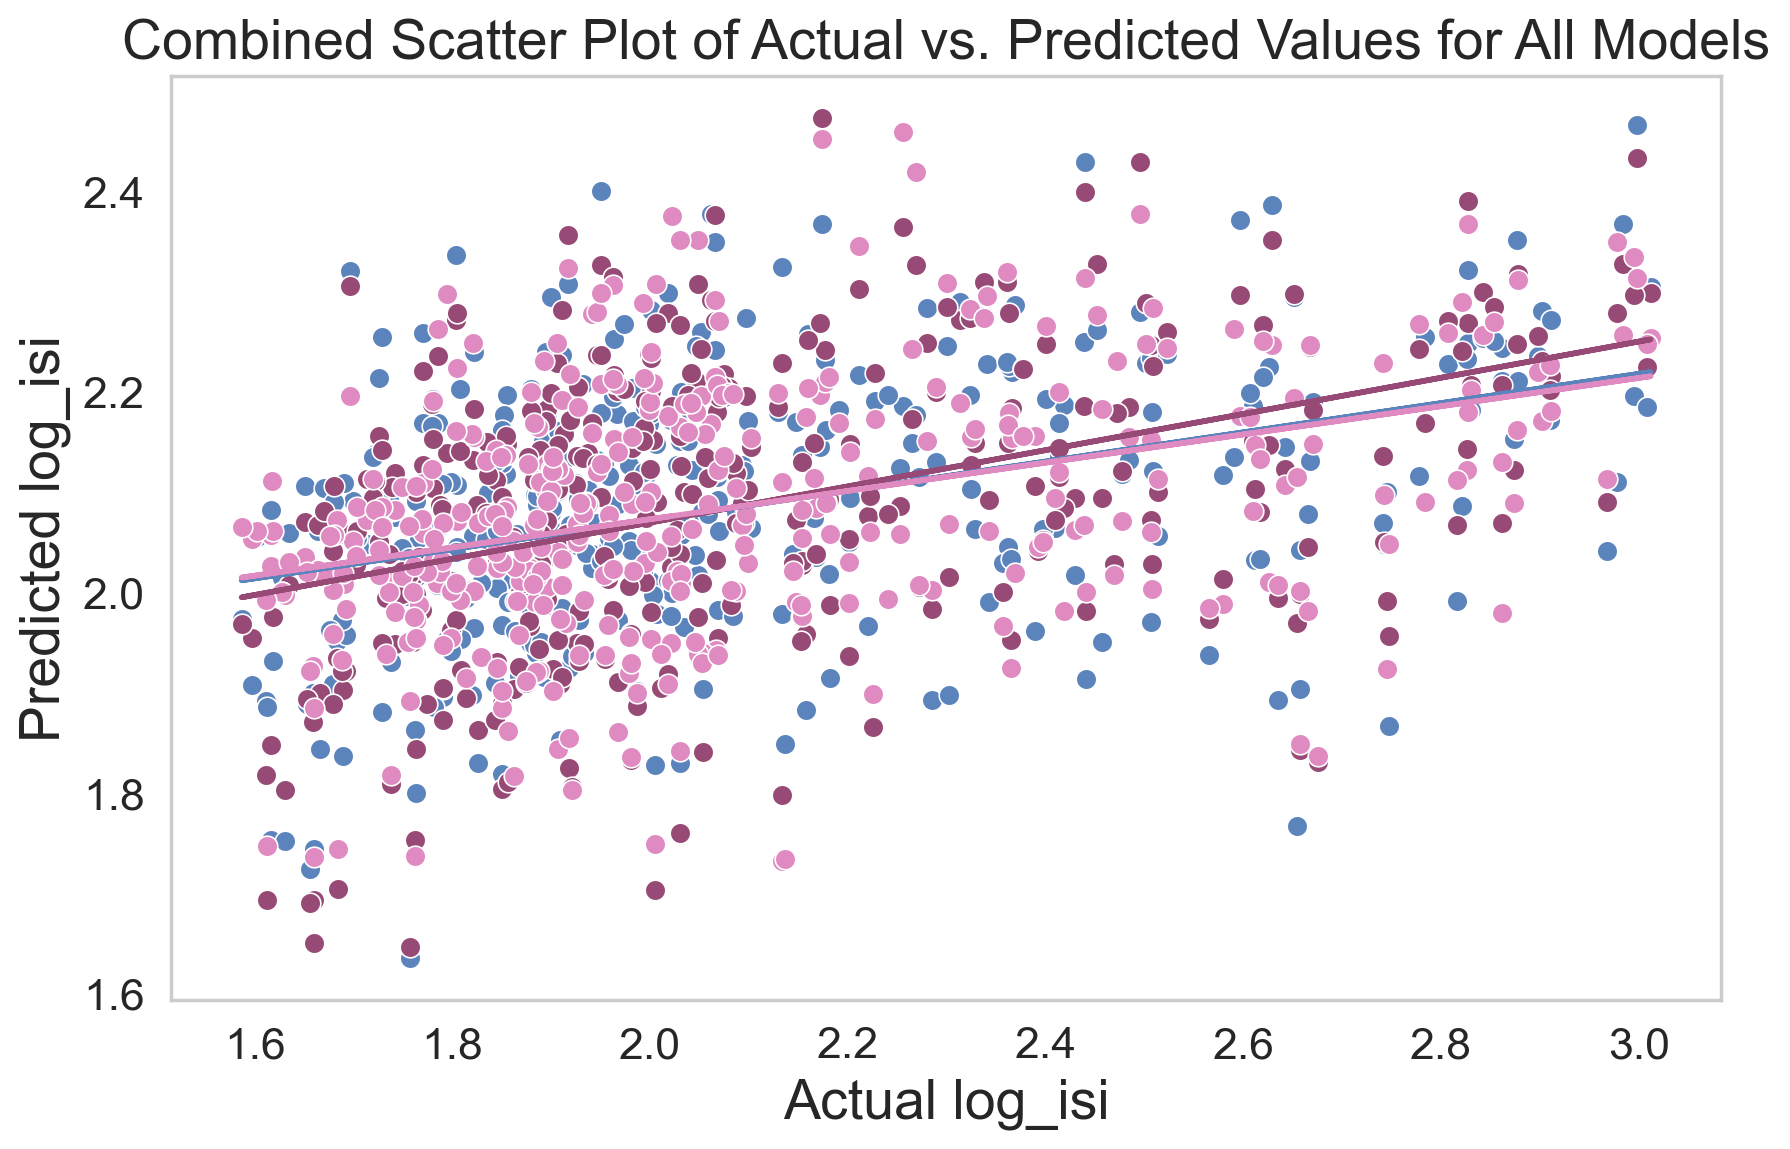

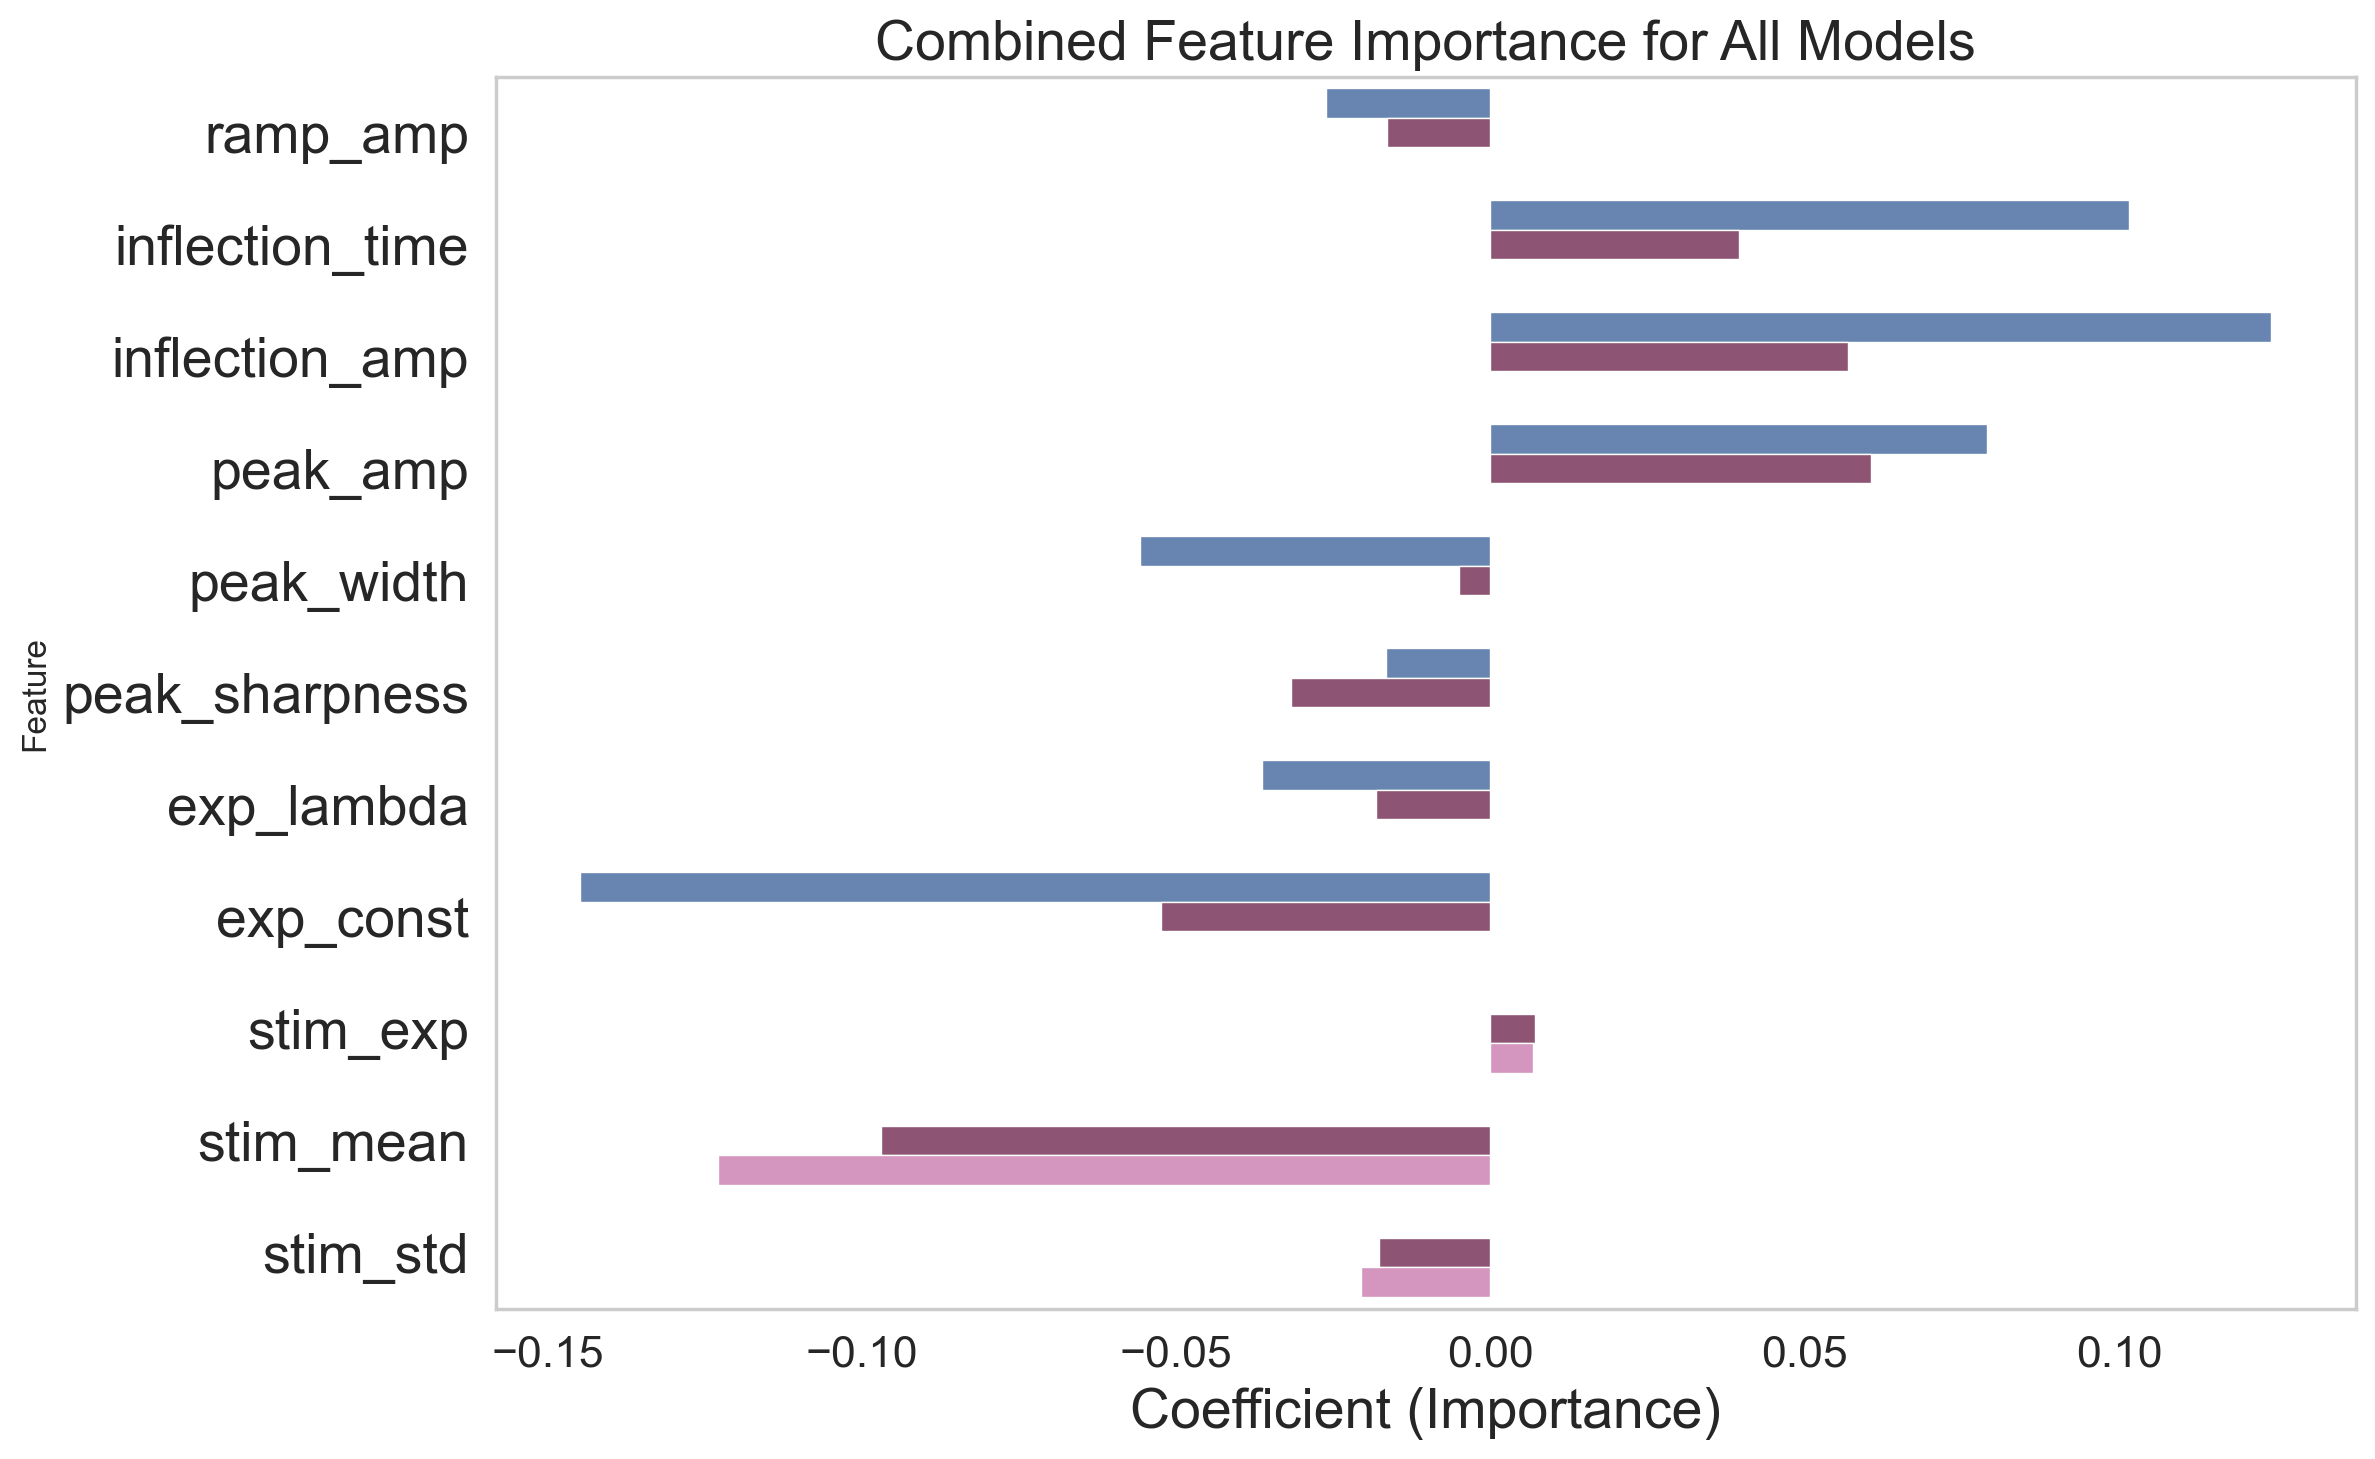

In [57]:
#Plot comparisons
plot_r2_comparison(ridge_results_spike_only, ridge_results_spike_stim, ridge_results_stim_only)
plot_combined_actual_vs_predicted(y_log_isi, ridge_results_spike_only['y_pred_cv'], ridge_results_spike_stim['y_pred_cv'], ridge_results_stim_only['y_pred_cv'])
plot_combined_feature_importance(feature_importance_spike_only_df, feature_importance_spike_stim_df, feature_importance_stim_only_df)


### 8e. F-Test — Does Adding Stimulus Features Significantly Improve ISI Prediction?

Formal test of whether the combined model (waveform + stimulus) explains significantly more variance in log ISI than the waveform-only model. A non-significant result would suggest waveform features are already sufficient — waveform shape captures the stimulus information that matters for firing dynamics.

In [58]:
adjs_rsq_spk = ridge_results_spike_only["r2_mean"]
adjs_rsq_stim =ridge_results_stim_only["r2_mean"]
adjs_rsq_spk_stim =ridge_results_spike_stim["r2_mean"]

In [59]:
import scipy.stats as stats

# Number of features
p_spk = 8
p_stim = 3
p_spk_stim = 11

# Sample size
n = 391

def f_test_r2(adj_r2_small, adj_r2_big, p_small, p_big, n):
    num = (adj_r2_big - adj_r2_small) / (p_big - p_small)
    denom = (1 - adj_r2_big) / (n - p_big - 1)
    F = num / denom
    df1 = p_big - p_small
    df2 = n - p_big - 1
    p = 1 - stats.f.cdf(F, df1, df2)
    return F, p

# Compare all pairs
f_spk_vs_stim = f_test_r2(adjs_rsq_stim, adjs_rsq_spk, p_stim, p_spk, n)
f_spk_vs_combined = f_test_r2(adjs_rsq_spk, adjs_rsq_spk_stim, p_spk, p_spk_stim, n)
f_stim_vs_combined = f_test_r2(adjs_rsq_stim,adjs_rsq_spk_stim, p_stim, p_spk_stim, n)

print("Spike vs. Stim:", f_spk_vs_stim)
print("Spike vs. Combined:", f_spk_vs_combined)
print("Stim vs. Combined:", f_stim_vs_combined)

Spike vs. Stim: (np.float64(2.73135794644904), np.float64(0.01934456043912136))
Spike vs. Combined: (np.float64(6.672725928909133), np.float64(0.0002120887737212529))
Stim vs. Combined: (np.float64(4.285422535309828), np.float64(5.963346327164665e-05))


#### When does the effect start? — stimulus onset analysis

The main analysis uses a fixed 5ms window before the inflection point for `stim_mean`. Here we slide that window from 0 to 100ms before the inflection and track how Pearson r between pre-spike stimulus amplitude and each waveform feature changes with lag. The peak correlation marks the optimal window; the point where correlation drops to near zero is where the effect stops.

In [ ]:
# df must retain sweep/spike_num for lag analysis — use df before the drop
df_pink_raw = df.loc[df['stim_type'] == 'pink']
valid_idx_raw = [i for i in last_spikes_indices if i in df_pink_raw.index]
df_pink_raw_filtered = df_pink_raw.drop(valid_idx_raw)

lag_centers, r_vals, p_vals, feat_names = compute_stim_lag_correlations(
    f, fs, df_pink_raw_filtered, one_ms,
    window_ms=5, max_lag_ms=1000,
)
plot_stim_lag_correlations(lag_centers, r_vals, p_vals, feat_names, title='Cell 1')

### 9b. Window Expansion

Compare ridge regression R² (bootstrap mean + 95% CI) across pre-inflection window sizes. Window choice mirrors the spe-1 pre-spike window (PRE_WIN = −55 → −5 ms, i.e. 50 ms).

In [ ]:
# Ensure df_pink_raw_filtered exists (defined in 9a lag cell; fallback if skipped)
if 'df_pink_raw_filtered' not in vars():
    df_pink_raw = df.loc[df['stim_type'] == 'pink']
    valid_idx_raw = [i for i in last_spikes_indices if i in df_pink_raw.index]
    df_pink_raw_filtered = df_pink_raw.drop(valid_idx_raw)

WINDOWS_MS = [5, 25, 50]
pickle_path = os.path.join(PICKLE_DIR, 'results_window.pkl')

if not FORCE_RERUN and os.path.exists(pickle_path):
    with open(pickle_path, 'rb') as file:
        results_window = pickle.load(file)
    print('Loaded results_window from pickle.')
else:
    results_window = {}
    for wms in WINDOWS_MS:
        if wms == 5:
            df_w = df_pink_filtered.copy()
        else:
            stim_extra = recompute_stim_features(f, fs, df_pink_raw_filtered, one_ms, window_ms=wms)
            df_w = df_pink_filtered.copy()
            df_w['stim_mean'] = stim_extra[f'stim_mean_{wms}ms']
            df_w['stim_std']  = stim_extra[f'stim_std_{wms}ms']
            df_w['stim_exp']  = stim_extra[f'stim_exp_{wms}ms']
            df_w = df_w.dropna(subset=['stim_mean'])

        for target in ['stim_mean', 'stim_std', 'stim_exp']:
            data_t = df_w.dropna(subset=[target])
            X_t = data_t.drop(columns=['stim_exp', 'stim_mean', 'stim_std', 'log_isi'])
            y_t = data_t[target]
            print(f'\n--- {wms} ms window  |  target: {target} ---')
            results_window[f'{wms}ms_{target}'] = run_ridge_regression_kfold(X_t, y_t)

    apply_fdr_pvc6(results_window)
    with open(pickle_path, 'wb') as file:
        pickle.dump(results_window, file)
    print('Saved results_window to pickle.')

plot_window_expansion(
    results_window, WINDOWS_MS,
    targets=('stim_mean', 'stim_std', 'stim_exp'),
    target_labels=('stim mean', 'stim std', 'stim exp'),
)

### 9c. 25ms Window — Beta Weights & Feature Importance

Detailed ridge regression results using a 25ms pre-inflection stimulus window. Shown for each stimulus target: actual vs. predicted scatter, standardised beta weights with 95% bootstrap CI, and bootstrapped R² distribution.

In [ ]:
# 25ms window — detailed beta weights per target
stim_extra_25 = recompute_stim_features(f, fs, df_pink_raw_filtered, one_ms, window_ms=25)
df_w25 = df_pink_filtered.copy()
df_w25['stim_mean'] = stim_extra_25['stim_mean_25ms']
df_w25['stim_std']  = stim_extra_25['stim_std_25ms']
df_w25['stim_exp']  = stim_extra_25['stim_exp_25ms']

for target in ['stim_mean', 'stim_std', 'stim_exp']:
    key = f'25ms_{target}'
    data_t = df_w25.dropna(subset=[target])
    y_t = data_t[target]
    print(f'\n--- 25ms window | {target} ---')
    plot_ridge_results(y_t, results_window[key], title=f'25ms Window — {target}')

### 9d. 50ms Window — Beta Weights & Feature Importance

Detailed ridge regression results using a 50ms pre-inflection stimulus window (matching the spe-1 PRE_WIN). Shown for each stimulus target: actual vs. predicted scatter, standardised beta weights with 95% bootstrap CI, and bootstrapped R² distribution.

In [ ]:
# 50ms window — detailed beta weights per target
stim_extra_50 = recompute_stim_features(f, fs, df_pink_raw_filtered, one_ms, window_ms=50)
df_w50 = df_pink_filtered.copy()
df_w50['stim_mean'] = stim_extra_50['stim_mean_50ms']
df_w50['stim_std']  = stim_extra_50['stim_std_50ms']
df_w50['stim_exp']  = stim_extra_50['stim_exp_50ms']

for target in ['stim_mean', 'stim_std', 'stim_exp']:
    key = f'50ms_{target}'
    data_t = df_w50.dropna(subset=[target])
    y_t = data_t[target]
    print(f'\n--- 50ms window | {target} ---')
    plot_ridge_results(y_t, results_window[key], title=f'50ms Window — {target}')